<a href="https://colab.research.google.com/github/suphitchakh-web/Project_1/blob/main/Team06_Part2%20%26%20Part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## สมาชิกกลุ่มที่ 6
1. 673020252-4 นางสาวณิรดา อนุนิวัฒน์

2. 673020258-2 นางสาวปวริศา โง่นสูงเนิน

3. 673020265-5 นางสาวสุพิชชา คำสิงห์

4. 673020262-1 นายวรวัฒน์ พรหมคุณ

5. 673020247-7 นายชวนากร เพชรเจริญรัตน์

# Part 2: Amazon Reviews Analysis — Musical Instruments

## การนำเข้าข้อมูล

In [5]:
import json, os, re, random, itertools, time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
import os

BASE_PATH = "/content/drive/MyDrive/part_2"

REVIEW_PATH = os.path.join(
    BASE_PATH,
    "Musical_Instruments.csv.gz"
)

META_PATH = os.path.join(
    BASE_PATH,
    "meta_Musical_Instruments.jsonl.gz"
)

print("Review file exists:", os.path.exists(REVIEW_PATH))
print("Metadata file exists:", os.path.exists(META_PATH))

Review file exists: True
Metadata file exists: True


## 1. Setup และการกำหนดค่าการวิเคราะห์

ในขั้นตอนนี้จะเตรียม Python libraries ที่จำเป็น กำหนดค่า RANDOM_SEED และ SAMPLE_N เพื่อให้การสุ่มข้อมูลสามารถทำซ้ำได้ รวมถึงกำหนดตำแหน่งของไฟล์ Review และ Product Metadata ที่ใช้ในการวิเคราะห์

ข้อมูลที่ใช้ประกอบด้วย
- Musical Instruments Review Data
- Musical Instruments Product Metadata

In [7]:
import os
import pandas as pd
import numpy as np
from google.colab import drive

RANDOM_SEED = 42
SAMPLE_N = 50000
np.random.seed(RANDOM_SEED)

# เชื่อม Google Drive
drive.mount("/content/drive")

# ตำแหน่งโฟลเดอร์ Part 2
BASE_PATH = "/content/drive/MyDrive/part_2"

# ตำแหน่งไฟล์ข้อมูล
REVIEW_PATH = os.path.join(
    BASE_PATH,
    "Musical_Instruments.csv.gz"
)

META_PATH = os.path.join(
    BASE_PATH,
    "meta_Musical_Instruments.jsonl.gz"
)

# ตรวจสอบไฟล์
print("RANDOM_SEED =", RANDOM_SEED)
print("SAMPLE_N =", SAMPLE_N)
print("Review file exists:", os.path.exists(REVIEW_PATH))
print("Metadata file exists:", os.path.exists(META_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RANDOM_SEED = 42
SAMPLE_N = 50000
Review file exists: True
Metadata file exists: True


## 2. ตรวจสอบโครงสร้างของข้อมูล

### 2.1 Review Data

In [8]:
review_preview = pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    nrows=5
)

print("จำนวนแถวที่อ่านเพื่อดูตัวอย่าง:", len(review_preview))

print("\nColumns:")
print(review_preview.columns.tolist())

print("\nData types:")
print(review_preview.dtypes)

print("\nตัวอย่าง Review Data:")
display(review_preview)

จำนวนแถวที่อ่านเพื่อดูตัวอย่าง: 5

Columns:
['user_id', 'parent_asin', 'rating', 'timestamp']

Data types:
user_id         object
parent_asin     object
rating         float64
timestamp        int64
dtype: object

ตัวอย่าง Review Data:


,user_id,parent_asin,rating,timestamp
0,AGKASBHYZPGTEPO6LWZPVJWB2BVA,B003LPTAYI,5.0,1452650586000
1,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B0040FJ27S,4.0,1384912482000
2,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B06XP6TDVY,3.0,1558567365290
3,AEM663T6XHZFWLODF4US2RCOCUSA,B00WJ3HL5I,3.0,1607055693671
4,AFJTRBXMURLHS5EGNXLUHDHIZRFQ,B07T9NM5QR,5.0,1622595785255


### 2.2 Product Metadata

In [9]:
meta_preview = pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    nrows=5
)

print("จำนวนแถวที่อ่านเพื่อดูตัวอย่าง:", len(meta_preview))

print("\nColumns:")
print(meta_preview.columns.tolist())

print("\nData types:")
print(meta_preview.dtypes)

print("\nตัวอย่าง Product Metadata:")
display(meta_preview)

จำนวนแถวที่อ่านเพื่อดูตัวอย่าง: 5

Columns:
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']

Data types:
main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
description         object
price              float64
images              object
videos              object
store               object
categories          object
details             object
parent_asin         object
bought_together    float64
dtype: object

ตัวอย่าง Product Metadata:


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Musical Instruments,Pearl Export Lacquer EXL725S/C249 5-Piece New ...,4.2,22,[Item may ship in more than one box and may ar...,[Introducing the best selling drum set of all ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Best Selling Drum Set of All Time'...,Pearl,"[Musical Instruments, Drums & Percussion, Drum...","{'Item Weight': '33 pounds', 'Product Dimensio...",B01M4HO6RK,NaN
1,Musical Instruments,Behringer EUROPOWER EPQ900 Professional 900 Wa...,4.0,13,[2 x 390 Watts into 4 Ohms; 2 x 245 Watts into...,"[BEHRINGER EUROPOWER EPQ900, Professional 900-...",NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Behringer,"[Musical Instruments, Live Sound & Stage, Powe...","{'Item Weight': '10.8 pounds', 'Product Dimens...",B00508JFE4,NaN
2,Musical Instruments,Washburn Classical Series Acoustic Electric Cu...,3.6,15,[The Washburn is truly a professional instrume...,[C64SCE CLASSICAL GUITAR The cutaway allows ac...,399.0,[{'thumb': 'https://m.media-amazon.com/images/...,[],Washburn,"[Musical Instruments, Guitars]","{'Item Weight': '5.98 pounds', 'Product Dimens...",B000S5JGMU,NaN
3,Musical Instruments,"VocoPro, plug in, Black, 21.00 x 21.00 x 23.00...",3.5,7,"[Includes one microphone and one receiver, Can...",[VocoPro UHF-18 DIAMOND - N Wireless Microphon...,112.0,[{'thumb': 'https://m.media-amazon.com/images/...,[],VocoPro,"[Musical Instruments, Live Sound & Stage, PA S...","{'Item Weight': '2.29 pounds', 'Product Dimens...",B00B2HLWZW,NaN
4,Musical Instruments,Shure SM7B Vocal Dynamic Microphone for Broadc...,4.9,9512,[ONE MICROPHONE FOR EVERYTHING - Studio Record...,"[The SM7B dynamic microphone has a smooth, fla...",399.0,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Shure SM7B Mic Demonstration', 'ur...",Shure,"[Musical Instruments, Microphones & Accessorie...","{'Item Weight': '2.7 pounds', 'Product Dimensi...",B0B89ZSYS7,NaN


## 3. ตรวจสอบคุณภาพของข้อมูล



### 3.1 ตรวจสอบคุณภาพของ Review Data

ในขั้นตอนนี้จะตรวจสอบคุณภาพของ Review Data ทั้งชุดก่อนนำไปใช้ในการวิเคราะห์ โดยตรวจสอบจำนวนข้อมูลทั้งหมด Missing Values, Duplicate Records, การกระจายของ Rating และช่วงของ Timestamp เนื่องจาก Review Data มีจำนวนหลายล้าน records จึงใช้วิธีอ่านข้อมูลเป็นส่วน ๆ (chunks) เพื่อช่วยลดการใช้หน่วยความจำของ Google Colab และยังสามารถตรวจสอบข้อมูลได้ครบทั้ง Dataset

In [10]:
# กำหนดตัวแปรสำหรับเก็บผลการตรวจสอบ
total_rows = 0

missing_counts = {
    "user_id": 0,
    "parent_asin": 0,
    "rating": 0,
    "timestamp": 0
}

rating_counts = {}

duplicate_count = 0

min_timestamp = None
max_timestamp = None

chunk_size = 100000

# อ่าน Review Data เป็น chunks
for chunk in pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    chunksize=chunk_size
):
    total_rows += len(chunk)

    # Missing Values
    for col in missing_counts:
        missing_counts[col] += chunk[col].isna().sum()

    # Rating distribution
    counts = chunk["rating"].value_counts()

    for rating, count in counts.items():
        rating_counts[rating] = rating_counts.get(rating, 0) + count

    # Duplicate ภายในแต่ละ chunk
    duplicate_count += chunk.duplicated().sum()

    # Timestamp range
    chunk_min = chunk["timestamp"].min()
    chunk_max = chunk["timestamp"].max()

    if min_timestamp is None or chunk_min < min_timestamp:
        min_timestamp = chunk_min

    if max_timestamp is None or chunk_max > max_timestamp:
        max_timestamp = chunk_max


# แสดงผล
print("===== Review Data Quality Report =====")

print("\nTotal Reviews:")
print(total_rows)

print("\nMissing Values:")
for col, count in missing_counts.items():
    print(f"{col}: {count}")

print("\nDuplicate Records within chunks:")
print(duplicate_count)

print("\nRating Distribution:")
for rating in sorted(rating_counts):
    print(f"{rating}: {rating_counts[rating]}")

print("\nTimestamp Range:")
print(min_timestamp, "to", max_timestamp)

===== Review Data Quality Report =====

Total Reviews:
2975551

Missing Values:
user_id: 0
parent_asin: 0
rating: 0
timestamp: 0

Duplicate Records within chunks:
0

Rating Distribution:
1.0: 260520
2.0: 129732
3.0: 194567
4.0: 394945
5.0: 1995787

Timestamp Range:
935635892000 to 1694546704987


### สรุปผลการตรวจสอบคุณภาพของ Review Data

จากการตรวจสอบ Review Data ทั้งชุด พบว่ามีข้อมูลทั้งหมด 2,975,551 reviews และไม่พบ Missing Values ในคอลัมน์ `user_id`, `parent_asin`, `rating` และ `timestamp`

การกระจายของ Rating พบว่า Rating 5 มีจำนวนมากที่สุด 1,995,787 reviews รองลงมาคือ Rating 4 จำนวน 394,945 reviews, Rating 1 จำนวน 260,520 reviews, Rating 3 จำนวน 194,567 reviews และ Rating 2 จำนวน 129,732 reviews

สำหรับ Duplicate Records จากการตรวจสอบแบบแบ่งข้อมูลเป็น chunks ไม่พบ duplicate ภายในแต่ละ chunk อย่างไรก็ตาม ผลการตรวจสอบนี้ยังไม่สามารถยืนยันได้ว่าไม่มี duplicate ระหว่างคนละ chunks

Timestamp ของข้อมูลอยู่ในช่วง 935635892000 ถึง 1694546704987 ซึ่งจะนำไปแปลงเป็นรูปแบบวันที่และเวลาในขั้นตอนถัดไป เพื่อเตรียมสำหรับการวิเคราะห์ตามช่วงเวลา

โดยรวม Review Data มีจำนวน records มาก และไม่พบ Missing Values ใน 4 คอลัมน์หลักที่ตรวจสอบ จึงสามารถนำไปตรวจสอบคุณภาพของ Product Metadata และเตรียมข้อมูลสำหรับขั้นตอนถัดไปได้

### 3.2 ตรวจสอบคุณภาพของ Product Metadata

ในขั้นตอนนี้จะตรวจสอบคุณภาพของ Product Metadata ทั้งชุด โดยพิจารณาจำนวนสินค้า Missing Values, Duplicate Records และความครบถ้วนของ `parent_asin` ซึ่งเป็น key สำคัญสำหรับการเชื่อม Product Metadata กับ Review Data ในขั้นตอนถัดไป

เนื่องจาก Product Metadata มีหลายคอลัมน์และบางคอลัมน์เป็นข้อมูลแบบข้อความหรือโครงสร้างที่ซับซ้อน จึงจะตรวจสอบ Missing Values แยกตามคอลัมน์ และตรวจสอบ `parent_asin` เพื่อประเมินความพร้อมสำหรับการ Join กับ Review Data

In [11]:
# ตัวแปรสำหรับเก็บผลการตรวจสอบ
total_meta_rows = 0

meta_missing_counts = {}
parent_asin_missing = 0
parent_asin_counts = {}

chunk_size = 10000

# อ่าน Product Metadata แบบ chunks
for chunk in pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    chunksize=chunk_size
):
    total_meta_rows += len(chunk)

    # สร้างตัวนับ Missing สำหรับทุก column
    if not meta_missing_counts:
        meta_missing_counts = {
            col: 0 for col in chunk.columns
        }

    # นับ Missing Values
    for col in chunk.columns:
        meta_missing_counts[col] += chunk[col].isna().sum()

    # ตรวจ Missing ของ parent_asin
    parent_asin_missing += chunk["parent_asin"].isna().sum()

    # นับจำนวนครั้งที่แต่ละ parent_asin ปรากฏ
    counts = chunk["parent_asin"].dropna().value_counts()

    for asin, count in counts.items():
        parent_asin_counts[asin] = (
            parent_asin_counts.get(asin, 0) + count
        )


# คำนวณจำนวน parent_asin ที่ไม่ซ้ำ
unique_parent_asin = len(parent_asin_counts)

# คำนวณจำนวน parent_asin ที่ซ้ำ
duplicate_parent_asin = sum(
    count - 1
    for count in parent_asin_counts.values()
    if count > 1
)


print("===== Product Metadata Quality Report =====")

print("\nTotal Products:")
print(total_meta_rows)

print("\nMissing Values:")
for col, count in meta_missing_counts.items():
    print(f"{col}: {count}")

print("\nMissing parent_asin:")
print(parent_asin_missing)

print("\nUnique parent_asin:")
print(unique_parent_asin)

print("\nDuplicate parent_asin Records:")
print(duplicate_parent_asin)

===== Product Metadata Quality Report =====

Total Products:
213593

Missing Values:
main_category: 3392
title: 0
average_rating: 0
rating_number: 0
features: 0
description: 0
price: 128677
images: 0
videos: 0
store: 3556
categories: 0
details: 0
parent_asin: 0
bought_together: 213593
subtitle: 213255
author: 213472

Missing parent_asin:
0

Unique parent_asin:
213593

Duplicate parent_asin Records:
0


### สรุปผลการตรวจสอบคุณภาพของ Product Metadata

จากการตรวจสอบ Product Metadata ทั้งชุด พบว่ามีข้อมูลสินค้า 213,593 records โดยไม่พบ Missing Values ใน `parent_asin` และพบว่า `parent_asin` ทั้ง 213,593 ค่าเป็นค่าที่ไม่ซ้ำกัน จึงมีความพร้อมในการใช้เป็น key สำหรับเชื่อมข้อมูลกับ Review Data

สำหรับ Missing Values พบว่า `price` มี Missing Values จำนวน 128,677 records, `main_category` มี 3,392 records และ `store` มี 3,556 records ขณะที่ `title`, `average_rating`, `rating_number`, `features`, `description`, `images`, `videos`, `categories` และ `details` ไม่พบ Missing Values

นอกจากนี้ `bought_together` ไม่มีข้อมูลในทุก record จากผลการตรวจสอบครั้งนี้ จึงควรพิจารณาว่า column ดังกล่าวไม่จำเป็นต่อการวิเคราะห์ในขั้นตอนถัดไป

โดยรวม Product Metadata มี `parent_asin` ครบถ้วนและไม่พบค่าซ้ำ ทำให้สามารถนำ `parent_asin` ไปใช้เป็น key สำหรับ Join กับ Review Data ได้ อย่างไรก็ตาม Missing Values ใน `price`, `main_category` และ `store` จะต้องนำมาพิจารณาในขั้นตอน Data Cleaning และการวิเคราะห์ต่อไป

### 3.3 ตรวจสอบความสอดคล้องของ `parent_asin` ระหว่าง Review Data และ Product Metadata

`parent_asin` เป็น key ที่ใช้เชื่อม Review Data กับ Product Metadata ดังนั้นก่อนทำการ Join จะตรวจสอบว่า `parent_asin` ที่ปรากฏใน Review Data มีอยู่ใน Product Metadata มากน้อยเพียงใด

การตรวจสอบนี้จะช่วยประเมินความพร้อมของข้อมูลสำหรับการ Join และระบุจำนวน Review ที่อาจไม่สามารถจับคู่กับข้อมูลสินค้าได้ โดยจะใช้ข้อมูล `parent_asin` จาก Product Metadata เป็นชุดอ้างอิง

In [12]:
# สร้าง set ของ parent_asin จาก Product Metadata
meta_parent_asins = set()

for chunk in pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    chunksize=10000
):
    meta_parent_asins.update(
        chunk["parent_asin"].dropna().unique()
    )

print("จำนวน unique parent_asin ใน Metadata:")
print(len(meta_parent_asins))


# ตรวจ parent_asin จาก Review Data
total_reviews = 0
matched_reviews = 0
unmatched_reviews = 0

review_parent_asins = set()

for chunk in pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    usecols=["parent_asin"],
    chunksize=100000
):
    total_reviews += len(chunk)

    review_asins = set(
        chunk["parent_asin"].dropna().unique()
    )

    review_parent_asins.update(review_asins)

    matched_reviews += chunk["parent_asin"].isin(
        meta_parent_asins
    ).sum()

    unmatched_reviews += (
        ~chunk["parent_asin"].isin(meta_parent_asins)
    ).sum()


# คำนวณเปอร์เซ็นต์
match_rate = matched_reviews / total_reviews * 100
unmatch_rate = unmatched_reviews / total_reviews * 100

print("\n===== Parent ASIN Matching Report =====")
print("Total Reviews:", total_reviews)
print("Matched Reviews:", matched_reviews)
print("Unmatched Reviews:", unmatched_reviews)
print("Match Rate: {:.2f}%".format(match_rate))
print("Unmatch Rate: {:.2f}%".format(unmatch_rate))

print("\nUnique parent_asin in Review Data:")
print(len(review_parent_asins))

จำนวน unique parent_asin ใน Metadata:
213593

===== Parent ASIN Matching Report =====
Total Reviews: 2975551
Matched Reviews: 2975551
Unmatched Reviews: 0
Match Rate: 100.00%
Unmatch Rate: 0.00%

Unique parent_asin in Review Data:
213571


### สรุปผลการตรวจสอบความสอดคล้องของ `parent_asin`

จากการตรวจสอบพบว่า Product Metadata มี unique `parent_asin` จำนวน 213,593 ค่า ขณะที่ Review Data มี unique `parent_asin` จำนวน 213,571 ค่า

เมื่อเปรียบเทียบ `parent_asin` ระหว่างทั้งสอง Dataset พบว่า Review Data จำนวน 2,975,551 records สามารถจับคู่กับ Product Metadata ได้ทั้งหมด โดยมี Matched Reviews จำนวน 2,975,551 records และไม่มี Unmatched Reviews

ดังนั้น Review Data มี Match Rate เท่ากับ 100.00% แสดงว่า `parent_asin` ของ Review ทุก record ที่ตรวจสอบสามารถเชื่อมโยงไปยัง Product Metadata ได้

แม้จำนวน unique `parent_asin` ของ Review Data จะน้อยกว่า Metadata อยู่ 22 ค่า แต่ไม่ส่งผลต่อการจับคู่ Review กับ Metadata เนื่องจาก Review ทุก record มี `parent_asin` ที่พบใน Metadata

ผลการตรวจสอบนี้แสดงให้เห็นว่า `parent_asin` มีความพร้อมสำหรับใช้เป็น key ในขั้นตอน Join ระหว่าง Review Data และ Product Metadata

## 4. Data Cleaning

ในขั้นตอนนี้จะเตรียมข้อมูล Review Data และ Product Metadata ให้พร้อมสำหรับการ Sampling และการ Join โดยจะหลีกเลี่ยงการลบข้อมูลที่ไม่จำเป็น

จากการตรวจสอบก่อนหน้า Review Data ไม่มี Missing Values ในคอลัมน์หลัก ได้แก่ `user_id`, `parent_asin`, `rating` และ `timestamp` ดังนั้นจะไม่ลบ records เนื่องจาก Missing Values

สำหรับ Product Metadata จะเก็บ records ที่มี `parent_asin` ครบถ้วนไว้ทั้งหมด เนื่องจาก `parent_asin` เป็น key ที่ใช้เชื่อมข้อมูลระหว่าง Review Data และ Product Metadata

### 4.1 ตรวจสอบและเตรียม Review Data

Review Data มีข้อมูลจำนวนมาก จึงยังไม่โหลดข้อมูลทั้งหมดเข้าสู่หน่วยความจำในขั้นตอนนี้ แต่จะตรวจสอบชนิดข้อมูลและเงื่อนไขที่จำเป็นต่อการวิเคราะห์ ได้แก่ `rating`, `timestamp` และ `parent_asin`

ข้อมูลที่ผ่านเงื่อนไขจะถือเป็น Valid Review สำหรับขั้นตอน Sampling ต่อไป

In [13]:
# ตรวจสอบ Review Data และนับจำนวน records ที่ผ่านเงื่อนไข
total_reviews = 0
valid_reviews = 0

invalid_rating = 0
invalid_timestamp = 0
invalid_parent_asin = 0

chunk_size = 100000

for chunk in pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    chunksize=chunk_size
):
    total_reviews += len(chunk)

    # ตรวจเงื่อนไข Rating ต้องอยู่ระหว่าง 1 ถึง 5
    rating_valid = chunk["rating"].between(1, 5)

    # ตรวจ Timestamp ต้องไม่เป็น Missing
    timestamp_valid = chunk["timestamp"].notna()

    # ตรวจ parent_asin ต้องไม่เป็น Missing
    parent_asin_valid = chunk["parent_asin"].notna()

    # นับข้อมูลที่ไม่ผ่านแต่ละเงื่อนไข
    invalid_rating += (~rating_valid).sum()
    invalid_timestamp += (~timestamp_valid).sum()
    invalid_parent_asin += (~parent_asin_valid).sum()

    # Valid Review ต้องผ่านทุกเงื่อนไข
    valid_mask = (
        rating_valid
        & timestamp_valid
        & parent_asin_valid
    )

    valid_reviews += valid_mask.sum()


print("===== Review Data Cleaning Check =====")
print("Total Reviews:", total_reviews)
print("Valid Reviews:", valid_reviews)
print("Invalid Rating:", invalid_rating)
print("Invalid Timestamp:", invalid_timestamp)
print("Invalid parent_asin:", invalid_parent_asin)

===== Review Data Cleaning Check =====
Total Reviews: 2975551
Valid Reviews: 2975551
Invalid Rating: 0
Invalid Timestamp: 0
Invalid parent_asin: 0


### สรุปผลการตรวจสอบและเตรียม Review Data

จากการตรวจสอบ Review Data ทั้งหมด 2,975,551 records พบว่าทุก record ผ่านเงื่อนไขที่กำหนดสำหรับการวิเคราะห์ โดย `rating` อยู่ในช่วง 1–5, `timestamp` ไม่เป็น Missing และ `parent_asin` ไม่เป็น Missing

ไม่พบ Invalid Rating, Invalid Timestamp หรือ Invalid `parent_asin` ดังนั้น Review Data ทั้ง 2,975,551 records หรือ 100% ของข้อมูล สามารถนำไปใช้ในขั้นตอน Sampling และการ Join กับ Product Metadata ได้โดยไม่จำเป็นต้องลบ records จากเงื่อนไขเหล่านี้

### 4.2 ตรวจสอบและเตรียม Product Metadata

Product Metadata มี `parent_asin` ครบถ้วนและไม่พบ `parent_asin` ซ้ำจากการตรวจสอบก่อนหน้า ดังนั้นจะเก็บข้อมูลสินค้าที่มี `parent_asin` ครบถ้วนไว้สำหรับการ Join กับ Review Data

ในขั้นตอนนี้จะตรวจสอบความพร้อมของข้อมูลสำหรับการวิเคราะห์ โดยเฉพาะ `parent_asin`, `title`, `features` และ `description` ซึ่งเป็นข้อมูลที่สามารถนำมาใช้ประกอบการวิเคราะห์สินค้าและสร้าง Text Features ในขั้นตอนถัดไป

In [14]:
# ตรวจสอบและเตรียม Product Metadata
meta_valid_rows = 0
meta_invalid_parent_asin = 0

text_columns = ["title", "features", "description"]

text_missing_counts = {
    col: 0 for col in text_columns
}

chunk_size = 10000

for chunk in pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    chunksize=chunk_size
):
    # ตรวจ parent_asin
    parent_asin_valid = chunk["parent_asin"].notna()

    meta_valid_rows += parent_asin_valid.sum()
    meta_invalid_parent_asin += (~parent_asin_valid).sum()

    # ตรวจ Missing Values ของ text columns
    for col in text_columns:
        text_missing_counts[col] += chunk[col].isna().sum()


print("===== Product Metadata Cleaning Check =====")
print("Total Metadata Records:", total_meta_rows)
print("Valid Metadata Records:", meta_valid_rows)
print("Invalid parent_asin:", meta_invalid_parent_asin)

print("\nMissing Values in Text Columns:")
for col, count in text_missing_counts.items():
    print(f"{col}: {count}")

===== Product Metadata Cleaning Check =====
Total Metadata Records: 213593
Valid Metadata Records: 213593
Invalid parent_asin: 0

Missing Values in Text Columns:
title: 0
features: 0
description: 0


### สรุปผลการตรวจสอบและเตรียม Product Metadata

จากการตรวจสอบ Product Metadata ทั้งหมด 213,593 records พบว่า `parent_asin` ครบถ้วนทุก record และไม่มี Invalid `parent_asin`

สำหรับข้อมูลข้อความที่สำคัญต่อการวิเคราะห์ ได้แก่ `title`, `features` และ `description` ไม่พบ Missing Values ในทั้ง 3 columns

ดังนั้น Product Metadata ทั้ง 213,593 records สามารถนำไปใช้สำหรับการ Join กับ Review Data ได้ และข้อมูลข้อความใน `title`, `features` และ `description` มีความพร้อมสำหรับนำไปสร้าง Text Features ในขั้นตอนการวิเคราะห์ต่อไป

### 4.3 Sampling และ Join Review Data กับ Product Metadata

Review Data มีจำนวน 2,975,551 records ซึ่งมีขนาดใหญ่ จึงจะสุ่มตัวอย่างจำนวน `SAMPLE_N = 50,000` records สำหรับการวิเคราะห์เชิงลึก โดยใช้ `RANDOM_SEED` ที่กำหนดไว้ในขั้นตอน Setup เพื่อให้สามารถทำซ้ำผลการสุ่มได้

หลังจาก Sampling จะนำ Review Data ที่ได้มา Join กับ Product Metadata โดยใช้ `parent_asin` เป็น key เพื่อเพิ่มข้อมูลเกี่ยวกับสินค้า เช่น `title`, `features`, `description`, `average_rating` และ `price`

หลังการ Join จะตรวจสอบจำนวน records ก่อนและหลัง Join รวมถึง Join Success Rate เพื่อยืนยันว่าข้อมูลตัวอย่างยังคงสามารถเชื่อมโยงกับ Product Metadata ได้ครบถ้วน

In [15]:
# ============================================================
# 1. Random Sampling จาก Review Data
# ============================================================

review_sample = pd.read_csv(
    REVIEW_PATH,
    compression="gzip"
).sample(
    n=SAMPLE_N,
    random_state=RANDOM_SEED
).reset_index(drop=True)

print("===== Sampling Result =====")
print("Sample size:", len(review_sample))
print("Expected SAMPLE_N:", SAMPLE_N)


# ============================================================
# 2. อ่าน Product Metadata
# ============================================================

meta = pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip"
)

print("\nProduct Metadata rows:", len(meta))


# ============================================================
# 3. เลือกเฉพาะ columns ที่จำเป็นสำหรับการวิเคราะห์
# ============================================================

meta_selected = meta[
    [
        "parent_asin",
        "title",
        "features",
        "description",
        "average_rating",
        "rating_number",
        "price",
        "store"
    ]
].copy()


# ============================================================
# 4. Join Review Data กับ Product Metadata
# ============================================================

before_join = len(review_sample)

analysis_df = review_sample.merge(
    meta_selected,
    on="parent_asin",
    how="left",
    validate="many_to_one"
)

after_join = len(analysis_df)

matched_rows = analysis_df["title"].notna().sum()
unmatched_rows = analysis_df["title"].isna().sum()

join_success_rate = matched_rows / before_join * 100


# ============================================================
# 5. แสดงผล
# ============================================================

print("\n===== Join Result =====")
print("Rows before Join:", before_join)
print("Rows after Join:", after_join)
print("Matched Reviews:", matched_rows)
print("Unmatched Reviews:", unmatched_rows)
print("Join Success Rate: {:.2f}%".format(join_success_rate))

print("\n===== Analysis Dataset Preview =====")
display(analysis_df.head())

===== Sampling Result =====
Sample size: 50000
Expected SAMPLE_N: 50000

Product Metadata rows: 213593

===== Join Result =====
Rows before Join: 50000
Rows after Join: 50000
Matched Reviews: 50000
Unmatched Reviews: 0
Join Success Rate: 100.00%

===== Analysis Dataset Preview =====


,user_id,parent_asin,rating,timestamp,title,features,description,average_rating,rating_number,price,store
0,AE6LPEJK2J4MMEOJSWJAHRMS6U2Q,B00CBY2T9I,5.0,1429554033000,Tune Pro Clip on CAMO (Camouflage) Tuner -Guit...,"[CAMO colored tuner!, Fully Chromatic Tuner - ...","[A fantastic new tuner that's fully chromatic,...",3.9,21,None,Tune Pro
1,AHW47JDBNZNTODMUFZNY433FISDQ,B07MVRLPFW,5.0,1626046978013,Revv G4 Preamp/Overdrive/Distortion Pedal Red,[Preamp/Overdrive/Disttion Pedal f Electric Gu...,"[Fat, Saturated Amp-in-a-box Distortion]",4.3,79,None,Revv Amplification
2,AF7OTEOLODNNEZ5DANN4E3L3J4RQ,B07BV6HJPD,5.0,1535362957836,"Liberty Imports 23"" Acoustic Guitar, Kids 6 St...",[MINI GUITAR FOR LEARNING: This beginner's aco...,[],4.0,458,29.97,Liberty Imports
3,AGID6ECJWQLAZGKMOEA7CU3V7DRQ,B073RTT48C,5.0,1655065283860,Hipshot 6GLO Grip-Lock Locking Guitar Tuning M...,"[3+3 headstock configuration, Grip lock, 18:1 ...",[Keep your shredder in precise tuning. Hipshot...,4.8,1231,79.94,Hipshot
4,AHBLH67EE2QDH34EJI642YUJ5J3Q,B0B3VKB2C1,3.0,1527701548877,MusicNomad MN117 Cymbal Cleaner & Drum Detaile...,"[Acid-free cymbal cleaner works to clean, poli...",[Small in size but big in results we developed...,4.2,301,9.99,MusicNomad


### สรุปผลการ Sampling และ Join

จากการสุ่ม Review Data ด้วย `SAMPLE_N = 50,000` และ `RANDOM_SEED = 42` ได้ข้อมูลตัวอย่างจำนวน 50,000 reviews ตามที่กำหนด

เมื่อนำ Review Data ไป Join กับ Product Metadata ด้วย `parent_asin` พบว่าจำนวน records ก่อนและหลัง Join เท่ากันที่ 50,000 records โดยสามารถจับคู่กับ Product Metadata ได้ครบทั้ง 50,000 reviews และไม่พบ Unmatched Reviews

ดังนั้น Join Success Rate เท่ากับ 100.00% และสามารถใช้ `analysis_df` เป็น Dataset หลักสำหรับการวิเคราะห์ในขั้นตอนถัดไปได้

## 5. Exploratory Data Analysis (EDA) (ณิรดา)

### 5.1 การกระจายของ Rating

===== Rating Distribution =====
rating
1.0     4393
2.0     2189
3.0     3296
4.0     6652
5.0    33470
Name: count, dtype: int64

===== Rating Percentage =====
Rating 1: 8.79%
Rating 2: 4.38%
Rating 3: 6.59%
Rating 4: 13.30%
Rating 5: 66.94%


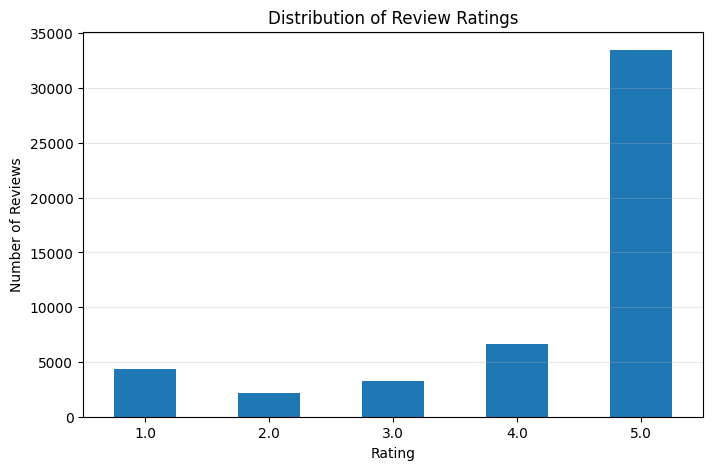

In [16]:
# วัตถุประสงค์: ดูว่าในตัวอย่าง 50,000 reviews ลูกค้าให้คะแนนระดับใดมากที่สุด
# ============================================================
# 5.1 การกระจายของ Rating
# ============================================================

rating_counts = (
    analysis_df["rating"]
    .value_counts()
    .sort_index()
)

print("===== Rating Distribution =====")
print(rating_counts)

# Percentage
rating_percent = (
    analysis_df["rating"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\n===== Rating Percentage =====")
for rating, percent in rating_percent.items():
    print(f"Rating {rating:.0f}: {percent:.2f}%")

# Plot
plt.figure(figsize=(8, 5))

rating_counts.plot(
    kind="bar"
)

plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

#### สรุปผลการวิเคราะห์การกระจายตัวของ Rating

จากการวิเคราะห์การกระจายของ `Rating` พบว่า Rating แต่ละระดับมีจำนวนแตกต่างกัน โดยสามารถเห็นได้ชัดว่าคะแนนระดับ `5.0` มีจำนวน Review มากที่สุด ซึ่งช่วยสะท้อนว่าลูกค้าส่วนมากให้คะแนนสินค้าใน `ระดับดีมาก` จากกลุ่มตัวอย่าง 50,000 reviews

### 5.2 การกระจายของ Reviews ตาม Product

In [17]:
# วัตถุประสงค์: ดูว่าสินค้าแต่ละรายการได้รับ Review มากน้อยแตกต่างกันอย่างไร และหา Product ที่มีจำนวน Reviews สูงสุดใน Sample
# ============================================================
# 5.2 การกระจายของ Reviews ตาม Product
# ============================================================

product_review_counts = (
    analysis_df
    .groupby(["parent_asin", "title"])
    .size()
    .reset_index(name="review_count")
    .sort_values("review_count", ascending=False)
)

print("===== Top 10 Products by Number of Reviews =====")
display(product_review_counts.head(10))

===== Top 10 Products by Number of Reviews =====


,parent_asin,title,review_count
20582,B09857JRP2,GLS Audio Instrument Cable - Amp Cord for Bass...,126
21708,B09W4F2X6S,"BONAOK Wireless Bluetooth Karaoke Microphone, ...",121
24256,B0C6H9T5T6,"Blue Yeti USB Microphone for PC, Mac, Gaming, ...",108
22850,B0BHSG5C3G,"Snark SN5X Clip-On Tuner for Guitar, Bass & Vi...",97
22620,B0BCK6L7S5,"Donner Guitar Delay Pedal, Yellow Fall Analog ...",97
6412,B00DY1F2CS,"Neewer Microphone Arm Stand, Suspension Boom S...",94
23530,B0BSGM6CQ9,Ernie Ball Mondo Slinky Nickelwound Electric G...,87
23614,B0BTR12G3V,Best Choice Products 38in Beginner All Wood Ac...,86
12101,B06ZYJ6SJZ,FIFINE USB Podcast Condenser Microphone Record...,86
19155,B08JMQR2JK,On Stage XCG4 Velveteen Padded Tubular Guitar ...,82


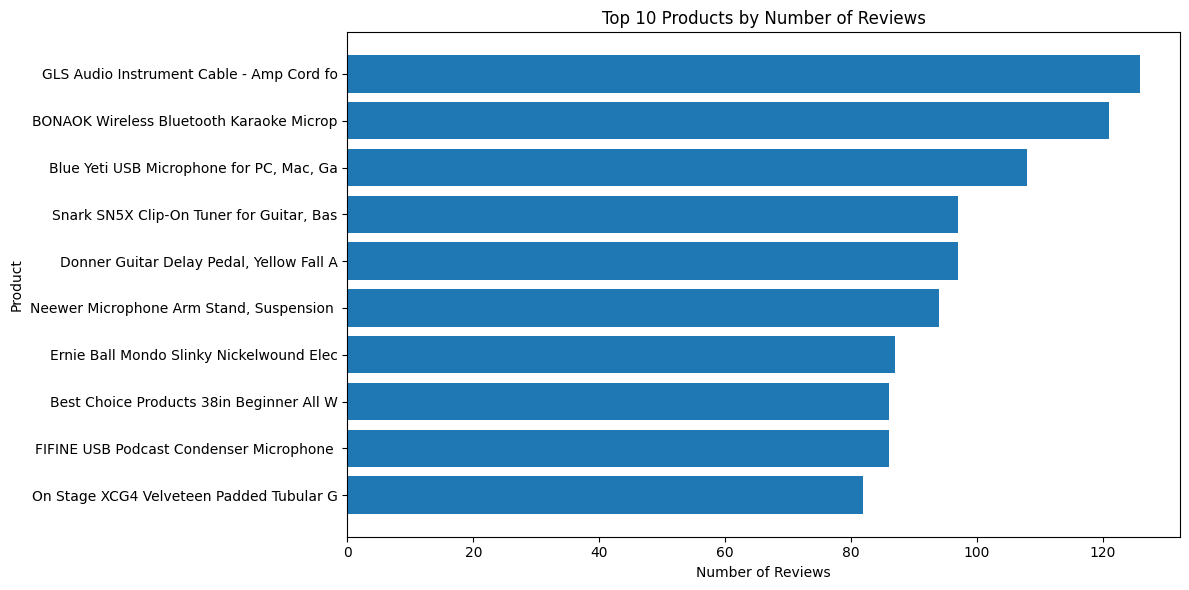

In [18]:
# Top 10 Products
top10_products = product_review_counts.head(10).copy()

# ตัดชื่อสินค้าให้สั้นลงเพื่อให้กราฟอ่านง่าย
top10_products["short_title"] = (
    top10_products["title"]
    .str[:40]
)

plt.figure(figsize=(12, 6))

plt.barh(
    top10_products["short_title"][::-1],
    top10_products["review_count"][::-1]
)

plt.title("Top 10 Products by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [19]:
unique_products = analysis_df["parent_asin"].nunique()

print("Number of unique products:", unique_products)
print("Total reviews:", len(analysis_df))

average_reviews_per_product = (
    len(analysis_df) / unique_products
)

print(
    "Average reviews per product:",
    round(average_reviews_per_product, 2)
)

Number of unique products: 24453
Total reviews: 50000
Average reviews per product: 2.04


###สรุปผลการกระจายของ Reviews ตาม Product
จากการวิเคราะห์ข้อมูล Review จำนวนทั้งหมด 50,000 รายการ พบว่ามีสินค้า `(Unique Products)` จำนวน `24,453 รายการ` โดยมีค่าเฉลี่ยจำนวน Reviews ต่อ Product เท่ากับ `2.04` Reviews ต่อ Product

ผลการวิเคราะห์แสดงให้เห็นว่า แม้ข้อมูลที่นำมาวิเคราะห์จะมีจำนวน Reviews ถึง 50,000 รายการ แต่ Reviews เหล่านี้กระจายอยู่ใน Product จำนวนมาก ทำให้จำนวน `Reviews เฉลี่ยต่อ Product` อยู่ใน `ระดับค่อนข้างต่ำ` ที่ 2.04 Reviews ต่อ Product สะท้อนให้เห็นว่าในกลุ่มตัวอย่างมี Product จำนวนมากที่ได้รับ Reviews เพียงไม่กี่รายการ

ดังนั้น การวิเคราะห์จำนวน Reviews ตาม Product จึงสามารถใช้เพื่อศึกษาว่า Product ใดมีจำนวน Reviews สูงกว่าสินค้าอื่น และช่วยให้เห็นลักษณะการกระจายตัวของ Reviews ภายในกลุ่มตัวอย่างได้ชัดเจนยิ่งขึ้น

### 5.3 การวิเคราะห์ Reviews ตามช่วงเวลา

In [20]:
# ============================================================
# 5.3 การวิเคราะห์ Reviews ตามช่วงเวลา
# ============================================================

analysis_df["review_date"] = pd.to_datetime(
    analysis_df["timestamp"],
    unit="ms"
)

# ตรวจสอบวันที่
print("===== Review Date Range =====")
print("Start:", analysis_df["review_date"].min())
print("End:", analysis_df["review_date"].max())

===== Review Date Range =====
Start: 2001-01-04 15:16:19
End: 2023-09-05 12:24:12.521000


### สรุปผลการวิเคราะห์ Reviews ตามช่วงเวลา
จากการแปลงข้อมูล `timestamp` ให้อยู่ในรูปแบบวันที่ พบว่า Review ในกลุ่มตัวอย่างมีช่วงเวลาตั้งแต่วันที่ 4 มกราคม 2001 เวลา 15:16:19 จนถึงวันที่ 5 กันยายน 2023 เวลา 12:24:12.521

In [21]:
# จำนวน Reviews รายปี

reviews_by_year = (
    analysis_df
    .groupby(analysis_df["review_date"].dt.year)
    .size()
)

print("===== Reviews by Year =====")
print(reviews_by_year)

===== Reviews by Year =====
review_date
2001       1
2002       2
2003       3
2004       8
2005      13
2006      18
2007      48
2008      84
2009      94
2010     276
2011     534
2012     900
2013    1997
2014    2859
2015    4009
2016    4641
2017    4276
2018    4562
2019    5602
2020    6372
2021    6452
2022    5063
2023    2186
dtype: int64


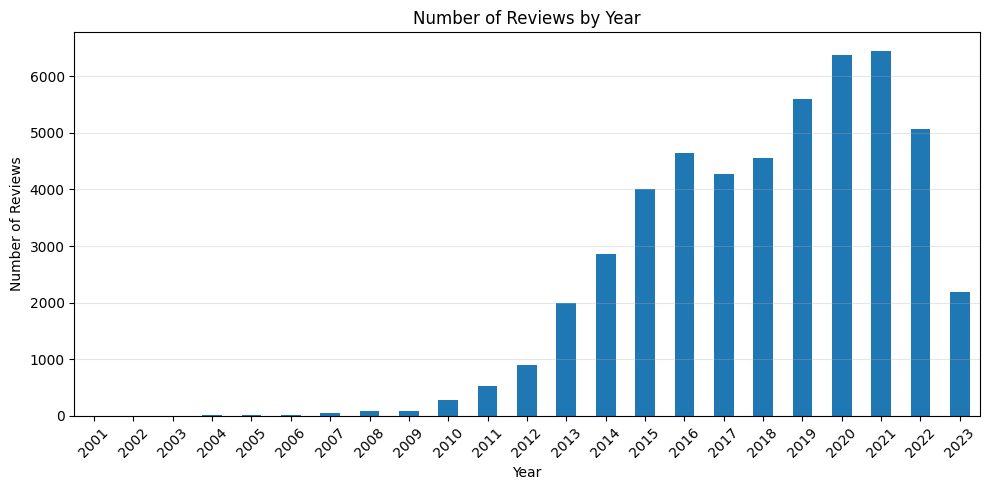

In [22]:
plt.figure(figsize=(10, 5))

reviews_by_year.plot(
    kind="bar"
)

plt.title("Number of Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### จำนวน Reviews รายปี

เมื่อพิจารณาจำนวน `Reviews จำแนกตามปี` พบว่าจำนวน Reviews มี`แนวโน้มเพิ่มขึ้นอย่างต่อเนื่อง`ในช่วงแรกของข้อมูล โดยในปี 2001 มีเพียง 1 Review และเพิ่มขึ้นเป็น 13 Reviews ในปี 2005, 94 Reviews ในปี 2009 และ 276 Reviews ในปี 2010

หลังจากนั้นจำนวน Reviews `เพิ่มขึ้นอย่างชัดเจน` โดยมี 534 Reviews ในปี 2011, 900 Reviews ในปี 2012, 1,997 Reviews ในปี 2013, 2,859 Reviews ในปี 2014 และ 4,009 Reviews ในปี 2015

ในปี 2016 มีจำนวน 4,641 Reviews และปี 2017 มี 4,276 Reviews ขณะที่ปี 2018 มี 4,562 Reviews จากนั้นจำนวน Reviews เพิ่มขึ้นอีกครั้งเป็น 5,602 Reviews ในปี 2019 และ 6,372 Reviews ในปี 2020

ปี `2021 เป็นปีที่มีจำนวน Reviews สูงที่สุด` ในข้อมูลชุดนี้ โดยมีจำนวน 6,452 Reviews หลังจากนั้นจำนวน Reviews ลดลงเป็น 5,063 Reviews ในปี 2022 และเหลือ 2,186 Reviews ในปี 2023 อย่างไรก็ตาม ข้อมูลปี 2023 ครอบคลุมเพียงช่วงวันที่ 1 มกราคมถึง 5 กันยายน จึงไม่ควรนำจำนวน Reviews ของปี 2023 ไปเปรียบเทียบกับปีที่มีข้อมูลครบทั้งปีโดยตรง

โดยสรุป ช่วงปี 2019–2022 เป็นช่วงที่มีจำนวน Reviews ในระดับสูงเมื่อเปรียบเทียบกับช่วงก่อนหน้า และปี 2021 มีจำนวน Reviews สูงสุดในกลุ่มตัวอย่างที่ 6,452 Reviews

In [23]:
reviews_by_month = (
    analysis_df
    .set_index("review_date")
    .resample("M")
    .size()
)

print("===== Monthly Reviews =====")
display(reviews_by_month.head(20))

===== Monthly Reviews =====


/tmp/ipykernel_653/2015618365.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,0
review_date,
2001-01-31,1
2001-02-28,0
2001-03-31,0
2001-04-30,0
2001-05-31,0
2001-06-30,0
2001-07-31,0
2001-08-31,0
2001-09-30,0


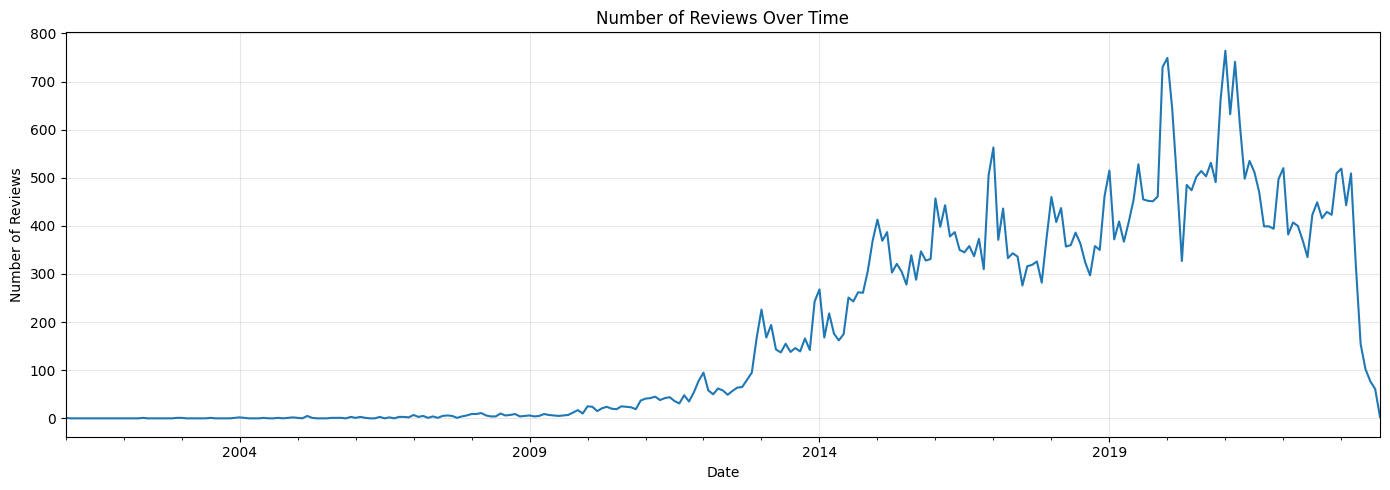

In [24]:
plt.figure(figsize=(14, 5))

reviews_by_month.plot()

plt.title("Number of Reviews Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_653/3152686850.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["rating"]


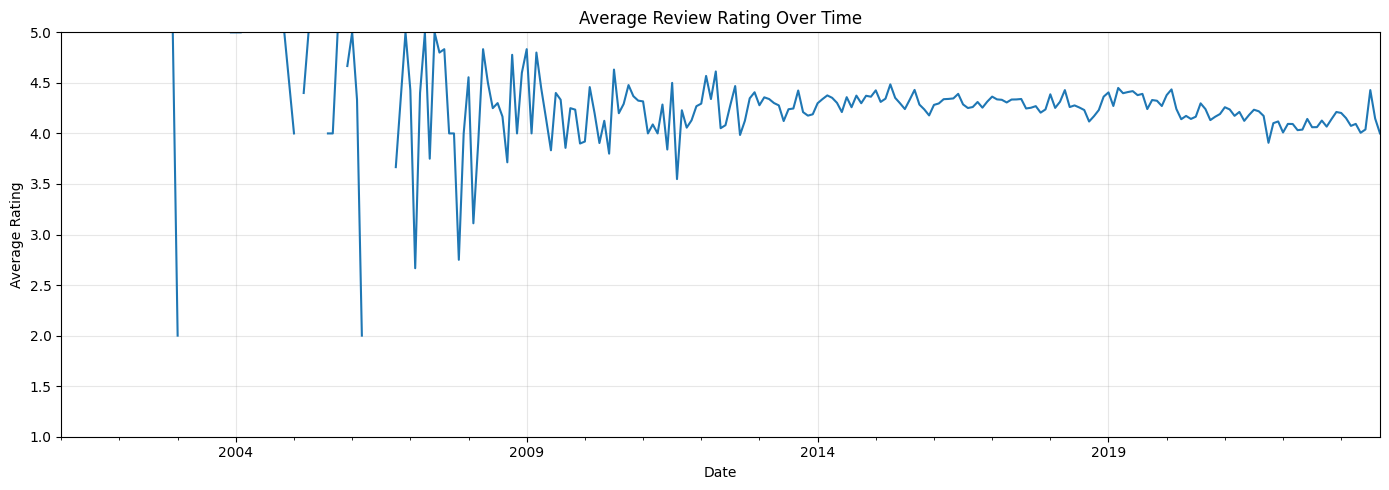

In [25]:
monthly_rating = (
    analysis_df
    .set_index("review_date")
    .resample("M")["rating"]
    .mean()
)

plt.figure(figsize=(14, 5))

monthly_rating.plot()

plt.title("Average Review Rating Over Time")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.ylim(1, 5)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### จำนวน Review รายเดือน

การวิเคราะห์รายเดือน พบว่า Reviews มีการกระจายอยู่ในหลายช่วงเวลา โดยในช่วงต้นของ Dataset มี`บางเดือนที่ไม่มี Reviews` และ`บางเดือนมี Reviews เพียงเล็กน้อย` ซึ่งสอดคล้องกับจำนวน Reviews รายปีที่มีจำนวนน้อยในช่วงปีแรก ๆ ของข้อมูล

### 5.4 การเปรียบเทียบ Review Rating กับ Product Average Rating

In [26]:
# ============================================================
# 5.4 Review Rating vs Product Average Rating
# ============================================================

comparison = analysis_df[
    ["rating", "average_rating"]
].dropna()

print("===== Rating Comparison =====")
display(
    comparison.describe()
)

===== Rating Comparison =====


,rating,average_rating
count,50000.000000,50000.000000
mean,4.252340,4.373490
std,1.279663,0.412278
min,1.000000,1.000000
25%,4.000000,4.200000
50%,5.000000,4.500000
75%,5.000000,4.600000
max,5.000000,5.000000


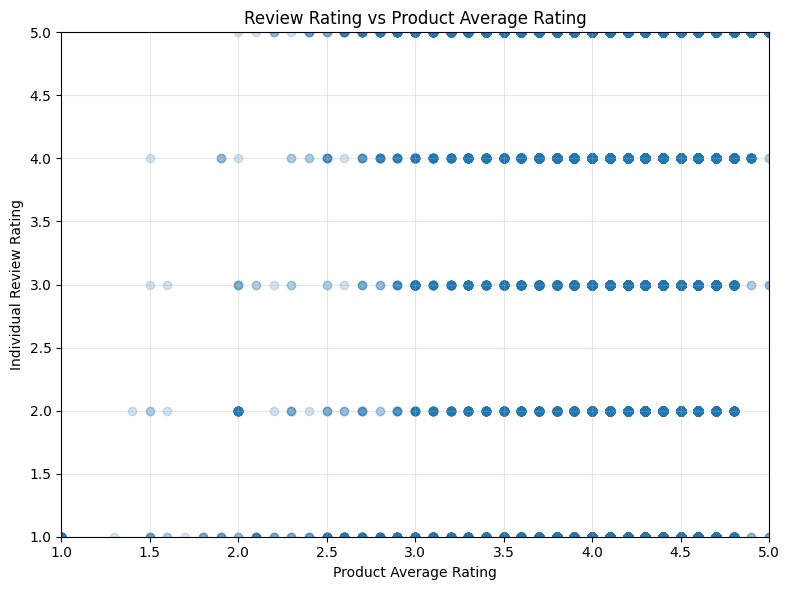

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    comparison["average_rating"],
    comparison["rating"],
    alpha=0.2
)

plt.title(
    "Review Rating vs Product Average Rating"
)

plt.xlabel("Product Average Rating")
plt.ylabel("Individual Review Rating")

plt.xlim(1, 5)
plt.ylim(1, 5)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
print("===== Mean Comparison =====")

print(
    "Mean Individual Review Rating:",
    round(comparison["rating"].mean(), 3)
)

print(
    "Mean Product Average Rating:",
    round(comparison["average_rating"].mean(), 3)
)

===== Mean Comparison =====
Mean Individual Review Rating: 4.252
Mean Product Average Rating: 4.373


In [29]:
comparison = comparison.copy()

comparison["rating_difference"] = (
    comparison["rating"]
    - comparison["average_rating"]
)

print("===== Rating Difference =====")

display(
    comparison["rating_difference"].describe()
)

===== Rating Difference =====


,rating_difference
count,50000.000000
mean,-0.121150
std,1.224492
min,-4.000000
25%,-0.500000
50%,0.300000
75%,0.600000
max,3.000000


### ผลการวิเคราะห์การเปรียบเทียบ Review Rating กับ Product Average Rating

ผลการวิเคราะห์พบว่า `Individual Review Rating` มีค่าเฉลี่ยเท่ากับ `4.252` คะแนน และมีส่วนเบี่ยงเบนมาตรฐานเท่ากับ `1.280`โดยมีค่าต่ำสุด 1 คะแนน และสูงสุด 5 คะแนน

ในขณะที่ `Product Average Rating` มีค่าเฉลี่ยเท่ากับ `4.373` คะแนน และมีส่วนเบี่ยงเบนมาตรฐานเท่ากับ `0.412` โดยมีค่าต่ำสุด 1 คะแนน และสูงสุด 5 คะแนน

เมื่อเปรียบเทียบค่าเฉลี่ย พบว่า Product Average Rating มี`ค่าเฉลี่ยสูงกว่า` Individual Review Rating โดยมีค่าแตกต่างกันประมาณ 0.121 คะแนน

กล่าวคือ ค่าเฉลี่ยของคะแนน Review รายบุคคลอยู่ที่ 4.252 ในขณะที่ค่าเฉลี่ยของ Product Rating อยู่ที่ 4.373

In [30]:
comparison["comparison_group"] = np.where(
    comparison["rating_difference"] > 0,
    "Review > Product Average",
    np.where(
        comparison["rating_difference"] < 0,
        "Review < Product Average",
        "Review = Product Average"
    )
)

comparison_counts = (
    comparison["comparison_group"]
    .value_counts()
)

print("===== Comparison Groups =====")
print(comparison_counts)

===== Comparison Groups =====
comparison_group
Review > Product Average    33324
Review < Product Average    15094
Review = Product Average     1582
Name: count, dtype: int64


### แบ่งข้อมูล 3 กลุ่ม

เมื่อสร้างตัวแปร rating_difference จากสูตร

`Rating Difference` = `Individual Review Rating − Product Average Rating`

พบว่าค่าเฉลี่ยของความแตกต่างเท่ากับ -0.121 ซึ่งสอดคล้องกับผลการเปรียบเทียบค่าเฉลี่ยข้างต้น นอกจากนี้ ค่าต่ำสุดของความแตกต่างเท่ากับ -4.00 และค่าสูงสุดเท่ากับ 3.00 โดยค่ามัธยฐานอยู่ที่ 0.30

เมื่อแบ่งข้อมูลออกเป็น 3 กลุ่มตามความแตกต่างระหว่าง Review Rating กับ Product Average Rating พบว่า

`Review > Product Average จำนวน 33,324 Reviews`

`Review < Product Average จำนวน 15,094 Reviews`

`Review = Product Average จำนวน 1,582 Reviews`

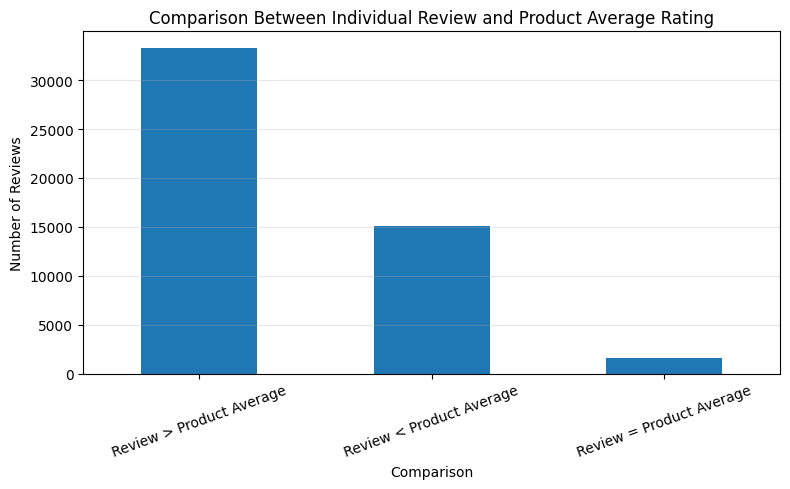

In [31]:
plt.figure(figsize=(8, 5))

comparison_counts.plot(
    kind="bar"
)

plt.title(
    "Comparison Between Individual Review and Product Average Rating"
)

plt.xlabel("Comparison")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### สรุปผลการวิเคราะห์การเปรียบเทียบ Review Rating กับ Product Average Rating

ผลการวิเคราะห์ส่วนนี้แสดงให้เห็นว่า แม้ค่าเฉลี่ยของ Individual Review Rating จะต่ำกว่าค่าเฉลี่ยของ Product Average Rating แต่เมื่อพิจารณาเป็นราย Review กลับพบว่า Reviews จำนวนมากมีคะแนนสูงกว่า Product Average Rating ของสินค้านั้น ๆ ทั้งนี้ ค่า Product Average Rating เป็นค่าที่สรุปในระดับ Product ขณะที่ Individual Review Rating เป็นคะแนนของ Review แต่ละรายการ จึงควรพิจารณาความแตกต่างของระดับข้อมูลดังกล่าวประกอบการตีความผล

### 5.5 สรุปผลการทำ EDA

###ด้าน Product:

พบสินค้าไม่ซ้ำกันทั้งหมด **24,453 รายการ** จาก Reviews จำนวน **50,000 records** หรือเฉลี่ยประมาณ **2.04 Reviews ต่อ Product** แสดงว่า Sample มี Reviews กระจายอยู่ใน Product จำนวนมาก และไม่ได้กระจุกตัวอยู่กับ Product เพียงไม่กี่รายการ


###ด้านช่วงเวลา:
ข้อมูล Reviews ครอบคลุมตั้งแต่ ปี 2001–2023 โดยจำนวน Reviews `เพิ่มขึ้น`อย่างชัดเจนในช่วงหลัง และ`สูงสุดในปี 2021` จำนวน 6,452 Reviews



###ด้าน Rating:

คะแนน Review Rating เฉลี่ยอยู่ที่ **4.252** ขณะที่ Product Average Rating เฉลี่ยอยู่ที่ **4.373** โดยเมื่อเปรียบเทียบคะแนน Review กับ Product Average Rating พบว่า **33,324 Reviews** มีคะแนนสูงกว่า Product Average Rating, **15,094 Reviews** มีคะแนนต่ำกว่า และ **1,582 Reviews** มีคะแนนเท่ากัน

ผลดังกล่าวใช้เป็นข้อมูลพื้นฐานสำหรับขั้นตอนถัดไปในการวิเคราะห์ว่า Text Features ของ Product เช่น ความยาวของ Title และจำนวน Feature Bullets มีรูปแบบความสัมพันธ์กับ Rating แตกต่างกันอย่างไร


###สรุปภาพรวม:
EDA แสดงให้เห็นลักษณะการกระจายของ Reviews ตาม Product, ช่วงเวลา และ Rating ซึ่งช่วยให้เข้าใจโครงสร้างและแนวโน้มของข้อมูลก่อนนำไปวิเคราะห์ในขั้นตอนถัดไป

## 6. Text Features (เวฟ)

## เลือก Client Brief

**B1 ปรับปรุงสินค้า**

- **ลูกค้าคือทีม:** Product Team
- **เขากำลังจะตัดสินใจเรื่อง:** สินค้ากลุ่มไหนควรได้รับการพิจารณาตรวจสอบและปรับปรุงก่อน โดยพิจารณาจากสัญญาณปัญหาที่สะท้อนผ่าน Customer Rating
- **ถ้าตัดสินใจผิดจะเสียอะไร:** อาจใช้งบประมาณและทรัพยากรในการตรวจสอบหรือปรับปรุงสินค้ากับกลุ่มหรือประเด็นที่มีความสำคัญน้อยกว่า ในขณะที่สินค้าที่มีสัญญาณปัญหามากกว่าอาจไม่ได้รับการตรวจสอบก่อน
- **คำถามที่เราจะตอบให้เขา:** สินค้ากลุ่มใดมีสัญญาณปัญหาจาก Customer Rating มากกว่า และลักษณะของ Product Metadata เช่น ราคา ความยาวของ Title และจำนวน Feature Bullets มีความสัมพันธ์กับ Bad Review อย่างไร เพื่อใช้เป็นข้อมูลประกอบการพิจารณาว่าสินค้ากลุ่มใดควรนำไปตรวจสอบและปรับปรุงก่อน
- **เกณฑ์เบื้องต้น:** กำหนด `rating ≤ 2` เป็น Bad Review และใช้สัดส่วน Bad Review เป็นหนึ่งในตัวชี้วัดสัญญาณปัญหาของสินค้า
- **สมมติฐานตั้งต้นของเรา:** สินค้าหรือกลุ่มสินค้าที่มีสัดส่วน Bad Review สูงอาจมีลักษณะของ Product Metadata ที่แตกต่างจากสินค้าที่มีสัดส่วน Bad Review ต่ำ

### 6.1 ตรวจสอบข้อมูล Text จาก Product Metadata

In [32]:
# Check text-related columns for Text Feature preparation

text_cols = ["title", "features", "description"]

for col in text_cols:
    print(f"\n--- {col} ---")
    print("Missing values:", analysis_df[col].isna().sum())
    print("Non-missing:", analysis_df[col].notna().sum())


--- title ---
Missing values: 0
Non-missing: 50000

--- features ---
Missing values: 0
Non-missing: 50000

--- description ---
Missing values: 0
Non-missing: 50000


In [33]:
# Check truly empty values in text columns

for col in ["title", "features", "description"]:
    empty_count = analysis_df[col].apply(
        lambda x: x is None or (isinstance(x, str) and x.strip() == "") or x == []
    ).sum()

    print(f"{col}:")
    print(f"  Truly empty: {empty_count}")
    print(f"  Non-empty:   {len(analysis_df) - empty_count}")

title:
  Truly empty: 7
  Non-empty:   49993
features:
  Truly empty: 3112
  Non-empty:   46888
description:
  Truly empty: 17561
  Non-empty:   32439


In [34]:
# Inspect the structure of the features column

print("Data type of features:")
print(type(analysis_df["features"].iloc[0]))

print("\nExample 1:")
print(analysis_df["features"].iloc[0])

print("\nExample 2:")
print(analysis_df["features"].iloc[1])

print("\nExample 3:")
print(analysis_df["features"].iloc[2])

Data type of features:
<class 'list'>

Example 1:
['CAMO colored tuner!', 'Fully Chromatic Tuner - enabling it to tune any instrument', 'Clip on tune - Rotates 360 degrees for easy viewing', 'Compact, good-looking, very durable and easy to use', 'High brightness LED displays string number and pitch difference, can be used in dark places and stages']

Example 2:
['Preamp/Overdrive/Disttion Pedal f Electric Guitar']

Example 3:
["MINI GUITAR FOR LEARNING: This beginner's acoustic guitar teaches children the basics of music, helping them learn tone, rhythm, and hand-eye coordination to play notes and songs.", 'AUTHENTIC STRINGS: 6 realistic stainless steel guitar strings that look and feel just like the real thing! - not simple wire or nylon like most other toy guitars.', 'REAL GUITAR SOUNDS: This fun guitar for kids features adjustable, working strings that produce authentic musical notes, motivating your little ones to keep practicing their craft.', 'KID-SIZED: Measuring 23" tall x 8" w

In [35]:
# Check current columns in analysis_df

print("Number of columns:", len(analysis_df.columns))
print("\nAll columns:")
print(analysis_df.columns.tolist())

Number of columns: 12

All columns:
['user_id', 'parent_asin', 'rating', 'timestamp', 'title', 'features', 'description', 'average_rating', 'rating_number', 'price', 'store', 'review_date']


#### ตรวจสอบข้อมูล Text จาก Product Metadata

ตรวจสอบความพร้อมของข้อมูล `title`, `features` และ `description` จาก **Product Metadata** ก่อนสร้าง Text Features เพื่อใช้ในการวิเคราะห์ความสัมพันธ์ระหว่างลักษณะของ Product กับ Customer Rating และ Bad Review

เนื่องจากข้อมูลว่างอาจอยู่ในรูปแบบ `None`, `NaN`, empty string (`""`) หรือ empty list (`[]`) จึงตรวจสอบทั้ง Missing Values และข้อมูลที่ว่างจริงเพิ่มเติม

ผลการตรวจสอบพบว่า:

- `title` มีข้อมูลว่างจริง **7 records (0.01%)**
- `features` มีข้อมูลว่างจริง **3,112 records (6.22%)**
- `description` มีข้อมูลว่างจริง **17,561 records (35.12%)**

นอกจากนี้ `features` มีโครงสร้างเป็น **list ของข้อความแต่ละรายการ** จึงสามารถนำจำนวนรายการใน list มาใช้สร้าง Text Feature เพื่อสะท้อนจำนวน Feature Bullets ของสินค้าได้

จากผลการตรวจสอบ จึงเลือกใช้ `title` และ `features` เป็นข้อมูลหลักในการสร้าง Text Features เนื่องจากมีข้อมูลพร้อมใช้งานมากกว่า `description` และสามารถนำไปวิเคราะห์ร่วมกับ Rating และเกณฑ์ Bad Review ที่กำหนดในขั้นตอนถัดไปได้

### 6.2 สร้าง Text Feature ที่ 1: `title_word_count`

สร้าง `title_word_count` เพื่อวัดจำนวนคำในชื่อสินค้าจาก `title` โดยใช้จำนวนคำเป็นตัวแทนของความยาวของชื่อสินค้า

จากข้อมูลตัวอย่าง 50,000 records พบว่า Q1 = 8 คำ, Median = 14 คำ และ Q3 = 23 คำ จึงแบ่งความยาวของ Title ตาม quartile เป็น 4 กลุ่ม ได้แก่ Short (≤8), Medium (9–14), Long (15–23) และ Very Long (24+) เพื่อใช้เปรียบเทียบลักษณะของสินค้าแต่ละกลุ่มกับ `rating` และสัดส่วน Bad Review (`rating ≤ 2`) ในขั้นตอนการวิเคราะห์ถัดไป

===== title_word_count ====


,title_word_count
count,50000.000000
mean,15.728240
std,8.450677
min,0.000000
25%,8.000000
50%,14.000000
75%,23.000000
max,83.000000



===== จำนวน Records ตามกลุ่มความยาว Title ====
title_length_group
Short (≤8)         13047
Medium (9-14)      12539
Long (15-23)       12626
Very Long (24+)    11788
Name: count, dtype: int64


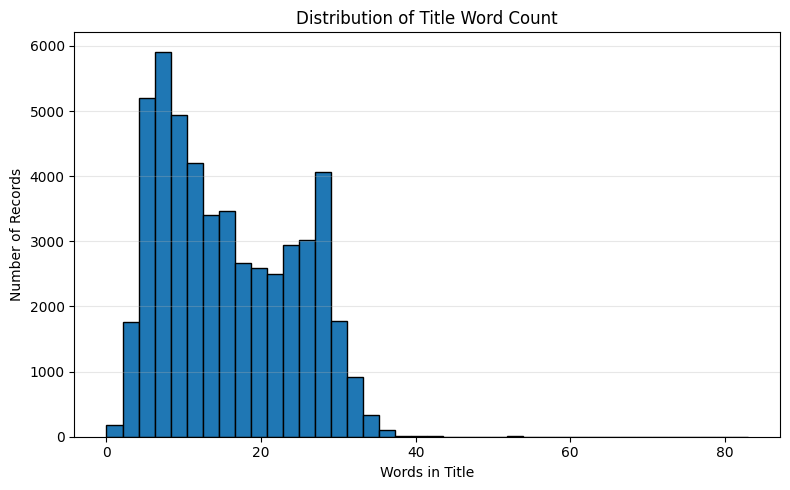

In [36]:
# ============================================================
# 6.2 Text Feature 1: title_word_count
# ============================================================

# นับจำนวนคำในชื่อสินค้า
analysis_df["title_word_count"] = (
    analysis_df["title"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

print("===== title_word_count ====")
display(analysis_df["title_word_count"].describe())

# แบ่งกลุ่มความยาว Title ตาม quartile
analysis_df["title_length_group"] = pd.cut(
    analysis_df["title_word_count"],
    bins=[-1, 8, 14, 23, np.inf],
    labels=[
        "Short (≤8)",
        "Medium (9-14)",
        "Long (15-23)",
        "Very Long (24+)"
    ]
)

print("\n===== จำนวน Records ตามกลุ่มความยาว Title ====")
print(analysis_df["title_length_group"].value_counts().sort_index())

# แสดงการกระจายของจำนวนคำใน Title
plt.figure(figsize=(8, 5))
analysis_df["title_word_count"].plot(
    kind="hist",
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Title Word Count")
plt.xlabel("Words in Title")
plt.ylabel("Number of Records")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretation of Results

จากผลการวิเคราะห์ `title_word_count` ของข้อมูลจำนวน 50,000 records พบว่า ชื่อสินค้ามีจำนวนคำเฉลี่ย **15.73 คำ** และมีค่ามัธยฐานอยู่ที่ **14 คำ** โดย Q1 อยู่ที่ 8 คำ และ Q3 อยู่ที่ 23 คำ

เมื่อแบ่งข้อมูลตาม quartile พบว่า

- **Short (≤8 คำ)** มี 13,047 records
- **Medium (9–14 คำ)** มี 12,539 records
- **Long (15–23 คำ)** มี 12,626 records
- **Very Long (24+ คำ)** มี 11,788 records

จำนวน records ในแต่ละกลุ่มค่อนข้างใกล้เคียงกัน เนื่องจากจุดแบ่งถูกกำหนดจาก Q1, Median และ Q3 ของข้อมูล

ดังนั้น `title_word_count` สามารถใช้เป็น Text Feature สำหรับเปรียบเทียบความแตกต่างของ `rating` และสัดส่วน Bad Review ระหว่างกลุ่มความยาวของ Title ในขั้นตอนถัดไปได้ อย่างไรก็ตาม ผลลัพธ์ในขั้นตอนนี้แสดงเพียงการกระจายของความยาว Title และยังไม่สามารถสรุปได้ว่าความยาวของชื่อสินค้ามีความสัมพันธ์กับ Rating หรือ Bad Review จนกว่าจะทำการวิเคราะห์เปรียบเทียบเพิ่มเติม

### 6.3 สร้าง Text Feature ที่ 2: `feature_bullet_count`

สร้าง `feature_bullet_count` เพื่อวัดจำนวน Feature Bullets ที่ระบุไว้ใน Product Metadata ของสินค้า โดยใช้จำนวน bullet เป็นตัวแทนของปริมาณรายละเอียดที่ผู้ขายนำเสนอในส่วน Features

เนื่องจาก `features` มีลักษณะเป็น list ของข้อความ จึงนับจำนวนสมาชิกใน list ของแต่ละสินค้า

จากนั้นแบ่งสินค้าออกเป็น 4 กลุ่ม ได้แก่ 0 bullets, 1–3 bullets, 4–5 bullets และ 6+ bullets เพื่อใช้เปรียบเทียบความแตกต่างของ `rating` และสัดส่วน Bad Review (`rating ≤ 2`) ระหว่างกลุ่มในขั้นตอนการวิเคราะห์ต่อไป

===== feature_bullet_count ====


,feature_bullet_count
count,50000.000000
mean,4.481080
std,1.655952
min,0.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,33.000000



===== จำนวน Records ตามจำนวน Feature Bullets ====
feature_bullet_group
0 bullets       3112
1-3 bullets     4938
4-5 bullets    37770
6+ bullets      4180
Name: count, dtype: int64


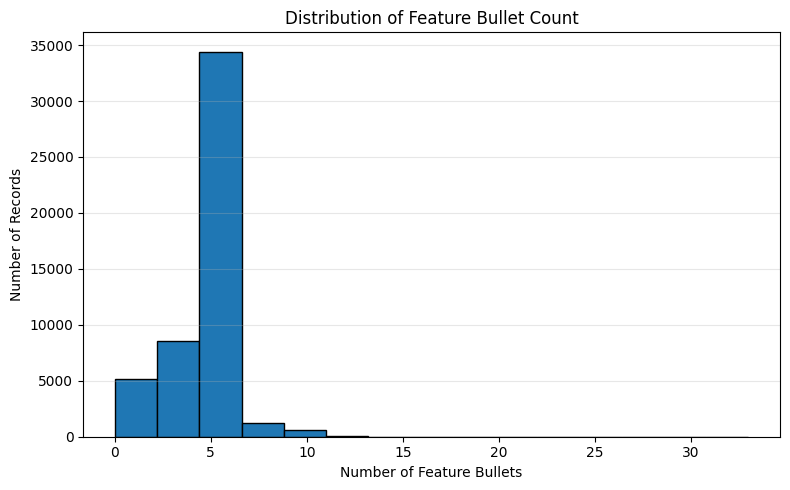

In [37]:
# ============================================================
# 6.3 Text Feature 2: feature_bullet_count
# ============================================================

# นับจำนวน Feature Bullets ของแต่ละสินค้า
analysis_df["feature_bullet_count"] = analysis_df["features"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

print("===== feature_bullet_count ====")
display(analysis_df["feature_bullet_count"].describe())

# แบ่งกลุ่มตามจำนวน Feature Bullets
analysis_df["feature_bullet_group"] = pd.cut(
    analysis_df["feature_bullet_count"],
    bins=[-1, 0, 3, 5, np.inf],
    labels=[
        "0 bullets",
        "1-3 bullets",
        "4-5 bullets",
        "6+ bullets"
    ]
)

print("\n===== จำนวน Records ตามจำนวน Feature Bullets ====")
print(analysis_df["feature_bullet_group"].value_counts().sort_index())

# แสดงการกระจายของจำนวน Feature Bullets
plt.figure(figsize=(8, 5))

analysis_df["feature_bullet_count"].plot(
    kind="hist",
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of Feature Bullet Count")
plt.xlabel("Number of Feature Bullets")
plt.ylabel("Number of Records")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretation of Results

จากการวิเคราะห์ `feature_bullet_count` ของข้อมูลจำนวน 50,000 records พบว่า สินค้ามีจำนวน Feature Bullets เฉลี่ย **4.48 bullets** และมีค่ามัธยฐาน **5 bullets** โดยมีค่า Q1 = **4 bullets** และ Q3 = **5 bullets**

เมื่อพิจารณาจาก Histogram พบว่าจำนวน Feature Bullets ส่วนใหญ่อยู่ในช่วงประมาณ **4–5 bullets** ขณะที่บางสินค้ามีจำนวน bullets สูงกว่านั้น โดยค่าต่ำสุดอยู่ที่ **0 bullets** และค่าสูงสุดอยู่ที่ **33 bullets**

เมื่อแบ่งข้อมูลตามจำนวน Feature Bullets พบว่า

- **0 bullets:** 3,112 records
- **1–3 bullets:** 4,938 records
- **4–5 bullets:** 37,770 records
- **6+ bullets:** 4,180 records

กลุ่ม **4–5 bullets มีจำนวนมากที่สุด** คิดเป็นประมาณ **75.54%** ของข้อมูลทั้งหมด ขณะที่กลุ่มที่ไม่มี Feature Bullets มี 3,112 records หรือประมาณ **6.22%**

ดังนั้น `feature_bullet_count` สามารถใช้เป็น Text Feature เพื่อสะท้อนปริมาณรายละเอียดที่แสดงในส่วน Features ของสินค้า และนำไปเปรียบเทียบความแตกต่างของ `rating` และสัดส่วน Bad Review (`rating ≤ 2`) ระหว่างกลุ่มได้ในขั้นตอนถัดไป

อย่างไรก็ตาม ผลลัพธ์ในขั้นตอนนี้แสดงเพียงจำนวนและการกระจายของ Feature Bullets ยังไม่สามารถสรุปได้ว่าจำนวน Feature Bullets มีความสัมพันธ์กับ Rating หรือ Bad Review ในลักษณะใด จนกว่าจะทำการวิเคราะห์เปรียบเทียบเพิ่มเติม

### 6.4 วิเคราะห์ Text Features กับ Rating และ Bad Review

หลังจากสร้าง Text Features จาก Product Metadata ได้แก่ `title_word_count` และ `feature_bullet_count` แล้ว ขั้นตอนนี้จะนำ Text Features ดังกล่าวมาเปรียบเทียบกับ Customer Rating เพื่อศึกษาว่าลักษณะของข้อมูลสินค้าแต่ละแบบมีรูปแบบของ Rating และ Bad Review แตกต่างกันหรือไม่

ในการวิเคราะห์นี้กำหนด **Bad Review = `rating ≤ 2`** ตามเกณฑ์ที่กำหนดไว้ใน Client Brief เพื่อใช้เป็นสัญญาณเบื้องต้นของปัญหาที่อาจต้องนำสินค้าไปตรวจสอบเพิ่มเติม

การวิเคราะห์จะแบ่งเป็น 2 ส่วน ได้แก่

1. เปรียบเทียบกลุ่มความยาวของ Title และจำนวน Feature Bullets กับค่าเฉลี่ย Review Rating และสัดส่วน Bad Review
2. คำนวณ Spearman Correlation ระหว่าง Text Features กับ `rating` และ `average_rating` เพื่อดูทิศทางและขนาดของความสัมพันธ์

ผลการวิเคราะห์นี้ใช้เป็นหลักฐานประกอบ Client Brief **B1 ปรับปรุงสินค้า | Product** โดยมุ่งดูว่า Text Features ของสินค้าแต่ละกลุ่มมีรูปแบบของ Bad Review แตกต่างกันหรือไม่ เพื่อใช้เป็นข้อมูลประกอบการพิจารณาว่าสินค้าหรือกลุ่มสินค้าใดควรถูกนำไปตรวจสอบเพิ่มเติม

ทั้งนี้ การวิเคราะห์เป็นการวิเคราะห์เชิงพรรณนาและความสัมพันธ์ จึงไม่สามารถสรุปได้ว่า Text Features เป็นสาเหตุที่ทำให้ Rating สูงหรือต่ำ หรือเป็นสาเหตุโดยตรงของ Bad Review

In [38]:
print("===== Columns in analysis_df ====")
print(analysis_df.columns.tolist())

===== Columns in analysis_df ====
['user_id', 'parent_asin', 'rating', 'timestamp', 'title', 'features', 'description', 'average_rating', 'rating_number', 'price', 'store', 'review_date', 'title_word_count', 'title_length_group', 'feature_bullet_count', 'feature_bullet_group']


===== Title Length vs Rating & Bad Review =====


,reviews,mean_review_rating,mean_product_rating,bad_reviews,bad_review_pct
title_length_group,,,,,
Short (≤8),13047,4.308,4.361,1495,11.459
Medium (9-14),12539,4.290,4.377,1528,12.186
Long (15-23),12626,4.201,4.371,1819,14.407
Very Long (24+),11788,4.205,4.387,1740,14.761



===== Feature Bullets vs Rating & Bad Review =====


,reviews,mean_review_rating,mean_product_rating,bad_reviews,bad_review_pct
feature_bullet_group,,,,,
0 bullets,3112,4.091,4.154,522,16.774
1-3 bullets,4938,4.288,4.333,591,11.968
4-5 bullets,37770,4.261,4.390,4916,13.016
6+ bullets,4180,4.252,4.436,553,13.230


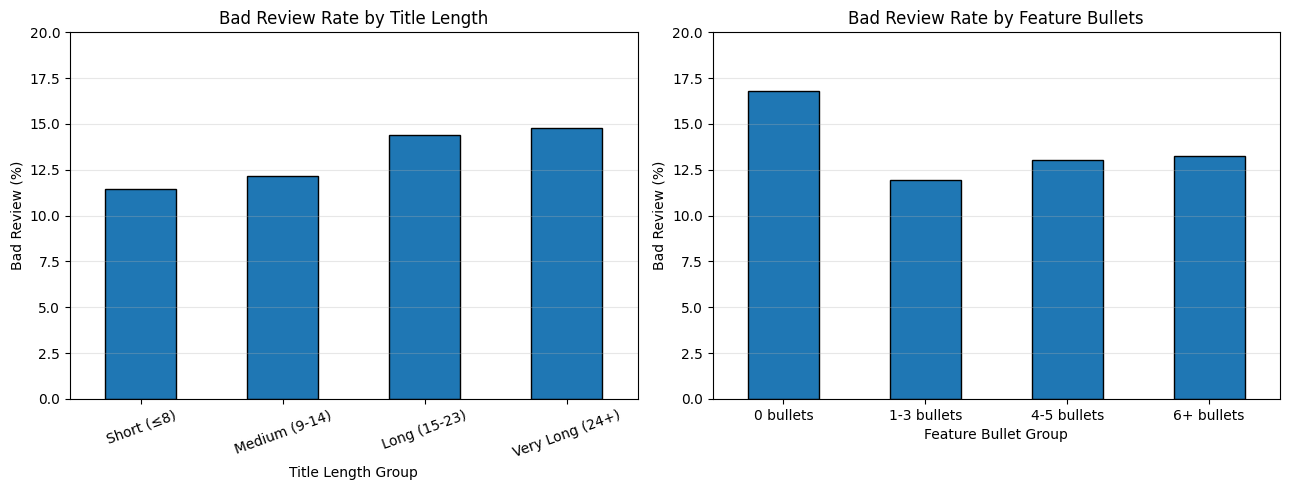

In [39]:
from scipy.stats import spearmanr

def group_summary(group_col):
    return (
        analysis_df.groupby(group_col, observed=True)
        .agg(
            reviews=("rating", "size"),
            mean_review_rating=("rating", "mean"),
            mean_product_rating=("average_rating", "mean"),
            bad_reviews=("rating", lambda s: (s <= 2).sum()),
            bad_review_pct=("rating", lambda s: (s <= 2).mean() * 100),
        )
        .round(3)
    )

print("===== Title Length vs Rating & Bad Review =====")
title_summary = group_summary("title_length_group")
display(title_summary)

print("\n===== Feature Bullets vs Rating & Bad Review =====")
feature_summary = group_summary("feature_bullet_group")
display(feature_summary)

# ===== Visualization: Text Features vs Bad Review =====

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Title Length vs Bad Review
title_summary["bad_review_pct"].plot(
    kind="bar",
    ax=axes[0],
    edgecolor="black"
)

axes[0].set_title("Bad Review Rate by Title Length")
axes[0].set_xlabel("Title Length Group")
axes[0].set_ylabel("Bad Review (%)")
axes[0].set_ylim(0, 20)
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)


# 2. Feature Bullets vs Bad Review
feature_summary["bad_review_pct"].plot(
    kind="bar",
    ax=axes[1],
    edgecolor="black"
)

axes[1].set_title("Bad Review Rate by Feature Bullets")
axes[1].set_xlabel("Feature Bullet Group")
axes[1].set_ylabel("Bad Review (%)")
axes[1].set_ylim(0, 20)
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
# ===== Spearman Correlation =====

corr_rows = []

for feat in ["title_word_count", "feature_bullet_count"]:
    for target in ["rating", "average_rating"]:
        tmp = analysis_df[[feat, target]].dropna()

        rho, p = spearmanr(tmp[feat], tmp[target])

        corr_rows.append({
            "Text Feature": feat,
            "Rating": target,
            "Spearman rho": round(rho, 4),
            "p-value": p
        })

print("===== Spearman Correlation =====")
display(pd.DataFrame(corr_rows))

===== Spearman Correlation =====


,Text Feature,Rating,Spearman rho,p-value
0,title_word_count,rating,-0.0256,9.707971e-09
1,title_word_count,average_rating,-0.0286,1.506742e-10
2,feature_bullet_count,rating,0.0059,1.887239e-01
3,feature_bullet_count,average_rating,0.0670,7.355430e-51


#### Interpretation of Results

จากการเปรียบเทียบ Text Features กับ Customer Rating และ Bad Review ในข้อมูลตัวอย่าง 50,000 records พบรูปแบบที่แตกต่างกันระหว่างความยาวของ Title และจำนวน Feature Bullets

**1. Title Length กับ Rating และ Bad Review**

กลุ่ม Short (≤8 คำ) มีค่าเฉลี่ย Review Rating เท่ากับ **4.308** และมีสัดส่วน Bad Review (`rating ≤ 2`) เท่ากับ **11.459%** ขณะที่กลุ่ม Very Long (24+ คำ) มีค่าเฉลี่ย Review Rating เท่ากับ **4.205** และมีสัดส่วน Bad Review เท่ากับ **14.761%**

เมื่อเปรียบเทียบ Short กับ Very Long พบว่า Mean Review Rating ต่ำลง **0.103 คะแนน** และสัดส่วน Bad Review สูงขึ้น **3.302 percentage points**

อย่างไรก็ตาม Spearman correlation ระหว่าง `title_word_count` กับ `rating` มีค่า **-0.0256** ซึ่งใกล้ศูนย์ แสดงว่าความสัมพันธ์โดยรวมมีขนาดเล็กมาก แม้ p-value จะมีค่าต่ำกว่า 0.001 เช่นเดียวกับความสัมพันธ์ระหว่าง `title_word_count` กับ `average_rating` ที่มีค่า rho เท่ากับ **-0.0286**

ดังนั้น ผลดังกล่าวสะท้อนว่าในข้อมูลตัวอย่างนี้ Title ที่ยาวมากมีรูปแบบของ Rating และ Bad Review แตกต่างจาก Title ที่สั้นกว่า แต่ขนาดความสัมพันธ์โดยรวมระหว่างจำนวนคำใน Title กับ Rating มีค่อนข้างน้อย

**2. Feature Bullets กับ Rating และ Bad Review**

กลุ่มที่ไม่มี Feature Bullets มีค่าเฉลี่ย Review Rating ต่ำที่สุดที่ **4.091** และมีสัดส่วน Bad Review สูงที่สุดที่ **16.774%** ขณะที่กลุ่ม 1–3 bullets มีค่าเฉลี่ย Review Rating **4.288** และ Bad Review **11.968%**

อย่างไรก็ตาม Spearman correlation ระหว่าง `feature_bullet_count` กับ `rating` เท่ากับ **0.0059** และมี p-value เท่ากับ **0.1887** จึงยังไม่มีหลักฐานเพียงพอที่จะสรุปว่าจำนวน Feature Bullets มีความสัมพันธ์กับ Review Rating โดยตรง

สำหรับ `average_rating` พบ Spearman correlation เท่ากับ **0.0670** ซึ่งเป็นความสัมพันธ์ทางบวกที่มีขนาดเล็กมาก แม้จะมี p-value ต่ำกว่า 0.001 แต่ขนาดของความสัมพันธ์ยังอยู่ในระดับต่ำ

**3. Business Implication สำหรับ B1**

จากผลการวิเคราะห์ พบว่าสินค้าที่มี **Title ยาวมาก** และสินค้าที่ **ไม่มี Feature Bullets** มีสัดส่วน Bad Review สูงกว่าบางกลุ่ม โดยเฉพาะกลุ่ม Very Long Title มี Bad Review **14.761%** และกลุ่ม 0 bullets มี Bad Review **16.774%**

ผลนี้สามารถใช้เป็นสัญญาณเบื้องต้นเพื่อช่วย Product Team ระบุกลุ่มสินค้าที่ควรนำไปตรวจสอบเพิ่มเติม อย่างไรก็ตาม Text Features เพียงอย่างเดียวไม่ควรถูกใช้เป็นเกณฑ์ตัดสินว่าสินค้าใดต้องปรับปรุง เนื่องจาก Spearman correlation โดยรวมมีขนาดเล็ก และผลการวิเคราะห์นี้เป็นเพียงความสัมพันธ์เชิงพรรณนา ไม่สามารถสรุปได้ว่า Title หรือ Feature Bullets เป็นสาเหตุของ Bad Review

### 6.5 วิเคราะห์กลุ่ม Product จาก Text Features

จากผลการวิเคราะห์ในข้อ 6.4 พบว่า Text Features แต่ละตัวมีรูปแบบของ Rating และ Bad Review แตกต่างกัน จึงนำ `title_length_group` และ `feature_bullet_group` มาพิจารณาร่วมกัน เพื่อระบุกลุ่ม Product ที่มีลักษณะของ Product Metadata แตกต่างกัน และเปรียบเทียบค่าเฉลี่ย Review Rating รวมถึงสัดส่วน Bad Review (`rating ≤ 2`) ของแต่ละกลุ่ม

การวิเคราะห์นี้ช่วยให้เห็นว่ากลุ่ม Product ที่มีลักษณะของ Title และ Feature Bullets แบบใดมีสัดส่วน Bad Review สูงกว่า และสามารถใช้เป็นหลักฐานประกอบการระบุประเด็นของ Product Metadata ที่ควรนำไปตรวจสอบเพิ่มเติมในมุมมองของ Product Team

ทั้งนี้ การแบ่งกลุ่มดังกล่าวเป็นการแบ่งตามลักษณะของ Product Metadata ไม่ใช่หมวดหมู่สินค้า และผลลัพธ์เป็นความสัมพันธ์เชิงพรรณนา ไม่สามารถสรุปความเป็นเหตุและผลได้

In [41]:
print(analysis_df.columns.tolist())

['user_id', 'parent_asin', 'rating', 'timestamp', 'title', 'features', 'description', 'average_rating', 'rating_number', 'price', 'store', 'review_date', 'title_word_count', 'title_length_group', 'feature_bullet_count', 'feature_bullet_group']


In [42]:
# ===== 6.5 Product Group by Title Length and Feature Bullets =====

product_text_group_summary = (
    analysis_df
    .groupby(
        ["title_length_group", "feature_bullet_group"],
        observed=True
    )
    .agg(
        records=("rating", "size"),
        products=("parent_asin", "nunique"),
        mean_review_rating=("rating", "mean"),
        mean_product_rating=("average_rating", "mean"),
        bad_reviews=("rating", lambda s: (s <= 2).sum()),
        bad_review_pct=("rating", lambda s: (s <= 2).mean() * 100)
    )
    .reset_index()
)

product_text_group_summary = product_text_group_summary.round(3)

print("===== Product Group by Title Length and Feature Bullets =====")
display(product_text_group_summary)

===== Product Group by Title Length and Feature Bullets =====


,title_length_group,feature_bullet_group,records,products,mean_review_rating,mean_product_rating,bad_reviews,bad_review_pct
0,Short (≤8),0 bullets,598,484,4.254,4.196,71,11.873
1,Short (≤8),1-3 bullets,2570,1672,4.284,4.317,301,11.712
2,Short (≤8),4-5 bullets,8746,4665,4.323,4.377,981,11.217
3,Short (≤8),6+ bullets,1133,436,4.282,4.417,142,12.533
4,Medium (9-14),0 bullets,945,750,4.116,4.137,147,15.556
5,Medium (9-14),1-3 bullets,1752,1069,4.322,4.344,200,11.416
6,Medium (9-14),4-5 bullets,8915,4568,4.296,4.404,1083,12.148
7,Medium (9-14),6+ bullets,927,410,4.348,4.423,98,10.572
8,Long (15-23),0 bullets,898,687,4.029,4.132,164,18.263
9,Long (15-23),1-3 bullets,512,257,4.199,4.395,76,14.844


#### Interpretation of Results

เมื่อพิจารณา `title_length_group` และ `feature_bullet_group` ร่วมกัน พบว่าบางกลุ่มมีค่าเฉลี่ย Review Rating และสัดส่วน Bad Review แตกต่างจากกลุ่มอื่นในข้อมูลตัวอย่าง โดยกลุ่มที่มี Title ยาวและไม่มี Feature Bullets มีสัดส่วน Bad Review ค่อนข้างสูง

กลุ่ม **Very Long (24+) + 0 bullets** มีจำนวน **671 records จาก 503 products** โดยมีค่าเฉลี่ย Review Rating เท่ากับ **3.991** และมีสัดส่วน Bad Review (`rating ≤ 2`) เท่ากับ **20.864%**

เมื่อเปรียบเทียบกับกลุ่ม **Very Long (24+) + 4–5 bullets** ซึ่งมีค่าเฉลี่ย Review Rating **4.221** และสัดส่วน Bad Review **14.277%** พบว่ากลุ่ม Very Long + 0 bullets มีค่าเฉลี่ย Rating ต่ำกว่าประมาณ **0.230 คะแนน** และมีสัดส่วน Bad Review สูงกว่าประมาณ **6.587 percentage points**

ในทิศทางเดียวกัน กลุ่ม **Long (15–23) + 0 bullets** มีค่าเฉลี่ย Review Rating **4.029** และสัดส่วน Bad Review **18.263%** ขณะที่กลุ่ม **Long + 4–5 bullets** มีค่าเฉลี่ย Review Rating **4.216** และสัดส่วน Bad Review **14.092%** ซึ่งแตกต่างกันประมาณ **0.187 คะแนน** และ **4.171 percentage points** ตามลำดับ

ผลลัพธ์นี้จึงสามารถใช้เป็น **สัญญาณเบื้องต้นสำหรับการคัดกรองกลุ่ม Product ที่ควรนำไปตรวจสอบเพิ่มเติม** โดยเฉพาะกลุ่มที่มี Title ยาวและไม่มี Feature Bullets เพื่อพิจารณาความครบถ้วนและความชัดเจนของข้อมูล Product Metadata

อย่างไรก็ตาม ผลลัพธ์นี้เป็นความสัมพันธ์เชิงพรรณนา ไม่สามารถสรุปได้ว่าการไม่มี Feature Bullets หรือการมี Title ที่ยาวเป็นสาเหตุโดยตรงของ Rating ที่ต่ำ เนื่องจากอาจมีปัจจัยอื่นที่เกี่ยวข้องกับ Customer Rating ดังนั้นผลการวิเคราะห์นี้ควรใช้เป็นข้อมูลประกอบการคัดกรองและตรวจสอบเพิ่มเติม ไม่ใช่เกณฑ์ตัดสินว่าสินค้าใดต้องปรับปรุงโดยตรง

### 6.6 สรุปผลการวิเคราะห์ Text Features

จากการวิเคราะห์ Text Features ของ Product Metadata จำนวน **50,000 records** ได้สร้าง Text Features จำนวน 2 ตัว ได้แก่ `title_word_count` ซึ่งใช้วัดจำนวนคำในชื่อสินค้า และ `feature_bullet_count` ซึ่งใช้วัดจำนวน Feature Bullets ของสินค้า

ผลการวิเคราะห์พบว่า `title_word_count` มี Spearman correlation กับ `rating` เท่ากับ **-0.0256** ซึ่งเป็นความสัมพันธ์เชิงลบที่มีขนาดเล็กมาก ขณะที่ `feature_bullet_count` มี Spearman correlation กับ `rating` เท่ากับ **0.0059** ซึ่งใกล้ศูนย์ แสดงว่าในข้อมูลตัวอย่างไม่พบความสัมพันธ์เชิงอันดับที่ชัดเจนระหว่างจำนวน Feature Bullets กับ Review Rating

เมื่อพิจารณา Text Features สองตัวร่วมกัน พบกลุ่มที่มีสัดส่วน Bad Review (`rating ≤ 2`) ค่อนข้างสูง คือ **Very Long Title (24+ คำ) และ 0 Feature Bullets** ซึ่งมีค่าเฉลี่ย Review Rating **3.991** และสัดส่วน Bad Review **20.864%** จาก **671 records และ 503 products**

เมื่อเปรียบเทียบกับกลุ่ม **Very Long Title + 4–5 Feature Bullets** ซึ่งมีค่าเฉลี่ย Review Rating **4.221** และสัดส่วน Bad Review **14.277%** พบว่ากลุ่ม Very Long + 0 bullets มีค่าเฉลี่ย Rating ต่ำกว่าประมาณ **0.230 คะแนน** และมีสัดส่วน Bad Review สูงกว่าประมาณ **6.587 percentage points**

ผลลัพธ์ดังกล่าวสามารถใช้เป็นหลักฐานประกอบ Client Brief **B1 ปรับปรุงสินค้า | Product** โดยใช้เป็น **สัญญาณเบื้องต้นสำหรับคัดกรองกลุ่ม Product ที่ควรนำไปตรวจสอบเพิ่มเติม** โดยเฉพาะในประเด็นความครบถ้วนและความชัดเจนของข้อมูล Product Metadata

อย่างไรก็ตาม ผลการวิเคราะห์เป็นความสัมพันธ์เชิงพรรณนา ไม่สามารถสรุปได้ว่า Title ที่ยาวหรือการไม่มี Feature Bullets เป็นสาเหตุโดยตรงของ Rating ที่ต่ำ เนื่องจากอาจมีปัจจัยอื่นที่เกี่ยวข้องกับ Customer Rating ดังนั้น ผลลัพธ์นี้ควรใช้เป็นข้อมูลประกอบการคัดกรองและตรวจสอบเพิ่มเติม ก่อนตัดสินใจปรับปรุง Product

### 6.7 วิเคราะห์ระดับ Product ID

จากผลการวิเคราะห์ในข้อ 6.5–6.6 พบว่าบางกลุ่มของ Product Metadata มีสัดส่วน Bad Review สูงกว่ากลุ่มอื่น อย่างไรก็ตาม การวิเคราะห์ในระดับกลุ่มยังไม่สามารถระบุได้ว่า Product ID ใดมีสัญญาณปัญหา

ดังนั้น ขั้นตอนนี้จะเปลี่ยนหน่วยการวิเคราะห์จากระดับกลุ่ม Metadata มาเป็นระดับ `parent_asin` ซึ่งใช้เป็น Product ID โดยสรุปจำนวน Reviews, จำนวน Bad Reviews, สัดส่วน Bad Review และค่าเฉลี่ย Review Rating ของแต่ละ Product

เนื่องจาก Product ที่มีจำนวน Reviews น้อยอาจมีสัดส่วน Bad Review ที่ผันผวนได้ง่าย ขั้นแรกจะตรวจสอบการกระจายของจำนวน Reviews ต่อ Product ก่อน แล้วจึงกำหนดเกณฑ์จำนวน Reviews ขั้นต่ำสำหรับการวิเคราะห์ Product ในขั้นตอนถัดไป

In [43]:
# ===== 6.7 Product-level Rating Summary =====

product_summary = (
    analysis_df
    .groupby("parent_asin")
    .agg(
        reviews=("rating", "size"),
        mean_review_rating=("rating", "mean"),
        bad_reviews=("rating", lambda s: (s <= 2).sum()),
        bad_review_pct=("rating", lambda s: (s <= 2).mean() * 100),
        average_product_rating=("average_rating", "mean"),
        title_length_group=("title_length_group", "first"),
        feature_bullet_group=("feature_bullet_group", "first")
    )
    .reset_index()
)

product_summary = product_summary.round(3)

print("===== Product-level Summary =====")
display(product_summary.head(10))

print("\n===== Number of Products =====")
print("Total products:", len(product_summary))

print("\n===== Reviews per Product =====")
display(product_summary["reviews"].describe())

===== Product-level Summary =====


,parent_asin,reviews,mean_review_rating,bad_reviews,bad_review_pct,average_product_rating,title_length_group,feature_bullet_group
0,0000098906,1,4.0,0,0.0,4.4,Long (15-23),4-5 bullets
1,0312570929,2,3.0,1,50.0,4.2,Short (≤8),6+ bullets
2,0470536454,1,4.0,0,0.0,4.4,Short (≤8),1-3 bullets
3,0634003224,2,5.0,0,0.0,4.7,Medium (9-14),4-5 bullets
4,0689874162,2,3.5,1,50.0,4.6,Short (≤8),1-3 bullets
5,0692218645,1,2.0,1,100.0,3.6,Medium (9-14),1-3 bullets
6,0739005529,1,5.0,0,0.0,4.0,Long (15-23),1-3 bullets
7,0739065912,2,5.0,0,0.0,4.6,Long (15-23),1-3 bullets
8,0739079883,1,4.0,0,0.0,2.8,Short (≤8),4-5 bullets
9,0739079891,2,5.0,0,0.0,4.0,Medium (9-14),4-5 bullets



===== Number of Products =====
Total products: 24453

===== Reviews per Product =====


,reviews
count,24453.000000
mean,2.044739
std,3.902737
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,126.000000


#### Interpretation of Results

จากการวิเคราะห์ในระดับ Product ID โดยใช้ `parent_asin` พบว่าในข้อมูลตัวอย่าง **50,000 records** มี Product ทั้งหมด **24,453 products** โดยแต่ละ Product มีจำนวน Reviews เฉลี่ย **2.045 reviews**

เมื่อพิจารณาการกระจายของจำนวน Reviews ต่อ Product พบว่า Median อยู่ที่ **1 review** และ Q1 เท่ากับ **1 review** ขณะที่ Q3 เท่ากับ **2 reviews** แสดงว่า Product ส่วนใหญ่ใน Sample มีจำนวน Reviews ค่อนข้างน้อย โดยอย่างน้อย 75% ของ Product มี Reviews ไม่เกิน **2 reviews**

ในขณะเดียวกัน จำนวน Reviews ต่อ Product มีค่าสูงสุดถึง **126 reviews** แสดงว่าจำนวน Reviews ระหว่าง Product มีความแตกต่างกันค่อนข้างมาก

ผลดังกล่าวมีความสำคัญต่อการวิเคราะห์ Bad Review เนื่องจาก Product ที่มี Reviews เพียง 1–2 รายการอาจมีสัดส่วน Bad Review สูง เช่น **100% หรือ 50%** ได้จากจำนวน Review ที่น้อย ดังนั้นการใช้ `bad_review_pct` เพียงอย่างเดียวอาจไม่เพียงพอสำหรับการคัดกรอง Product ที่ควรนำไปตรวจสอบ

ดังนั้น ในขั้นตอนถัดไปจึงควรกำหนด **Minimum Review Threshold** เพื่อคัดกรอง Product ที่มีจำนวน Reviews เพียงพอสำหรับการเปรียบเทียบ และลดความผันผวนของสัดส่วน Bad Review ก่อนนำไปวิเคราะห์ Product ที่มีสัญญาณปัญหา

### 6.8 กำหนดเกณฑ์จำนวน Reviews ขั้นต่ำสำหรับการคัดกรอง Product

จากข้อ 6.7 พบว่า Product ส่วนใหญ่มีจำนวน Reviews ค่อนข้างน้อย โดย Median อยู่ที่ 1 Review และ Q3 อยู่ที่ 2 Reviews ดังนั้นการใช้สัดส่วน Bad Review (`bad_review_pct`) โดยไม่คำนึงถึงจำนวน Reviews อาจทำให้ Product ที่มีข้อมูลเพียง 1–2 Reviews มีสัดส่วน Bad Review สูงได้ง่าย

เพื่อให้การคัดกรอง Product มีความน่าเชื่อถือมากขึ้น จึงทดลองกำหนด Minimum Review Threshold หลายระดับ ได้แก่ **1, 2, 3, 5, 10 และ 20 Reviews** แล้วเปรียบเทียบว่าหลังจากใช้แต่ละเกณฑ์จะเหลือ Product จำนวนเท่าใด

ผลการเปรียบเทียบจะใช้ประกอบการเลือกเกณฑ์ที่เหมาะสมสำหรับการวิเคราะห์ Product ในขั้นตอนถัดไป โดยพิจารณาทั้งจำนวน Product ที่ยังสามารถนำมาวิเคราะห์ได้และจำนวน Reviews ที่เพียงพอต่อการคำนวณสัดส่วน Bad Review

In [44]:
# ===== 6.8 Check Product Counts by Minimum Review Threshold =====

thresholds = [1, 2, 3, 5, 10, 20]

threshold_summary = []

for threshold in thresholds:
    filtered = product_summary[
        product_summary["reviews"] >= threshold
    ]

    threshold_summary.append({
        "minimum_reviews": threshold,
        "products_remaining": len(filtered),
        "percentage_of_products": (
            len(filtered) / len(product_summary) * 100
        )
    })

threshold_summary = (
    pd.DataFrame(threshold_summary)
    .round(2)
)

print("===== Products Remaining by Minimum Review Threshold =====")
display(threshold_summary)

===== Products Remaining by Minimum Review Threshold =====


,minimum_reviews,products_remaining,percentage_of_products
0,1,24453,100.00
1,2,7369,30.14
2,3,3767,15.41
3,5,1713,7.01
4,10,567,2.32
5,20,192,0.79


#### Interpretation of Results

จากการทดลองกำหนด Minimum Review Threshold หลายระดับ พบว่าจำนวน Product ที่สามารถนำมาวิเคราะห์จะลดลงอย่างมากเมื่อเพิ่มจำนวน Reviews ขั้นต่ำ

หากกำหนดอย่างน้อย **1 Review** จะมี Product ทั้งหมด **24,453 products (100%)** แต่เมื่อเพิ่มเป็นอย่างน้อย **2 Reviews** จะเหลือ **7,369 products (30.14%)** และหากกำหนดอย่างน้อย **5 Reviews** จะเหลือ **1,713 products (7.01%)**

เมื่อกำหนดอย่างน้อย **10 Reviews** จะเหลือเพียง **567 products (2.32%)** และเมื่อกำหนดอย่างน้อย **20 Reviews** จะเหลือเพียง **192 products (0.79%)**

ดังนั้น ในการวิเคราะห์ต่อไปจึงกำหนด **Minimum Review Threshold = 5 Reviews ต่อ Product** เพื่อหลีกเลี่ยงการตีความสัดส่วน Bad Review จาก Product ที่มีข้อมูลน้อยเกินไป ขณะเดียวกันยังคงมี Product จำนวน **1,713 products** สำหรับนำไปวิเคราะห์ต่อ

เกณฑ์ 5 Reviews เป็นเกณฑ์ที่กำหนดขึ้นสำหรับการวิเคราะห์ครั้งนี้ โดยมีวัตถุประสงค์เพื่อเพิ่มความเสถียรของสัดส่วน Bad Review และไม่ถือเป็นมาตรฐานสากลหรือข้อสรุปทางสถิติ

### 6.9 คัดกรอง Product ที่มีสัญญาณ Bad Review

หลังจากกำหนด Minimum Review Threshold ที่ **5 Reviews ต่อ Product** แล้ว ขั้นตอนนี้จะคัดกรองเฉพาะ Product ที่มี Reviews อย่างน้อย 5 รายการ และเปรียบเทียบจำนวน Reviews, Bad Reviews, Bad Review Percentage และ Mean Review Rating

การวิเคราะห์นี้มีวัตถุประสงค์เพื่อระบุ Product ที่มีสัญญาณ Bad Review สูงภายใต้เงื่อนไขว่ามีจำนวน Reviews เพียงพอสำหรับการเปรียบเทียบ โดยใช้ผลลัพธ์เป็นข้อมูลประกอบการคัดกรอง Product สำหรับการตรวจสอบเพิ่มเติม

In [45]:
# ===== 6.9 Filter Products with Minimum 5 Reviews =====

MIN_REVIEWS = 5

product_filtered = (
    product_summary[
        product_summary["reviews"] >= MIN_REVIEWS
    ]
    .copy()
)

print("===== Products with at least 5 Reviews =====")
print("Minimum Reviews:", MIN_REVIEWS)
print("Products remaining:", len(product_filtered))

display(
    product_filtered.sort_values(
        ["bad_review_pct", "bad_reviews"],
        ascending=[False, False]
    ).head(20)
)

===== Products with at least 5 Reviews =====
Minimum Reviews: 5
Products remaining: 1713


,parent_asin,reviews,mean_review_rating,bad_reviews,bad_review_pct,average_product_rating,title_length_group,feature_bullet_group
3066,B002UR3JVI,5,1.400,4,80.000,3.8,Medium (9-14),1-3 bullets
18652,B08BN8S4NM,5,1.800,4,80.000,3.8,Very Long (24+),4-5 bullets
2684,B001WLSYW2,6,2.167,4,66.667,4.2,Medium (9-14),4-5 bullets
16882,B07TRVP823,6,2.167,4,66.667,4.1,Long (15-23),4-5 bullets
18122,B0859QF434,6,2.667,4,66.667,4.0,Long (15-23),4-5 bullets
21997,B0B1T92VM6,6,2.667,4,66.667,4.2,Very Long (24+),4-5 bullets
23100,B0BLLDYSL7,6,2.500,4,66.667,4.2,Long (15-23),4-5 bullets
10556,B01G2DLWZU,8,2.375,5,62.500,3.3,Very Long (24+),4-5 bullets
21140,B09KQLFXGC,8,2.500,5,62.500,4.1,Very Long (24+),4-5 bullets
21848,B09YGMBL3H,8,2.750,5,62.500,4.4,Medium (9-14),4-5 bullets


#### Interpretation of Results

หลังจากกำหนด Minimum Review Threshold ที่ **5 Reviews ต่อ Product** พบว่ามี Product จำนวน **1,713 products** ที่มี Reviews อย่างน้อย 5 รายการ และสามารถนำมาใช้ในการคัดกรองสัญญาณ Bad Review ได้

จาก Product ที่มีสัดส่วน Bad Review สูงในตาราง พบว่า Product บางรายการมีสัดส่วน Bad Review สูงถึง **80%** เช่น `B002UR3JVI` และ `B08BN8S4NM` ซึ่งแต่ละ Product มี **5 Reviews** และมี **4 Bad Reviews** ส่งผลให้ค่าเฉลี่ย Review Rating อยู่ที่ **1.400** และ **1.800** ตามลำดับ

นอกจากนี้ ยังพบ Product ที่มีอย่างน้อย **6 Reviews** และมีสัดส่วน Bad Review **66.667%** เช่น `B001WLSYW2`, `B07TRVP823`, `B0859QF434`, `B0B1T92VM6` และ `B0BLLDYSL7`

ผลลัพธ์นี้แสดงให้เห็นว่าในข้อมูลตัวอย่างมี Product บางรายการที่มีสัญญาณ Bad Review สูง และสามารถใช้เป็น **จุดเริ่มต้นสำหรับการคัดกรอง Product ที่ควรนำไปตรวจสอบเพิ่มเติม** โดยพิจารณาร่วมกับจำนวน Reviews และค่าเฉลี่ย Review Rating

อย่างไรก็ตาม Product ที่มีเพียง 5–6 Reviews ยังมีจำนวนข้อมูลค่อนข้างจำกัด ดังนั้นสัดส่วน Bad Review อาจเปลี่ยนแปลงได้เมื่อมี Reviews เพิ่มขึ้น จึงไม่ควรใช้ Bad Review Percentage เพียงตัวเดียวในการตัดสินใจปรับปรุง Product

### 6.10 สรุปผลเพื่อเตรียมจัดทำ Business Insights

จากการวิเคราะห์ Text Features และ Product-level Analysis สามารถสรุปประเด็นสำคัญสำหรับนำไปจัดทำ Business Insights ได้ 2 ประเด็นหลัก

**Insight ประเด็นที่ 1: Product Metadata Group**

กลุ่ม **Very Long Title (24+ คำ) + 0 Feature Bullets** มีค่าเฉลี่ย Review Rating **3.991** และสัดส่วน Bad Review (`rating ≤ 2`) **20.864%** จาก **671 records และ 503 products** เมื่อเปรียบเทียบกับกลุ่ม Very Long Title + 4–5 Feature Bullets ซึ่งมีค่าเฉลี่ย Review Rating **4.221** และ Bad Review **14.277%** พบความแตกต่างของค่าเฉลี่ย Rating ประมาณ **0.230 คะแนน** และ Bad Review ประมาณ **6.587 percentage points**

ผลดังกล่าวสามารถใช้เป็นสัญญาณเบื้องต้นในการตรวจสอบความครบถ้วนและความชัดเจนของ Product Metadata โดยเฉพาะกลุ่มที่มี Title ยาวและไม่มี Feature Bullets

**Insight ประเด็นที่ 2: Product-level Bad Review Signal**

หลังจากกำหนด Minimum Review Threshold ที่ **5 Reviews ต่อ Product** พบว่ามี **1,713 products** ที่สามารถนำมาคัดกรองได้ โดยมีบาง Product ที่มีสัดส่วน Bad Review สูง เช่น `B002UR3JVI` และ `B08BN8S4NM` ซึ่งมี **4 Bad Reviews จาก 5 Reviews หรือ 80%**

ผลดังกล่าวสามารถใช้เป็นจุดเริ่มต้นในการระบุ Product ที่ควรนำไปตรวจสอบเพิ่มเติม โดยควรพิจารณาร่วมกับจำนวน Reviews, Mean Review Rating และข้อมูล Product Metadata

ทั้งสองประเด็นจะถูกนำไปพัฒนาเป็น **Insight Cards ในข้อ 7 Business Insights** โดยแต่ละ Insight จะเชื่อมโยง Evidence จากข้อมูลกับความหมายทางธุรกิจและแนวทางการตรวจสอบหรือดำเนินการของ Product Team

ทั้งนี้ ผลการวิเคราะห์เป็นข้อมูลเชิงพรรณนาและความสัมพันธ์ จึงควรใช้เพื่อสนับสนุนการคัดกรองและตรวจสอบเพิ่มเติม ไม่ใช่ใช้เป็นหลักฐานยืนยันสาเหตุของ Bad Review โดยตรง

In [46]:
# ===== 6.10 Summary for Business Insights =====

total_filtered_reviews = product_filtered["reviews"].sum()

insight_summary = pd.DataFrame([
    {
        "Insight": "Metadata Group Signal",
        "Group": "Very Long Title + 0 bullets",
        "Records": 671,
        "Products": 503,
        "Mean Review Rating": 3.991,
        "Bad Review %": 20.864
    },
    {
        "Insight": "Product-level Signal",
        "Group": "Products with >= 5 Reviews",
        "Records": total_filtered_reviews,
        "Products": len(product_filtered),
        "Mean Review Rating": "N/A",
        "Bad Review %": "N/A"
    }
])

display(insight_summary)

,Insight,Group,Records,Products,Mean Review Rating,Bad Review %
0,Metadata Group Signal,Very Long Title + 0 bullets,671,503,3.991,20.864
1,Product-level Signal,Products with >= 5 Reviews,18854,1713,N/A,N/A


## 7. Business Insights (เอมี่)

### 7.1 กำหนดเกณฑ์การหา Business Insight


การจัดทำ Business Insight ในส่วนนี้จะต่อยอดจากผลการวิเคราะห์ใน Section 6 โดยเลือกประเด็นที่มีหลักฐานจากข้อมูลรองรับและสามารถนำไปใช้ในมุมมองทางธุรกิจได้

เกณฑ์ในการเลือก Business Insight มีดังนี้

1. ต้องเป็นประเด็นที่พบจากผลการวิเคราะห์จริงในข้อมูล
2. ต้องมีตัวเลขหรือ Evidence สนับสนุนอย่างชัดเจน
3. ต้องสามารถระบุกลุ่ม Product หรือ Product ID ที่ควรตรวจสอบเพิ่มเติมได้
4. ต้องเชื่อมโยงกับการตัดสินใจหรือการดำเนินงานของ Product Team
5. ต้องไม่ตีความความสัมพันธ์เชิงพรรณนาเป็นความสัมพันธ์เชิงเหตุและผล
6. ต้องสามารถนำไปตรวจสอบความน่าเชื่อถือเพิ่มเติมด้วย Reality Check ได้

จากผลการวิเคราะห์ใน Section 6 จึงเลือก Business Insight จำนวน 2 ประเด็น ได้แก่

- **Insight 1: Product Metadata Group Signal**  
  วิเคราะห์กลุ่ม Product ที่มี Title ยาวมากและไม่มี Feature Bullets ซึ่งมีสัญญาณ Bad Review สูงกว่ากลุ่มเปรียบเทียบ

- **Insight 2: Product-level Bad Review Signal**
  วิเคราะห์ Product ID ที่มีจำนวน Reviews อย่างน้อย 5 Reviews
  และมีสัดส่วน Bad Review สูง เพื่อใช้เป็นจุดเริ่มต้นในการคัดกรอง
  Product ที่ควรตรวจสอบเพิ่มเติม

### 7.2 Business Insight ที่ 1

In [47]:
# ============================================================
# 7.2 Business Insight ที่ 1
# Product Metadata Group Signal
# ============================================================

# เลือก 2 กลุ่มที่ต้องการเปรียบเทียบจากผล Section 6
insight1_compare = product_text_group_summary[
    (
        (product_text_group_summary["title_length_group"] == "Very Long (24+)") &
        (product_text_group_summary["feature_bullet_group"].isin(
            ["0 bullets", "4-5 bullets"]
        ))
    )
].copy()

# เรียงลำดับเพื่อให้อ่านง่าย
insight1_compare = insight1_compare[
    [
        "title_length_group",
        "feature_bullet_group",
        "records",
        "products",
        "mean_review_rating",
        "bad_reviews",
        "bad_review_pct"
    ]
]

print("===== Business Insight 1: Product Metadata Group Signal =====")
display(insight1_compare)

# ดึงค่ามาเปรียบเทียบ
group_0 = insight1_compare[
    insight1_compare["feature_bullet_group"] == "0 bullets"
].iloc[0]

group_45 = insight1_compare[
    insight1_compare["feature_bullet_group"] == "4-5 bullets"
].iloc[0]

rating_diff = (
    group_45["mean_review_rating"]
    - group_0["mean_review_rating"]
)

bad_review_diff = (
    group_0["bad_review_pct"]
    - group_45["bad_review_pct"]
)

print("\n===== Comparison =====")
print(
    f"Mean Review Rating difference = "
    f"{rating_diff:.3f} points"
)
print(
    f"Bad Review difference = "
    f"{bad_review_diff:.3f} percentage points"
)

===== Business Insight 1: Product Metadata Group Signal =====


,title_length_group,feature_bullet_group,records,products,mean_review_rating,bad_reviews,bad_review_pct
12,Very Long (24+),0 bullets,671,503,3.991,140,20.864
14,Very Long (24+),4-5 bullets,9848,3584,4.221,1406,14.277



===== Comparison =====
Mean Review Rating difference = 0.230 points
Bad Review difference = 6.587 percentage points


### สรุป Business Insight ที่ 1: Product Metadata Group Signal

จากการเปรียบเทียบกลุ่ม Product ที่มี Title ยาวมาก (24+ คำ) พบว่า กลุ่มที่ **ไม่มี Feature Bullets (0 bullets)** มี Mean Review Rating ต่ำกว่าและมีสัดส่วน Bad Review สูงกว่ากลุ่มที่มี **4–5 Feature Bullets**

- กลุ่ม **Very Long + 0 bullets** มี Mean Review Rating เท่ากับ **3.991** และ Bad Review เท่ากับ **20.864%**
- กลุ่ม **Very Long + 4–5 bullets** มี Mean Review Rating เท่ากับ **4.221** และ Bad Review เท่ากับ **14.277%**

เมื่อเปรียบเทียบกัน พบว่ากลุ่มที่ไม่มี Feature Bullets มี Mean Review Rating ต่ำกว่าประมาณ **0.230 คะแนน** และมี Bad Review สูงกว่าประมาณ **6.587 percentage points**

**มุมมองทางธุรกิจ:**

กลุ่ม Product ที่มี Title ยาวมากและไม่มี Feature Bullets สามารถใช้เป็นสัญญาณเบื้องต้นสำหรับ Product Team เพื่อระบุ Product ที่ควรตรวจสอบเพิ่มเติม โดยเฉพาะด้านความครบถ้วนของ Product Metadata และข้อมูลคุณสมบัติของสินค้า

**Reality Check / Limitation:**

ผลลัพธ์นี้เป็นความสัมพันธ์เชิงพรรณนา จึงไม่สามารถสรุปได้ว่าการไม่มี Feature Bullets เป็นสาเหตุโดยตรงของ Bad Review นอกจากนี้ จำนวน Reviews ของแต่ละ Product ไม่เท่ากัน จึงควรตรวจสอบ Product ในระดับ Product ID และตรวจสอบเนื้อหา Reviews เพิ่มเติมก่อนนำผลไปใช้เป็นเกณฑ์ในการดำเนินงานจริง

### 7.3 Business Insight ที่ 2

In [48]:
# ============================================================
# 7.3 Business Insight ที่ 2
# Product-level Bad Review Signal
# ============================================================

# เลือก Product ที่มี Bad Review สูงสุด
insight2_top_products = (
    product_filtered
    .sort_values(
        ["bad_review_pct", "bad_reviews"],
        ascending=[False, False]
    )
    .head(10)
    .copy()
)

# เลือกเฉพาะคอลัมน์สำคัญ
insight2_top_products = insight2_top_products[
    [
        "parent_asin",
        "reviews",
        "mean_review_rating",
        "bad_reviews",
        "bad_review_pct",
        "average_product_rating",
        "title_length_group",
        "feature_bullet_group"
    ]
]

print("===== Business Insight 2: Product-level Bad Review Signal =====")
print("Products with at least 5 Reviews:", len(product_filtered))
display(insight2_top_products)

===== Business Insight 2: Product-level Bad Review Signal =====
Products with at least 5 Reviews: 1713


,parent_asin,reviews,mean_review_rating,bad_reviews,bad_review_pct,average_product_rating,title_length_group,feature_bullet_group
3066,B002UR3JVI,5,1.400,4,80.000,3.8,Medium (9-14),1-3 bullets
18652,B08BN8S4NM,5,1.800,4,80.000,3.8,Very Long (24+),4-5 bullets
2684,B001WLSYW2,6,2.167,4,66.667,4.2,Medium (9-14),4-5 bullets
16882,B07TRVP823,6,2.167,4,66.667,4.1,Long (15-23),4-5 bullets
18122,B0859QF434,6,2.667,4,66.667,4.0,Long (15-23),4-5 bullets
21997,B0B1T92VM6,6,2.667,4,66.667,4.2,Very Long (24+),4-5 bullets
23100,B0BLLDYSL7,6,2.500,4,66.667,4.2,Long (15-23),4-5 bullets
10556,B01G2DLWZU,8,2.375,5,62.500,3.3,Very Long (24+),4-5 bullets
21140,B09KQLFXGC,8,2.500,5,62.500,4.1,Very Long (24+),4-5 bullets
21848,B09YGMBL3H,8,2.750,5,62.500,4.4,Medium (9-14),4-5 bullets


สรุป Business Insight ที่ 2: Product-level Bad Review Signal

หลังจากกำหนดเกณฑ์ให้ Product ต้องมีอย่างน้อย **5 Reviews** พบว่ามี Product จำนวน **1,713 รายการ** ที่สามารถนำมาใช้คัดกรองสัญญาณ Bad Review ได้

จากการจัดอันดับ Product ตามสัดส่วน Bad Review พบว่า

- `B002UR3JVI` มี **5 Reviews**, เป็น Bad Review **4 รายการ หรือ 80%** และมี Mean Review Rating เท่ากับ **1.400**
- `B08BN8S4NM` มี **5 Reviews**, เป็น Bad Review **4 รายการ หรือ 80%** และมี Mean Review Rating เท่ากับ **1.800**
- นอกจากนี้ ยังพบ Product หลายรายการที่มี Bad Review ประมาณ **66.667%** และ **62.500%**

**มุมมองทางธุรกิจ:**  
ข้อมูลนี้สามารถใช้เป็นสัญญาณเบื้องต้นเพื่อช่วย Product Team ระบุ Product ที่ควรนำไปตรวจสอบเพิ่มเติม โดยควรพิจารณาร่วมกับจำนวน Reviews, Mean Review Rating และข้อมูล Product Metadata ของแต่ละรายการ

> อย่างไรก็ตาม Product ที่มีเพียง 5–6 Reviews ยังมีจำนวนข้อมูลค่อนข้างจำกัด ดังนั้นสัดส่วน Bad Review อาจเปลี่ยนแปลงได้เมื่อมี Reviews เพิ่มขึ้น และไม่ควรใช้ Bad Review Percentage เพียงตัวเดียวในการตัดสินใจปรับปรุง Product

### 7.4 ตรวจสอบ Evidence ของแต่ละ Insight

In [49]:
# ============================================================
# 7.4 ตรวจสอบ Evidence ของแต่ละ Insight
# ============================================================

print("===== Evidence Check for Business Insights =====")

# ------------------------------------------------------------
# Insight 1: Product Metadata Group Signal
# ------------------------------------------------------------

print("\nInsight 1: Product Metadata Group Signal")

group_0 = insight1_compare[
    insight1_compare["feature_bullet_group"] == "0 bullets"
].iloc[0]

group_45 = insight1_compare[
    insight1_compare["feature_bullet_group"] == "4-5 bullets"
].iloc[0]

rating_diff = (
    group_45["mean_review_rating"]
    - group_0["mean_review_rating"]
)

bad_review_diff = (
    group_0["bad_review_pct"]
    - group_45["bad_review_pct"]
)

print(
    f"- Very Long + 0 bullets: "
    f"Mean Rating = {group_0['mean_review_rating']:.3f}, "
    f"Bad Review = {group_0['bad_review_pct']:.3f}%"
)

print(
    f"- Very Long + 4-5 bullets: "
    f"Mean Rating = {group_45['mean_review_rating']:.3f}, "
    f"Bad Review = {group_45['bad_review_pct']:.3f}%"
)

print(
    f"- Mean Rating difference = {rating_diff:.3f} points"
)

print(
    f"- Bad Review difference = {bad_review_diff:.3f} percentage points"
)


# ------------------------------------------------------------
# Insight 2: Product-level Bad Review Signal
# ------------------------------------------------------------

print("\nInsight 2: Product-level Bad Review Signal")

top_product = insight2_top_products.iloc[0]

print(
    f"- Products with at least 5 Reviews = {len(product_filtered)}"
)

print(
    f"- Highest Bad Review Product = {top_product['parent_asin']}"
)

print(
    f"- Reviews = {int(top_product['reviews'])}"
)

print(
    f"- Bad Reviews = {int(top_product['bad_reviews'])}"
)

print(
    f"- Bad Review % = {top_product['bad_review_pct']:.3f}%"
)

print(
    f"- Mean Review Rating = {top_product['mean_review_rating']:.3f}"
)

===== Evidence Check for Business Insights =====

Insight 1: Product Metadata Group Signal
- Very Long + 0 bullets: Mean Rating = 3.991, Bad Review = 20.864%
- Very Long + 4-5 bullets: Mean Rating = 4.221, Bad Review = 14.277%
- Mean Rating difference = 0.230 points
- Bad Review difference = 6.587 percentage points

Insight 2: Product-level Bad Review Signal
- Products with at least 5 Reviews = 1713
- Highest Bad Review Product = B002UR3JVI
- Reviews = 5
- Bad Reviews = 4
- Bad Review % = 80.000%
- Mean Review Rating = 1.400


## สรุป Evidence ของ Business Insights

### Insight 1: Product Metadata Group Signal

กลุ่ม **Very Long Title + 0 Feature Bullets** มี Mean Review Rating เท่ากับ **3.991** และ Bad Review เท่ากับ **20.864%** ขณะที่กลุ่ม **Very Long Title + 4–5 Feature Bullets** มี Mean Review Rating เท่ากับ **4.221** และ Bad Review เท่ากับ **14.277%**

เมื่อเปรียบเทียบกัน พบว่า Mean Review Rating แตกต่างกันประมาณ **0.230 คะแนน** และสัดส่วน Bad Review แตกต่างกันประมาณ **6.587 percentage points**

จึงมี Evidence เชิงพรรณนาว่า **กลุ่ม Product ที่มี Very Long Title และไม่มี Feature Bullets มีผลการประเมินจากลูกค้าแตกต่างจากกลุ่ม Very Long Title ที่มี 4–5 Feature Bullets**

### Insight 2: Product-level Bad Review Signal

หลังจากกำหนด Minimum Review Threshold ที่ **5 Reviews ต่อ Product** พบว่ามี Product จำนวน **1,713 รายการ** ที่สามารถนำมาคัดกรองได้

Product ที่มี Bad Review Percentage สูงสุดในกลุ่มที่ผ่านเกณฑ์คือ `B002UR3JVI` ซึ่งมี **5 Reviews**, เป็น Bad Review **4 รายการ หรือ 80%** และมี Mean Review Rating เท่ากับ **1.400**

### สรุป

ทั้ง 2 Business Insights มีข้อมูลเชิงตัวเลขรองรับอย่างชัดเจน และสามารถใช้เป็น **สัญญาณเบื้องต้นสำหรับการคัดกรอง Product ที่ควรตรวจสอบเพิ่มเติม** ได้

อย่างไรก็ตาม ผลดังกล่าวเป็นการวิเคราะห์เชิงพรรณนา จึง **ไม่ควรใช้เพื่อสรุปความเป็นเหตุและผลโดยตรง** และ Product ที่มีจำนวน Reviews เพียง 5–6 รายการอาจมีสัดส่วน Bad Review ที่เปลี่ยนแปลงได้เมื่อมีข้อมูลเพิ่มขึ้น

### 7.5 สรุป Business Insights

จากการวิเคราะห์ข้อมูล Review ร่วมกับ Product Metadata สามารถสรุป Business Insights ที่สำคัญได้ 2 ประเด็น ดังนี้

### 1. Product Metadata Group Signal

กลุ่ม Product ที่มี **Very Long Title (24+ คำ) และไม่มี Feature Bullets** มี Mean Review Rating เท่ากับ **3.991** และมี Bad Review เท่ากับ **20.864%** ขณะที่กลุ่ม Very Long Title ที่มี **4–5 Feature Bullets** มี Mean Review Rating เท่ากับ **4.221** และ Bad Review เท่ากับ **14.277%**

ผลดังกล่าวสามารถใช้เป็นสัญญาณเบื้องต้นเพื่อช่วย Product Team ระบุกลุ่ม Product ที่ควรตรวจสอบเพิ่มเติม โดยเฉพาะในด้าน **ความครบถ้วนของ Feature Bullets และ Product Metadata**

### 2. Product-level Bad Review Signal

หลังจากกำหนดเกณฑ์ขั้นต่ำที่ **5 Reviews ต่อ Product** พบว่ามี Product จำนวน **1,713 รายการ** ที่สามารถนำมาใช้คัดกรองได้

ในกลุ่มดังกล่าวพบ Product ที่มีสัดส่วน Bad Review สูง เช่น `B002UR3JVI` ซึ่งมี **4 Bad Reviews จาก 5 Reviews หรือ 80%** และมี Mean Review Rating เท่ากับ **1.400**

ผลนี้สามารถใช้เป็นจุดเริ่มต้นในการระบุ Product ที่ควรตรวจสอบเพิ่มเติม โดยควรพิจารณาร่วมกับจำนวน Reviews, Mean Review Rating และข้อมูล Product Metadata ของแต่ละรายการ

### สรุปภาพรวม

ทั้ง 2 Business Insights ช่วยสนับสนุนการคัดกรอง Product ที่อาจมีประเด็นที่ควรตรวจสอบเพิ่มเติม ทั้งในระดับกลุ่ม Product Metadata และระดับ Product รายตัว

อย่างไรก็ตาม ผลการวิเคราะห์เป็น **ข้อมูลเชิงพรรณนา** จึงไม่ควรใช้เพื่อสรุปความเป็นเหตุและผลโดยตรง และควรตรวจสอบความน่าเชื่อถือของผลเพิ่มเติมในขั้นตอน **Reality Check**

## 8. Reality Check (เอมี่)

### 8.1 กำหนดประเด็นสำหรับ Reality Check


เพื่อประเมินความน่าเชื่อถือของ Business Insights ใน Section 7 จะทำ Reality Check โดยตรวจสอบประเด็นสำคัญดังต่อไปนี้

**1. ตรวจสอบขนาดตัวอย่างของ Insight 1**

ตรวจสอบจำนวน Records และจำนวน Products ของกลุ่ม **Very Long Title + 0 Feature Bullets** และกลุ่มเปรียบเทียบ **Very Long Title + 4–5 Feature Bullets** เพื่อพิจารณาว่าแต่ละกลุ่มมีข้อมูลเพียงพอสำหรับการเปรียบเทียบเชิงพรรณนา

**2. ตรวจสอบความแตกต่างของผลลัพธ์ใน Insight 1**

ตรวจสอบความแตกต่างของ Mean Review Rating และ Bad Review Percentage ระหว่างทั้งสองกลุ่ม เพื่อพิจารณาขนาดของความแตกต่างที่พบและดูว่าผลต่างดังกล่าวมีขนาดมากน้อยเพียงใด

**3. ตรวจสอบความน่าเชื่อถือของ Insight 2 จากจำนวน Reviews ต่อ Product**

เนื่องจาก Product ที่มี Bad Review Percentage สูงบางรายการมีเพียง **5–6 Reviews** จึงตรวจสอบว่าผลลัพธ์ของ Product-level Bad Review Signal อาจเปลี่ยนแปลงได้เมื่อพิจารณา Product ที่มีจำนวน Reviews มากขึ้นหรือไม่

**4. ตรวจสอบผลเมื่อเพิ่ม Minimum Review Threshold**

เปรียบเทียบ Product-level Bad Review Signal เมื่อเพิ่มเกณฑ์ขั้นต่ำจาก **5 Reviews เป็น 10 Reviews ต่อ Product** เพื่อดูว่ากลุ่ม Product ที่มี Bad Review Percentage สูงยังคงปรากฏในกลุ่มที่มีจำนวน Reviews มากขึ้นหรือไม่

**5. ระบุข้อจำกัดในการตีความผล**

ผลจากทั้งสอง Insight เป็นการวิเคราะห์เชิงพรรณนา จึงจะสรุปผลโดยหลีกเลี่ยงการตีความว่า Product Metadata หรือจำนวน Feature Bullets เป็นสาเหตุโดยตรงของ Bad Review

**เป้าหมายของ Reality Check:**

เพื่อพิจารณาว่า Business Insights ที่พบมีลักษณะสอดคล้องกันเมื่อคำนึงถึงขนาดตัวอย่าง จำนวน Reviews และ Minimum Review Threshold ที่แตกต่างกัน และเพื่อกำหนดข้อจำกัดก่อนนำผลไปใช้ประกอบการตัดสินใจของ Product Team

### 8.2 ทดสอบ Reality Check

In [50]:
# ============================================================
# 8.2 ทดสอบ Reality Check
# ============================================================

print("===== Reality Check =====")

# ------------------------------------------------------------
# 1. Reality Check สำหรับ Insight 1
# ------------------------------------------------------------

print("\n1. Insight 1: Product Metadata Group Signal")

reality_insight1 = insight1_compare.copy()

display(reality_insight1)

group_0 = reality_insight1[
    reality_insight1["feature_bullet_group"] == "0 bullets"
].iloc[0]

group_45 = reality_insight1[
    reality_insight1["feature_bullet_group"] == "4-5 bullets"
].iloc[0]

rating_diff = (
    group_45["mean_review_rating"]
    - group_0["mean_review_rating"]
)

bad_review_diff = (
    group_0["bad_review_pct"]
    - group_45["bad_review_pct"]
)

print("\nSample Size Check")
print(
    f"- Very Long + 0 bullets: "
    f"{int(group_0['records'])} records, "
    f"{int(group_0['products'])} products"
)

print(
    f"- Very Long + 4-5 bullets: "
    f"{int(group_45['records'])} records, "
    f"{int(group_45['products'])} products"
)

print("\nDifference Check")
print(
    f"- Mean Review Rating difference = "
    f"{rating_diff:.3f} points"
)

print(
    f"- Bad Review difference = "
    f"{bad_review_diff:.3f} percentage points"
)


# ------------------------------------------------------------
# 2. Reality Check สำหรับ Insight 2
# เพิ่ม Minimum Review Threshold จาก 5 เป็น 10
# ------------------------------------------------------------

print("\n2. Insight 2: Product-level Bad Review Signal")

MIN_REVIEWS_REALITY = 10

product_filtered_10 = (
    product_summary[
        product_summary["reviews"] >= MIN_REVIEWS_REALITY
    ]
    .copy()
)

print(
    f"- Products with at least {MIN_REVIEWS_REALITY} Reviews = "
    f"{len(product_filtered_10)}"
)

top_products_10 = (
    product_filtered_10
    .sort_values(
        ["bad_review_pct", "bad_reviews"],
        ascending=[False, False]
    )
    .head(10)
)

display(
    top_products_10[
        [
            "parent_asin",
            "reviews",
            "mean_review_rating",
            "bad_reviews",
            "bad_review_pct",
            "average_product_rating",
            "title_length_group",
            "feature_bullet_group"
        ]
    ]
)

# เปรียบเทียบ Bad Review สูงสุด ระหว่าง Threshold 5 และ 10
top_5 = product_filtered.sort_values(
    ["bad_review_pct", "bad_reviews"],
    ascending=[False, False]
).iloc[0]

top_10 = top_products_10.iloc[0]

print("\nThreshold Comparison")
print(
    f"- Threshold 5 Reviews: "
    f"{top_5['parent_asin']} | "
    f"Bad Review = {top_5['bad_review_pct']:.3f}%"
)

print(
    f"- Threshold 10 Reviews: "
    f"{top_10['parent_asin']} | "
    f"Bad Review = {top_10['bad_review_pct']:.3f}%"
)

===== Reality Check =====

1. Insight 1: Product Metadata Group Signal


,title_length_group,feature_bullet_group,records,products,mean_review_rating,bad_reviews,bad_review_pct
12,Very Long (24+),0 bullets,671,503,3.991,140,20.864
14,Very Long (24+),4-5 bullets,9848,3584,4.221,1406,14.277



Sample Size Check
- Very Long + 0 bullets: 671 records, 503 products
- Very Long + 4-5 bullets: 9848 records, 3584 products

Difference Check
- Mean Review Rating difference = 0.230 points
- Bad Review difference = 6.587 percentage points

2. Insight 2: Product-level Bad Review Signal
- Products with at least 10 Reviews = 567


,parent_asin,reviews,mean_review_rating,bad_reviews,bad_review_pct,average_product_rating,title_length_group,feature_bullet_group
13301,B076F5W8Q5,14,2.786,8,57.143,4.1,Very Long (24+),4-5 bullets
9890,B01AAX6KGY,16,2.875,8,50.000,4.2,Long (15-23),6+ bullets
21079,B09JWL3BF9,12,3.083,6,50.000,4.6,Medium (9-14),4-5 bullets
18676,B08BX54VRQ,10,3.100,5,50.000,4.1,Very Long (24+),4-5 bullets
22189,B0B4SNX132,10,2.700,5,50.000,4.1,Medium (9-14),4-5 bullets
3437,B003GEJ5SK,13,3.000,6,46.154,4.0,Very Long (24+),6+ bullets
23686,B0BWGCMWCD,13,3.231,6,46.154,4.6,Long (15-23),4-5 bullets
21027,B09HZMX75B,22,3.000,10,45.455,3.8,Long (15-23),4-5 bullets
959,B0007L8BQW,18,3.000,8,44.444,3.6,Very Long (24+),4-5 bullets
10501,B01FHJLE6M,12,3.083,5,41.667,4.3,Long (15-23),4-5 bullets



Threshold Comparison
- Threshold 5 Reviews: B002UR3JVI | Bad Review = 80.000%
- Threshold 10 Reviews: B076F5W8Q5 | Bad Review = 57.143%


### 8.3 วิเคราะห์ผล Reality Check

จากผลการทดสอบ Reality Check สามารถวิเคราะห์ได้ดังนี้

### 1. Reality Check ของ Insight 1: Product Metadata Group Signal

กลุ่ม **Very Long Title + 0 Feature Bullets** มีข้อมูลจำนวน **671 records จาก 503 products** ขณะที่กลุ่ม **Very Long Title + 4–5 Feature Bullets** มีข้อมูลจำนวน **9,848 records จาก 3,584 products**

แม้ว่าขนาดของทั้งสองกลุ่มจะแตกต่างกันค่อนข้างมาก แต่กลุ่ม Very Long + 0 bullets มีข้อมูล 503 Products ซึ่งสามารถนำมาใช้เป็นสัญญาณเชิงพรรณนาเบื้องต้นได้

ผลการเปรียบเทียบยังคงพบว่า Mean Review Rating แตกต่างกันประมาณ **0.230 คะแนน** และสัดส่วน Bad Review แตกต่างกันประมาณ **6.587 percentage points**

ดังนั้น Insight ที่ 1 ยังคงสามารถใช้เป็นสัญญาณในการคัดกรองกลุ่ม Product Metadata ที่ควรตรวจสอบเพิ่มเติมได้ อย่างไรก็ตาม เนื่องจากขนาดของกลุ่มไม่สมดุลกัน จึงควรตีความผลในลักษณะของแนวโน้มเชิงพรรณนา ไม่ใช่ข้อสรุปเชิงเหตุและผล

### 2. Reality Check ของ Insight 2: Product-level Bad Review Signal

เมื่อเพิ่ม Minimum Review Threshold จาก **5 Reviews เป็น 10 Reviews ต่อ Product** จำนวน Product ที่สามารถนำมาวิเคราะห์ลดลงจาก **1,713 Products เหลือ 567 Products**

เมื่อใช้ Threshold ที่ 5 Reviews Product ที่มี Bad Review Percentage สูงสุดคือ `B002UR3JVI` ซึ่งมี Bad Review **80.000%**

แต่เมื่อเพิ่ม Threshold เป็น 10 Reviews Product ที่มี Bad Review Percentage สูงสุดคือ `B076F5W8Q5` ซึ่งมี **14 Reviews**, **8 Bad Reviews** และ Bad Review เท่ากับ **57.143%**

แสดงให้เห็นว่า Product-level Bad Review Signal มีความไวต่อ Minimum Review Threshold โดย Product ที่มี Reviews น้อยสามารถมี Bad Review Percentage สูงได้จากจำนวนข้อมูลที่จำกัด

อย่างไรก็ตาม เมื่อเพิ่ม Threshold เป็น 10 Reviews ยังพบ Product หลายรายการในกลุ่ม Top 10 ที่มี Bad Review Percentage ตั้งแต่ประมาณ **50% ขึ้นไป** จึงยังสามารถใช้ Product-level Bad Review เป็นสัญญาณในการคัดกรอง Product ที่ควรตรวจสอบเพิ่มเติมได้

### สรุปผล Reality Check

Insight ที่ 1 ยังคงมี Evidence สนับสนุน แต่ควรระมัดระวังเรื่องความแตกต่างของขนาดกลุ่ม ส่วน Insight ที่ 2 พบว่าผลลัพธ์มีความไวต่อ Minimum Review Threshold จึงควรพิจารณาจำนวน Reviews ร่วมกับ Bad Review Percentage และ Mean Review Rating ก่อนนำไปใช้ประกอบการตัดสินใจทางธุรกิจ

### 8.4 สรุปผล Reality Check


### 8.4 สรุปผล Reality Check

จากการทำ Reality Check พบว่า Business Insights ทั้ง 2 ประเด็นยังสามารถใช้เป็นข้อมูลสำหรับการคัดกรอง Product ที่ควรตรวจสอบเพิ่มเติมได้ แต่ต้องคำนึงถึงข้อจำกัดของข้อมูล

**Insight 1: Product Metadata Group Signal**

กลุ่ม **Very Long Title + 0 Feature Bullets** ยังคงมี Mean Review Rating ต่ำกว่าและมี Bad Review สูงกว่ากลุ่มเปรียบเทียบ โดยมีความแตกต่างของ Mean Review Rating ประมาณ **0.230 คะแนน** และ Bad Review ประมาณ **6.587 percentage points**

อย่างไรก็ตาม ขนาดของกลุ่มตัวอย่างแตกต่างกันค่อนข้างมาก จึงควรใช้ผลนี้เป็น **สัญญาณเชิงพรรณนา** เพื่อช่วยระบุกลุ่ม Product ที่ควรตรวจสอบเพิ่มเติม และไม่ควรสรุปว่า Product Metadata เป็นสาเหตุโดยตรงของ Bad Review

**Insight 2: Product-level Bad Review Signal**

เมื่อเพิ่ม Minimum Review Threshold จาก **5 Reviews เป็น 10 Reviews ต่อ Product** จำนวน Product ลดลงจาก **1,713 เป็น 567 รายการ** และ Bad Review Percentage สูงสุดลดจาก **80.000% เป็น 57.143%**

ผลนี้แสดงให้เห็นว่า Bad Review Percentage ของ Product รายตัวมีความไวต่อจำนวน Reviews โดยเฉพาะ Product ที่มี Reviews จำนวนน้อย ดังนั้นควรพิจารณา **จำนวน Reviews, Bad Review Percentage และ Mean Review Rating ร่วมกัน**

**สรุปภาพรวม:**

Reality Check สนับสนุนให้ใช้ Business Insights ทั้งสองเป็นเครื่องมือสำหรับ **การคัดกรอง Product ที่ควรตรวจสอบเพิ่มเติม** มากกว่าการใช้เป็นเกณฑ์ตัดสินโดยตรง และผลการวิเคราะห์ทั้งหมดควรตีความเป็นความสัมพันธ์เชิงพรรณนา ไม่ใช่ความสัมพันธ์เชิงเหตุและผล

## 9. Main Visualizations (ปิ๊ก)



เพื่อสื่อสารผลการวิเคราะห์และ Business Insights ให้เข้าใจได้ง่ายขึ้น ส่วนนี้นำเสนอ Main Visualizations ที่สรุป Evidence สำคัญจากการวิเคราะห์ใน Section 6–8 โดยเน้นการเปรียบเทียบกลุ่ม Product Metadata และการแสดงสัญญาณ Bad Review ในระดับ Product

Visualization เหล่านี้มีวัตถุประสงค์เพื่อช่วยให้เห็นความแตกต่างของผลลัพธ์จากข้อมูลได้อย่างชัดเจน และสนับสนุนการคัดกรอง Product ที่ควรตรวจสอบเพิ่มเติม โดยยังคงตีความผลในลักษณะเชิงพรรณนาและไม่สรุปความสัมพันธ์เชิงเหตุและผล

### 9.1 Main Graph ที่ 1

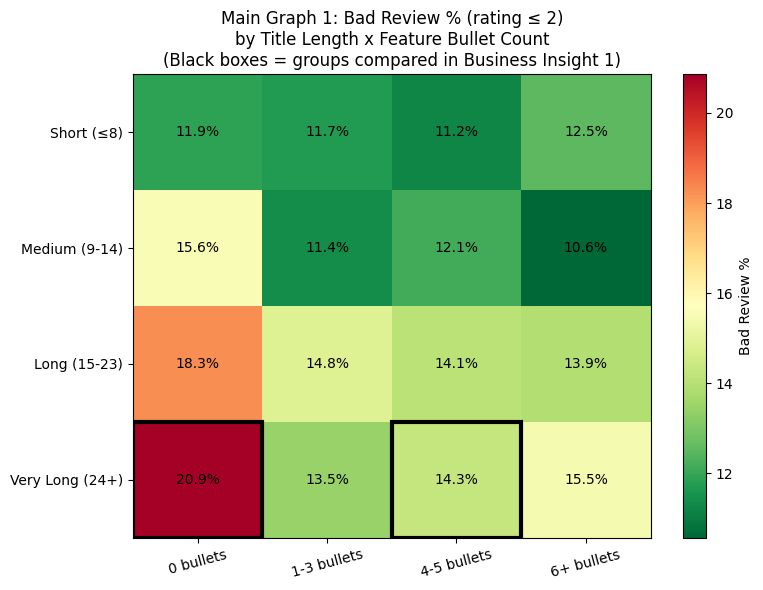

Summary of the groups used in Business Insight 1:


,title_length_group,feature_bullet_group,records,products,mean_review_rating,bad_reviews,bad_review_pct
12,Very Long (24+),0 bullets,671,503,3.991,140,20.864
14,Very Long (24+),4-5 bullets,9848,3584,4.221,1406,14.277


In [51]:
# ============================================================
# 9.1 Main Graph 1: Bad Review % by Title Length x Feature Bullets
# Uses product_text_group_summary from Section 6.5
# Supports Business Insight 1: Product Metadata Group Signal
# ============================================================

title_order = [
    "Short (≤8)",
    "Medium (9-14)",
    "Long (15-23)",
    "Very Long (24+)"
]

feature_order = [
    "0 bullets",
    "1-3 bullets",
    "4-5 bullets",
    "6+ bullets"
]

# Create pivot table for the heatmap
pivot_bad = (
    product_text_group_summary
    .pivot(
        index="title_length_group",
        columns="feature_bullet_group",
        values="bad_review_pct"
    )
    .reindex(
        index=title_order,
        columns=feature_order
    )
)

# Create heatmap
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    pivot_bad.values,
    cmap="RdYlGn_r",
    aspect="auto"
)

# Set axis labels
ax.set_xticks(range(len(feature_order)))
ax.set_xticklabels(feature_order, rotation=15)

ax.set_yticks(range(len(title_order)))
ax.set_yticklabels(title_order)

# Display percentage values inside each cell
for i in range(pivot_bad.shape[0]):
    for j in range(pivot_bad.shape[1]):
        val = pivot_bad.values[i, j]

        if pd.notna(val):
            ax.text(
                j,
                i,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                color="black"
            )

# Highlight the two groups compared in Business Insight 1
for group_name in ["0 bullets", "4-5 bullets"]:

    row = title_order.index("Very Long (24+)")
    col = feature_order.index(group_name)

    ax.add_patch(
        plt.Rectangle(
            (col - 0.5, row - 0.5),
            1,
            1,
            fill=False,
            edgecolor="black",
            linewidth=3
        )
    )

# Set chart title
ax.set_title(
    "Main Graph 1: Bad Review % (rating ≤ 2)\n"
    "by Title Length x Feature Bullet Count\n"
    "(Black boxes = groups compared in Business Insight 1)",
    fontsize=12
)

# Add color bar
fig.colorbar(
    im,
    ax=ax,
    label="Bad Review %"
)

plt.tight_layout()
plt.show()

# Display the numerical results used in Business Insight 1
print("Summary of the groups used in Business Insight 1:")

display(insight1_compare)

กราฟนี้แสดง Heatmap ของสัดส่วน Bad Review % (rating ≤ 2) โดยแบ่งตาม title_length_group (แกนตั้ง) และ feature_bullet_group (แกนนอน) ซึ่งสร้างจากตาราง product_text_group_summary ใน Section 6.5

จากภาพรวมพบว่า กลุ่มที่มี Title ยาว (Long และ Very Long) และไม่มี Feature Bullets (0 bullets) มีค่า Bad Review % ค่อนข้างสูงเมื่อเทียบกับหลายกลุ่ม โดยเฉพาะกลุ่ม Very Long (24+) + 0 bullets ซึ่งมี Bad Review 20.864% ขณะที่กลุ่ม Very Long (24+) + 4–5 bullets มี Bad Review 14.277% โดยทั้งสองกลุ่มถูกไฮไลต์ด้วยกรอบดำในกราฟ

ผลจาก Heatmap สนับสนุน Business Insight 1 โดยแสดงให้เห็นว่ากลุ่ม Very Long Title ที่ไม่มี Feature Bullets มี Bad Review % สูงกว่ากลุ่มเปรียบเทียบที่มี 4–5 Feature Bullets อยู่ 6.587 percentage points

อย่างไรก็ตาม ผลลัพธ์นี้เป็นความแตกต่างเชิงพรรณนาจากข้อมูลที่ศึกษา จึงไม่สามารถสรุปได้ว่า Title ที่ยาวหรือการไม่มี Feature Bullets เป็นสาเหตุโดยตรงของ Bad Review และควรตรวจสอบข้อมูล Review และ Product Metadata เพิ่มเติมก่อนนำผลไปใช้ประกอบการตัดสินใจ

### 9.2 Main Graph ที่ 2

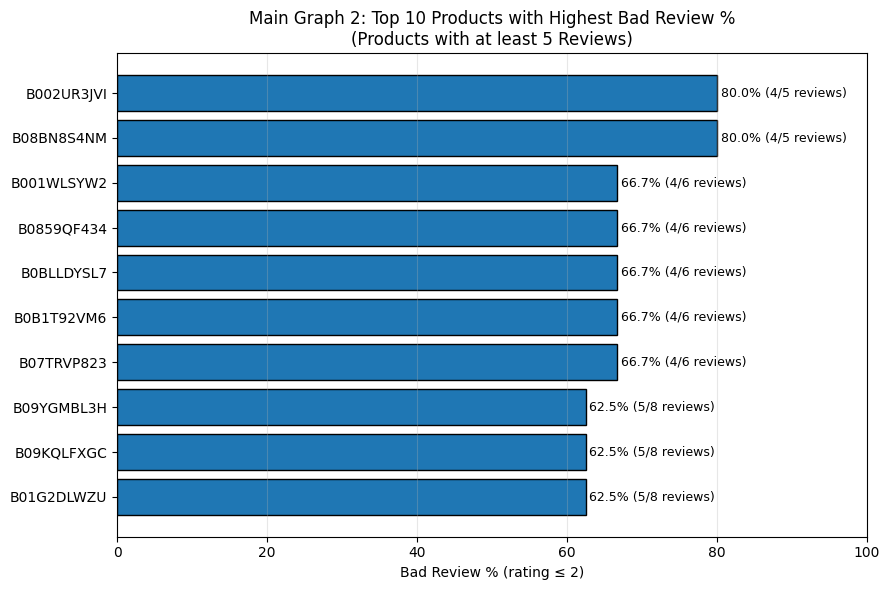

In [52]:
# ============================================================
# 9.2 Main Graph 2: Top Products with Highest Bad Review %
# (Minimum {MIN_REVIEWS} Reviews) — สนับสนุน Business Insight 2:
# Product-level Bad Review Signal
# ============================================================

top_n = 10

# เลือก Top 10 Products จากกลุ่มที่ผ่านเกณฑ์ Minimum Reviews
plot_products = insight2_top_products.head(top_n).copy()

# เรียงจาก Bad Review % ต่ำ → สูง
# เพื่อให้แท่งที่มีค่าสูงสุดอยู่ด้านบนเมื่อใช้ barh
plot_products = plot_products.sort_values("bad_review_pct")

# สร้าง Horizontal Bar Chart
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    plot_products["parent_asin"],
    plot_products["bad_review_pct"],
    edgecolor="black"
)

# แสดง Bad Review % และจำนวน Bad Reviews / Reviews
for bar, (_, row) in zip(bars, plot_products.iterrows()):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{row['bad_review_pct']:.1f}% "
        f"({int(row['bad_reviews'])}/{int(row['reviews'])} reviews)",
        va="center",
        fontsize=9
    )

# ตั้งชื่อแกน
ax.set_xlabel("Bad Review % (rating ≤ 2)")

# ตั้งชื่อกราฟ
ax.set_title(
    f"Main Graph 2: Top {top_n} Products with Highest Bad Review %\n"
    f"(Products with at least {MIN_REVIEWS} Reviews)"
)

# กำหนดแกน X เป็น 0–100%
ax.set_xlim(0, 100)

# เพิ่มเส้น Grid แนวตั้งเพื่อช่วยอ่านค่า
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

กราฟนี้แสดง Horizontal Bar Chart ของ 10 Product ที่มีสัดส่วน Bad Review % สูงที่สุด จากกลุ่ม Product ที่มี Reviews อย่างน้อย MIN_REVIEWS = 5 รายการ โดยแต่ละแท่งกำกับด้วยจำนวน Bad Review เทียบกับจำนวน Reviews ทั้งหมดของ Product นั้น

พบว่า Product ที่มี Bad Review % สูงสุดในกลุ่ม Top 10 ที่ผ่านเกณฑ์นี้ ได้แก่ B002UR3JVI และ B08BN8S4NM ซึ่งมี Bad Review 80% (4 จาก 5 Reviews) และมี Product อื่นในกลุ่ม Top 10 ที่มี Bad Review ประมาณ 60–67%

กราฟนี้สนับสนุน Business Insight 2 ซึ่งใช้ Product-level Bad Review Signal เป็นข้อมูลสำหรับคัดกรอง Product ที่ควรตรวจสอบเพิ่มเติม อย่างไรก็ตาม Product บางรายการมี Reviews เพียง 5–6 รายการ ทำให้สัดส่วน Bad Review % มีความผันผวนได้ง่าย ดังนั้นควรพิจารณาจำนวน Reviews ควบคู่กับ Bad Review % และ Mean Review Rating และไม่ควรใช้ Bad Review % เพียงตัวเดียวในการตัดสิน

### 9.3 ตรวจสอบความถูกต้องและความสอดคล้องของ Graphs

In [53]:
# ============================================================
# 9.3 ตรวจสอบความถูกต้องและความสอดคล้องของ Graphs
# ============================================================

# ----- ตรวจสอบ Main Graph 1 (Insight 1) -----
check_group0 = analysis_df[
    (analysis_df["title_length_group"] == "Very Long (24+)")
    & (analysis_df["feature_bullet_group"] == "0 bullets")
]
check_group45 = analysis_df[
    (analysis_df["title_length_group"] == "Very Long (24+)")
    & (analysis_df["feature_bullet_group"] == "4-5 bullets")
]

print("===== ตรวจสอบ Main Graph 1: Very Long Title Group =====")
print(
    f"0 bullets   -> records={len(check_group0)}, "
    f"products={check_group0['parent_asin'].nunique()}, "
    f"mean_rating={check_group0['rating'].mean():.3f}, "
    f"bad_review%={(check_group0['rating'] <= 2).mean() * 100:.3f}"
)
print(
    f"4-5 bullets -> records={len(check_group45)}, "
    f"products={check_group45['parent_asin'].nunique()}, "
    f"mean_rating={check_group45['rating'].mean():.3f}, "
    f"bad_review%={(check_group45['rating'] <= 2).mean() * 100:.3f}"
)

print("\nเทียบกับค่าใน insight1_compare:")
display(insight1_compare)

# ----- ตรวจสอบ Main Graph 2 (Insight 2) -----
top1 = insight2_top_products.iloc[0]
check_top1 = analysis_df[analysis_df["parent_asin"] == top1["parent_asin"]]

print("\n===== ตรวจสอบ Main Graph 2: Top 1 Product =====")
print(f"parent_asin = {top1['parent_asin']}")
print(f"จำนวน records ใน analysis_df: {len(check_top1)}")
print(f"Bad Review % ที่คำนวณใหม่: {(check_top1['rating'] <= 2).mean() * 100:.3f}%")
print(f"Bad Review % ใน insight2_top_products: {top1['bad_review_pct']:.3f}%")
print(
    "ตรงกันหรือไม่:",
    round((check_top1["rating"] <= 2).mean() * 100, 3) == round(top1["bad_review_pct"], 3)
)

# ----- ตรวจสอบผลรวม records ทั้งหมดใน product_text_group_summary -----
total_check = product_text_group_summary["records"].sum()
print("\nรวม records ใน product_text_group_summary:", total_check)
print("จำนวน records ใน analysis_df:", len(analysis_df))
print("ตรงกันหรือไม่:", total_check == len(analysis_df))


===== ตรวจสอบ Main Graph 1: Very Long Title Group =====
0 bullets   -> records=671, products=503, mean_rating=3.991, bad_review%=20.864
4-5 bullets -> records=9848, products=3584, mean_rating=4.221, bad_review%=14.277

เทียบกับค่าใน insight1_compare:


,title_length_group,feature_bullet_group,records,products,mean_review_rating,bad_reviews,bad_review_pct
12,Very Long (24+),0 bullets,671,503,3.991,140,20.864
14,Very Long (24+),4-5 bullets,9848,3584,4.221,1406,14.277



===== ตรวจสอบ Main Graph 2: Top 1 Product =====
parent_asin = B002UR3JVI
จำนวน records ใน analysis_df: 5
Bad Review % ที่คำนวณใหม่: 80.000%
Bad Review % ใน insight2_top_products: 80.000%
ตรงกันหรือไม่: True

รวม records ใน product_text_group_summary: 50000
จำนวน records ใน analysis_df: 50000
ตรงกันหรือไม่: True




เซลล์นี้ทำการคำนวณตัวเลขที่ใช้ใน Main Graph ทั้ง 2 ใหม่โดยตรงจาก `analysis_df` แล้วเปรียบเทียบกับค่าที่ใช้ใน `insight1_compare` และ `insight2_top_products` เพื่อ ตรวจสอบว่าตัวเลขที่แสดงในกราฟสอดคล้องกับข้อมูลต้นทาง

ผลการตรวจสอบพบว่าตัวเลขของกลุ่มที่ใช้ใน Main Graph 1 ได้แก่ จำนวน records, จำนวน products, Mean Review Rating และ Bad Review % สอดคล้องกับค่าที่ใช้ใน `insight1_compare`

สำหรับ Main Graph 2 ค่า Bad Review % ของ Product ที่อยู่ลำดับแรกสามารถคำนวณใหม่จาก `analysis_df` และตรวจสอบความตรงกันกับค่าใน `insight2_top_products` ได้

นอกจากนี้ ผลรวมจำนวน records ใน `product_text_group_summary` เท่ากับจำนวน records ใน `analysis_df` คือ 50,000 records แสดงว่าการจัดกลุ่มในตารางดังกล่าวครอบคลุมจำนวน records ทั้งหมดของ `analysis_df`

ดังนั้น Main Graph ทั้ง 2 สามารถตรวจสอบย้อนกลับไปยังข้อมูลต้นทางได้ และตัวเลขสำคัญที่ใช้ในการนำเสนอมีความสอดคล้องกับผลการคำนวณจากข้อมูล

## 10. Insight Cards (ปิ๊ก)


ส่วนนี้สรุปผลการวิเคราะห์ให้อยู่ในรูปแบบ Insight Cards เพื่อเชื่อมโยงระหว่าง Evidence จากข้อมูลกับ Business Decision ของ Product Team โดยแต่ละ Insight Card จะประกอบด้วย Insight, Evidence, So What, Action และ Confidence พร้อมระบุ Limitation ที่ควรพิจารณา

Insight Cards มุ่งเน้นการนำผลการวิเคราะห์ไปใช้เป็นข้อมูลสำหรับคัดกรอง Product ที่ควรตรวจสอบเพิ่มเติม โดยไม่ตีความความสัมพันธ์เชิงพรรณนาเป็นความสัมพันธ์เชิงเหตุและผล และคำนึงถึงข้อจำกัดด้านจำนวน Reviews และความผันผวนของ Bad Review % ตามที่พบจาก Reality Check

### 10.1 Insight Card ที่ 1

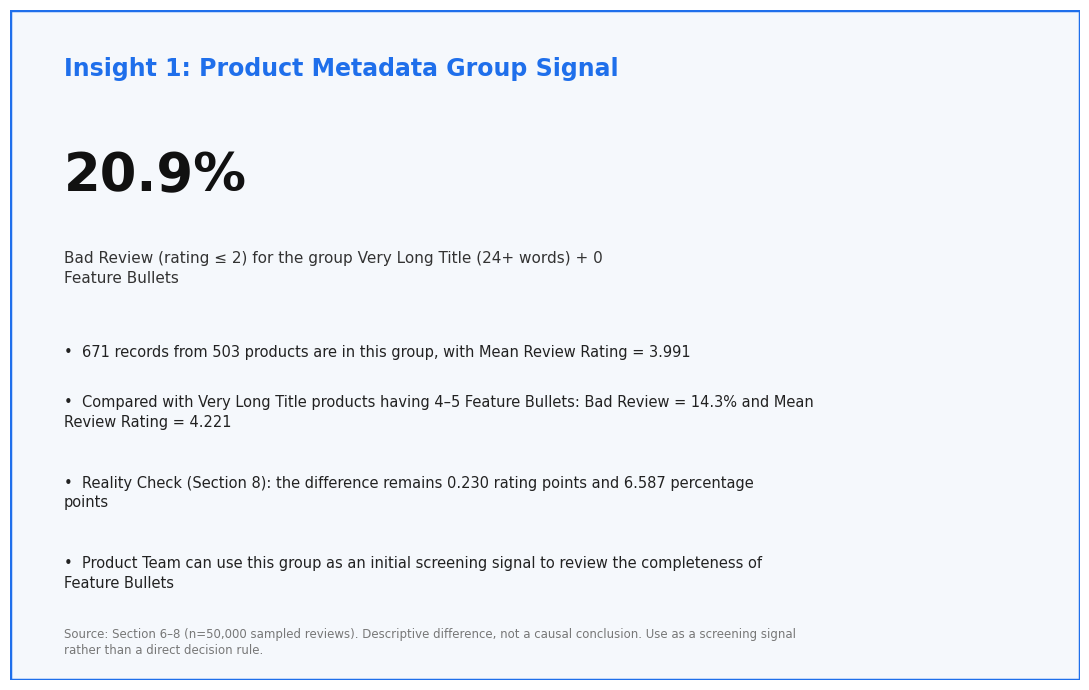

In [54]:
# ============================================================
# 10.1 Insight Card 1
# Business Insight 1: Product Metadata Group Signal
# ============================================================

import matplotlib.pyplot as plt
from textwrap import fill


def draw_insight_card(
    headline,
    stat,
    stat_label,
    bullets,
    footer,
    color="#1F6FEB"
):

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.axis("off")

    # Card background
    ax.add_patch(
        plt.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,
            facecolor="#F5F8FC",
            edgecolor=color,
            linewidth=2.5
        )
    )

    # Headline
    ax.text(
        0.05, 0.93,
        headline,
        fontsize=17,
        fontweight="bold",
        color=color,
        transform=ax.transAxes,
        va="top"
    )

    # Main statistic
    ax.text(
        0.05, 0.79,
        stat,
        fontsize=38,
        fontweight="bold",
        color="#111111",
        transform=ax.transAxes,
        va="top"
    )

    # Statistic description
    ax.text(
        0.05, 0.64,
        fill(stat_label, width=75),
        fontsize=11,
        color="#333333",
        transform=ax.transAxes,
        va="top",
        linespacing=1.4
    )

    # Bullet points
    y = 0.50

    for b in bullets:

        wrapped_text = fill(b, width=95)

        ax.text(
            0.05, y,
            "•  " + wrapped_text,
            fontsize=10.5,
            color="#222222",
            transform=ax.transAxes,
            va="top",
            linespacing=1.4
        )

        n_lines = wrapped_text.count("\n") + 1
        y -= 0.075 + (n_lines - 1) * 0.045

    # Footer
    ax.text(
        0.05, 0.035,
        fill(footer, width=125),
        fontsize=8.5,
        color="#777777",
        transform=ax.transAxes,
        va="bottom",
        linespacing=1.3
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# Calculate differences between the two groups
# ============================================================

rating_diff = (
    group_45["mean_review_rating"]
    - group_0["mean_review_rating"]
)

bad_review_diff = (
    group_0["bad_review_pct"]
    - group_45["bad_review_pct"]
)


# ============================================================
# Create Insight Card 1
# ============================================================

draw_insight_card(

    headline="Insight 1: Product Metadata Group Signal",

    stat=f"{group_0['bad_review_pct']:.1f}%",

    stat_label=(
        "Bad Review (rating ≤ 2) for the group "
        "Very Long Title (24+ words) + 0 Feature Bullets"
    ),

    bullets=[

        (
            f"{int(group_0['records']):,} records from "
            f"{int(group_0['products']):,} products are in this group, "
            f"with Mean Review Rating = "
            f"{group_0['mean_review_rating']:.3f}"
        ),

        (
            f"Compared with Very Long Title products having "
            f"4–5 Feature Bullets: Bad Review = "
            f"{group_45['bad_review_pct']:.1f}% "
            f"and Mean Review Rating = "
            f"{group_45['mean_review_rating']:.3f}"
        ),

        (
            f"Reality Check (Section 8): the difference remains "
            f"{rating_diff:.3f} rating points and "
            f"{bad_review_diff:.3f} percentage points"
        ),

        (
            "Product Team can use this group as an initial screening "
            "signal to review the completeness of Feature Bullets"
        )
    ],

    footer=(
        "Source: Section 6–8 (n=50,000 sampled reviews). "
        "Descriptive difference, not a causal conclusion. "
        "Use as a screening signal rather than a direct decision rule."
    )
)

Insight Card นี้สรุป Business Insight 1: Product Metadata Group Signal ในรูปแบบการ์ดที่อ่านง่าย โดยตัวเลขหลัก (Headline Stat) คือ Bad Review % ของกลุ่ม Very Long Title + 0 Feature Bullets ที่ 20.9%

เนื้อหาในการ์ดสรุปว่า กลุ่มนี้มี 671 records จาก 503 products และมี Mean Review Rating = 3.991 เมื่อเทียบกับกลุ่ม Very Long Title + 4–5 Feature Bullets ซึ่งมี Bad Review = 14.3% และ Mean Review Rating = 4.221

ผล Reality Check ใน Section 8 พบว่าความแตกต่างดังกล่าวยังคงปรากฏในข้อมูลที่ใช้เปรียบเทียบ โดยมีความแตกต่างของ Mean Review Rating 0.230 คะแนน และ Bad Review 6.587 percentage points แม้ขนาดของกลุ่มจะไม่เท่ากัน (671 vs 9,848 records)

การ์ดเสนอให้ Product Team ใช้กลุ่มนี้เป็นจุดเริ่มต้นในการคัดกรองและตรวจสอบความครบถ้วนของ Feature Bullets เพิ่มเติม พร้อมกำกับด้วย Caveat ว่าผลลัพธ์เป็นความแตกต่างเชิงพรรณนา ไม่ใช่ข้อสรุปเชิงเหตุ-ผล

### 10.2 Insight Card ที่ 2

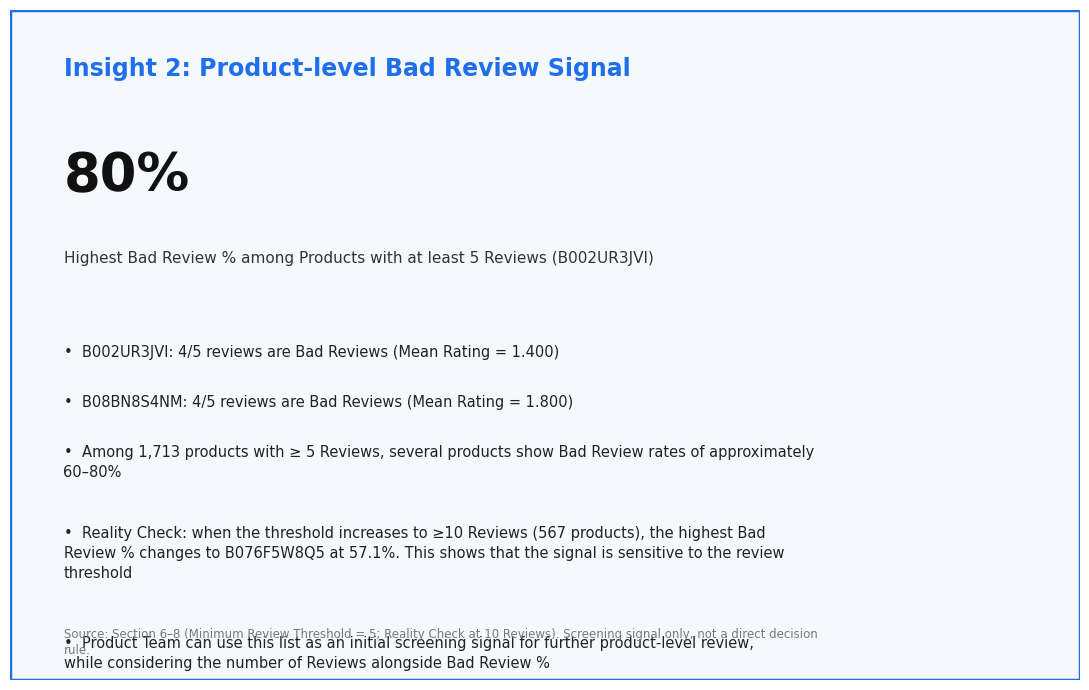

In [55]:
# ============================================================
# 10.2 Insight Card 2
# Business Insight 2: Product-level Bad Review Signal
# ============================================================

top1 = insight2_top_products.iloc[0]
top2 = insight2_top_products.iloc[1]
top1_reality = top_products_10.iloc[0]


draw_insight_card(

    headline="Insight 2: Product-level Bad Review Signal",

    stat=f"{top1['bad_review_pct']:.0f}%",

    stat_label=(
        f"Highest Bad Review % among Products with at least "
        f"{MIN_REVIEWS} Reviews ({top1['parent_asin']})"
    ),

    bullets=[

        (
            f"{top1['parent_asin']}: "
            f"{int(top1['bad_reviews'])}/{int(top1['reviews'])} reviews "
            f"are Bad Reviews "
            f"(Mean Rating = {top1['mean_review_rating']:.3f})"
        ),

        (
            f"{top2['parent_asin']}: "
            f"{int(top2['bad_reviews'])}/{int(top2['reviews'])} reviews "
            f"are Bad Reviews "
            f"(Mean Rating = {top2['mean_review_rating']:.3f})"
        ),

        (
            f"Among {len(product_filtered):,} products with "
            f"≥ {MIN_REVIEWS} Reviews, several products show "
            f"Bad Review rates of approximately 60–80%"
        ),

        (
            f"Reality Check: when the threshold increases to "
            f"≥10 Reviews ({len(product_filtered_10):,} products), "
            f"the highest Bad Review % changes to "
            f"{top1_reality['parent_asin']} at "
            f"{top1_reality['bad_review_pct']:.1f}%. "
            f"This shows that the signal is sensitive to the review threshold"
        ),

        (
            "Product Team can use this list as an initial screening signal "
            "for further product-level review, while considering the "
            "number of Reviews alongside Bad Review %"
        )
    ],

    footer=(
        "Source: Section 6–8 (Minimum Review Threshold = 5; "
        "Reality Check at 10 Reviews). "
        "Screening signal only, not a direct decision rule."
    )
)

Insight Card นี้สรุป Business Insight 2: Product-level Bad Review Signal โดย Headline Stat คือ Bad Review % สูงสุดในกลุ่ม Product ที่มี Reviews อย่างน้อย 5 รายการ ซึ่งในเกณฑ์นี้พบว่า B002UR3JVI มี Bad Review = 80% (4 จาก 5 Reviews)

เนื้อหาในการ์ดยกตัวอย่าง Product ที่มี Bad Review % สูงในกลุ่มที่ผ่านเกณฑ์ดังกล่าว พร้อมแสดงจำนวน Reviews และ Mean Rating เพื่อให้เห็นบริบทของตัวเลข โดย B002UR3JVI มี 4 Bad Reviews จาก 5 Reviews และ B08BN8S4NM มี 4 Bad Reviews จาก 5 Reviews

นอกจากนี้ การ์ดยังอ้างอิงผล Reality Check จาก Section 8 ซึ่งทดสอบเพิ่ม Minimum Review Threshold จาก 5 เป็น 10 Reviews พบว่า Product ที่มี Bad Review % สูงสุดภายใต้เกณฑ์ใหม่เปลี่ยนเป็น B076F5W8Q5 ที่ 57.1% สะท้อนว่า Bad Review % มีความไวต่อ Minimum Review Threshold ที่ใช้ในการคัดกรอง

ดังนั้น Product-level Bad Review % ควรใช้เป็น Screening Signal สำหรับระบุ Product ที่ควรตรวจสอบเพิ่มเติม ไม่ควรใช้เป็นเกณฑ์ตัดสินโดยตรงเพียงตัวเดียว

Recommendation คือ Product Team สามารถใช้ลิสต์นี้เป็นจุดเริ่มต้นในการตรวจสอบ Product รายตัว โดยพิจารณา Bad Review %, จำนวน Reviews และ Mean Review Rating ประกอบกัน

## 11. Part 2 Final Review (ทุกคน)

## 11. Part 2 Final Review

ส่วนนี้เป็นการตรวจสอบความถูกต้องและความพร้อมของ Notebook ก่อนส่งงาน โดยตรวจสอบตั้งแต่การทำงานของ Notebook, Data และ Evidence, Business Story, Graphs และ Insight Cards ไปจนถึงความพร้อมสำหรับการนำเสนอ

### 11.1 ตรวจสอบการทำงานของ Notebook ตั้งแต่ต้นจนจบ

- ตรวจสอบว่า Notebook สามารถ Run ตั้งแต่ต้นจนจบตามลำดับของ Section ได้
- ตรวจสอบว่าไม่มี Error หรือ Missing Variable ที่เกิดจากการข้าม Cell
- ตรวจสอบว่า Dataset และ DataFrame ที่ใช้ในแต่ละ Section ถูกสร้างและเรียกใช้งานอย่างถูกต้อง
- ตรวจสอบว่า Output สำคัญของแต่ละ Section แสดงผลครบถ้วน
- ตรวจสอบว่า Code และ Markdown อธิบายขั้นตอนการวิเคราะห์สอดคล้องกัน

### 11.2 ตรวจสอบ Data และ Evidence

- ตรวจสอบจำนวน Records ที่ใช้ในการวิเคราะห์ให้ตรงกันในแต่ละ Section
- ตรวจสอบว่าเกณฑ์ Bad Review คือ rating ≤ 2 และใช้เกณฑ์เดียวกันตลอดการวิเคราะห์
- ตรวจสอบว่า Product ID ใช้ `parent_asin` อย่างสอดคล้องกัน
- ตรวจสอบว่าตัวเลขสำคัญใน Tables, Graphs และ Insight Cards ตรงกับผลการคำนวณจาก Data
- ตรวจสอบว่า Business Insights สามารถย้อนกลับไปตรวจสอบกับข้อมูลต้นทางได้
- ตรวจสอบว่าไม่มีการตีความผลเชิงพรรณนาเป็นความสัมพันธ์เชิงเหตุและผล

### 11.3 ตรวจสอบ Business Story

ตรวจสอบว่า Business Story มีลำดับที่ชัดเจน:

**Business Question → Data → Analysis → Evidence → Insight → Recommendation → Limitation**

โดย Business Story ต้องตอบให้ได้ว่า

- Product Team ต้องการตัดสินใจเรื่องอะไร
- ใช้ข้อมูลอะไรในการตอบคำถาม
- ใช้เกณฑ์ใดในการระบุ Bad Review
- ผลการวิเคราะห์พบอะไร
- Evidence ใดสนับสนุน Business Insight
- Product Team สามารถนำ Insight ไปใช้เป็นข้อมูลสำหรับการตรวจสอบเพิ่มเติมอย่างไร
- ข้อจำกัดของผลการวิเคราะห์มีอะไรบ้าง

### 11.4 ตรวจสอบ Graphs และ Insight Cards

- ตรวจสอบว่า Main Graph 1 แสดง Bad Review % ตาม Title Length และ Feature Bullet Group ได้ถูกต้อง
- ตรวจสอบว่า Main Graph 2 แสดง Product-level Bad Review Signal ตาม Minimum Review Threshold ได้ถูกต้อง
- ตรวจสอบว่าตัวเลขใน Graphs ตรงกับ Tables และผลการคำนวณ
- ตรวจสอบว่า Insight Card 1 สอดคล้องกับ Business Insight 1
- ตรวจสอบว่า Insight Card 2 สอดคล้องกับ Business Insight 2
- ตรวจสอบว่า Insight Cards ระบุ Evidence, Recommendation และ Limitation อย่างชัดเจน
- ตรวจสอบว่าไม่มีการใช้ Graph หรือ Insight Card เพื่อสรุปความสัมพันธ์เชิงเหตุและผลโดยไม่มีหลักฐานรองรับ

### 11.5 เตรียมความพร้อมสำหรับ Presentation

ก่อนนำเสนอ ควรสามารถอธิบายประเด็นสำคัญต่อไปนี้ได้โดยไม่ต้องอ่านจาก Notebook:

1. Business Question คืออะไร
2. Bad Review ถูกกำหนดอย่างไร
3. ทำไมจึงใช้ Product-level Analysis
4. ทำไมจึงกำหนด Minimum Review Threshold = 5
5. Business Insight 1 พบอะไรจาก Product Metadata
6. Business Insight 2 พบอะไรจาก Product-level Bad Review Signal
7. Reality Check มีไว้เพื่อตรวจสอบอะไร
8. ทำไมผลลัพธ์จึงไม่ควรถูกตีความเป็น Causal Relationship
9. Product Team สามารถนำ Insight ไปใช้เป็นข้อมูลสำหรับการตรวจสอบเพิ่มเติมอย่างไร
10. Limitation ของการวิเคราะห์มีอะไรบ้าง

**Final Check:** Notebook, Data, Evidence, Graphs, Insight Cards และ Business Story ต้องใช้ตัวเลขและเกณฑ์ที่สอดคล้องกันก่อนส่งงาน

# Part 3: Data Collection Robot + External Business Insight



In [56]:
import requests
import pandas as pd

url = "https://api.stackexchange.com/2.3/questions"

params = {
    "site": "music",
    "pagesize": 10,
    "order": "desc",
    "sort": "creation",
    "filter": "withbody"
}

response = requests.get(url, params=params)
data = response.json()

print("Status Code:", response.status_code)
print("จำนวนข้อมูลที่ดึงได้:", len(data.get("items", [])))

data.get("items", [])[:2]

Status Code: 200
จำนวนข้อมูลที่ดึงได้: 10


[{'tags': ['guitar', 'pick-ups', 'construction'],
  'owner': {'account_id': 29120411,
   'reputation': 257,
   'user_id': 105551,
   'user_type': 'registered',
   'profile_image': 'https://lh3.googleusercontent.com/a/AAcHTtdxmRiezVwu7FvsD24abJHlUGJ4Kxwqn9NoC-b7AyIbSw=k-s256',
   'display_name': 'Michael Atkins-Prescott',
   'link': 'https://music.stackexchange.com/users/105551/michael-atkins-prescott'},
  'is_answered': True,
  'view_count': 222,
  'answer_count': 1,
  'score': 2,
  'last_activity_date': 1790778140,
  'creation_date': 1790721876,
  'question_id': 144333,
  'content_license': 'CC BY-SA 4.0',
  'link': 'https://music.stackexchange.com/questions/144333/are-cigar-box-guitars-with-the-neck-and-body-not-flush-a-common-or-viable-design',
  'title': 'Are cigar box guitars with the neck and body not flush a common or viable design?',
  'body': '<p>A few years ago, I built a cigar box guitar. I noticed too late a design flaw, the face of the neck (fretboard? Do you call it that 

## 12. Setup

### 12.1 Import Libraries

ส่วนนี้เป็นการนำเข้าไลบรารี Python ที่จำเป็นสำหรับการเก็บรวบรวมข้อมูล การจัดการข้อมูล และการวิเคราะห์ข้อมูลเบื้องต้น

In [57]:
# ============================================================
# 12.1 Import Libraries
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

print("Libraries imported successfully.")

Libraries imported successfully.


### 12.2 API Configuration

ส่วนนี้เป็นการกำหนดค่าที่ใช้ในการเชื่อมต่อกับ Stack Exchange API เพื่อเก็บข้อมูลคำถามจาก Music Stack Exchange โดยกำหนด API endpoint และพารามิเตอร์ที่ใช้ในการเรียกข้อมูล

In [58]:
# ============================================================
# 12.2 API Configuration
# ============================================================

url = "https://api.stackexchange.com/2.3/questions"

params = {
    "site": "music",
    "pagesize": 100,
    "order": "desc",
    "sort": "creation",
    "filter": "withbody"
}

print("API endpoint:", url)
print("Target site:", params["site"])
print("Page size:", params["pagesize"])
print("Sort order:", params["sort"])

API endpoint: https://api.stackexchange.com/2.3/questions
Target site: music
Page size: 100
Sort order: creation


### 12.3 Data Collection from API

ส่วนนี้เป็นการเก็บข้อมูลคำถามจาก Music Stack Exchange ผ่าน Stack Exchange API โดยข้อมูลที่ได้จาก API จะถูกนำมาใช้เป็นข้อมูลดิบ (Raw Data) สำหรับการวิเคราะห์ในขั้นตอนถัดไป

In [59]:
# ============================================================
# 12.3 Data Collection from API
# ============================================================

all_items = []

for page in range(1, 4):

    params["page"] = page

    response = requests.get(url, params=params)

    print(f"Page {page} - Status Code:", response.status_code)

    page_data = response.json()

    items = page_data.get("items", [])

    print(f"Page {page} - Records collected:", len(items))

    all_items.extend(items)

# Create Raw Dataset
external_raw_df = pd.DataFrame(all_items)

print("\nTotal raw records collected:", len(external_raw_df))

Page 1 - Status Code: 200
Page 1 - Records collected: 100
Page 2 - Status Code: 200
Page 2 - Records collected: 100
Page 3 - Status Code: 200
Page 3 - Records collected: 100

Total raw records collected: 300


### 12.4 Create Raw Dataset

ส่วนนี้เป็นการสร้าง Raw Dataset จากข้อมูลที่เก็บได้จาก Stack Exchange API โดยข้อมูลยังไม่มีการตัดข้อมูลที่ซ้ำ ข้อมูลที่ขาดหาย หรือข้อมูลที่ไม่ถูกต้อง เพื่อเก็บข้อมูลต้นฉบับไว้สำหรับตรวจสอบคุณภาพข้อมูลในขั้นตอนถัดไป

In [60]:
# ============================================================
# 12.4 Create Raw Dataset
# ============================================================

print("Raw Dataset Shape:", external_raw_df.shape)

print("\nColumn Names:")
print(external_raw_df.columns.tolist())

print("\nFirst 5 Records:")
display(external_raw_df.head())

Raw Dataset Shape: (300, 17)

Column Names:
['tags', 'owner', 'is_answered', 'view_count', 'answer_count', 'score', 'last_activity_date', 'creation_date', 'question_id', 'content_license', 'link', 'title', 'body', 'last_edit_date', 'closed_date', 'closed_reason', 'accepted_answer_id']

First 5 Records:


,tags,owner,is_answered,view_count,answer_count,score,last_activity_date,creation_date,question_id,content_license,link,title,body,last_edit_date,closed_date,closed_reason,accepted_answer_id
0,"[guitar, pick-ups, construction]","{'account_id': 29120411, 'reputation': 257, 'u...",True,222,1,2,1790778140,1790721876,144333,CC BY-SA 4.0,https://music.stackexchange.com/questions/1443...,Are cigar box guitars with the neck and body n...,"<p>A few years ago, I built a cigar box guitar...",NaN,NaN,NaN,NaN
1,"[musical-forms, musicology]","{'account_id': 47143477, 'reputation': 9, 'use...",False,120,1,0,1790663910,1790596647,144329,CC BY-SA 4.0,https://music.stackexchange.com/questions/1443...,How can musicians find opportunities to perfor...,<p>I’m a musician looking to perform more ofte...,NaN,NaN,NaN,NaN
2,"[tuning, key-signatures, baroque-period]","{'account_id': 6700343, 'reputation': 145, 'us...",True,743,2,3,1790618838,1790470347,144323,CC BY-SA 4.0,https://music.stackexchange.com/questions/1443...,How many flats and sharps are common in Baroqu...,"<p>I am a guitar novice; but, if I ever get sk...",NaN,NaN,NaN,NaN
3,"[harmony, improvisation, transcription, countr...","{'account_id': 101029, 'reputation': 477, 'use...",False,88,1,0,1790494862,1790382310,144321,CC BY-SA 4.0,https://music.stackexchange.com/questions/1443...,Jimmy Bryant - The Night Rider,<p>I am working on a solo by Jimmy Bryant on a...,1.790424e+09,NaN,NaN,NaN
4,"[notation, sheet-music, time-signatures, key-s...","{'account_id': 14261410, 'reputation': 3007, '...",True,145,2,4,1790774170,1790304668,144318,CC BY-SA 4.0,https://music.stackexchange.com/questions/1443...,Key/time signature change at To Coda,<p>When a forward jump—i.e. a To Coda or secon...,1.790311e+09,NaN,NaN,NaN


#### Interpretation

ผลลัพธ์แสดงว่า Raw Dataset มีจำนวน **300 records และ 17 columns** ซึ่งเป็นข้อมูลคำถามที่เก็บจาก Music Stack Exchange API ก่อนเข้าสู่ขั้นตอน Data Quality Check และ Data Cleaning

ข้อมูลที่เก็บครอบคลุมทั้งข้อมูลข้อความ เช่น `title`, `body` และ `tags` รวมถึงข้อมูลด้าน Engagement เช่น `view_count`, `answer_count` และ `score` ตลอดจนข้อมูลสถานะของคำถาม เช่น `is_answered` และข้อมูลวันที่ต่าง ๆ

ดังนั้น Raw Dataset ชุดนี้มีข้อมูลเพียงพอสำหรับนำไปตรวจสอบคุณภาพข้อมูลและใช้ในการวิเคราะห์ Text Analytics และ Engagement Analysis ในขั้นตอนถัดไป

### 12.5 Initial Data Check

ส่วนนี้เป็นการตรวจสอบข้อมูลเบื้องต้นของ Raw Dataset เช่น จำนวนข้อมูล ชนิดของข้อมูล และค่าที่ขาดหาย เพื่อทำความเข้าใจโครงสร้างข้อมูลก่อนเข้าสู่ขั้นตอนการตรวจสอบคุณภาพและการทำความสะอาดข้อมูล

In [61]:
# ============================================================
# 12.5 Initial Data Check
# ============================================================

# Check the number of records and columns
num_records = len(external_raw_df)
num_columns = len(external_raw_df.columns)

print("Number of Records:", num_records)
print("Number of Columns:", num_columns)

# ============================================================
# Check Dataset Structure
# ============================================================

print("Dataset Information:")
external_raw_df.info()

# Display the first 5 records
display(external_raw_df.head())

# Summary statistics for numerical columns
display(external_raw_df.describe())

Number of Records: 300
Number of Columns: 17
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tags                300 non-null    object 
 1   owner               300 non-null    object 
 2   is_answered         300 non-null    bool   
 3   view_count          300 non-null    int64  
 4   answer_count        300 non-null    int64  
 5   score               300 non-null    int64  
 6   last_activity_date  300 non-null    int64  
 7   creation_date       300 non-null    int64  
 8   question_id         300 non-null    int64  
 9   content_license     269 non-null    object 
 10  link                300 non-null    object 
 11  title               300 non-null    object 
 12  body                300 non-null    object 
 13  last_edit_date      182 non-null    float64
 14  closed_date         31 non-null     floa

,tags,owner,is_answered,view_count,answer_count,score,last_activity_date,creation_date,question_id,content_license,link,title,body,last_edit_date,closed_date,closed_reason,accepted_answer_id
0,"[guitar, pick-ups, construction]","{'account_id': 29120411, 'reputation': 257, 'u...",True,222,1,2,1790778140,1790721876,144333,CC BY-SA 4.0,https://music.stackexchange.com/questions/1443...,Are cigar box guitars with the neck and body n...,"<p>A few years ago, I built a cigar box guitar...",NaN,NaN,NaN,NaN
1,"[musical-forms, musicology]","{'account_id': 47143477, 'reputation': 9, 'use...",False,120,1,0,1790663910,1790596647,144329,CC BY-SA 4.0,https://music.stackexchange.com/questions/1443...,How can musicians find opportunities to perfor...,<p>I’m a musician looking to perform more ofte...,NaN,NaN,NaN,NaN
2,"[tuning, key-signatures, baroque-period]","{'account_id': 6700343, 'reputation': 145, 'us...",True,743,2,3,1790618838,1790470347,144323,CC BY-SA 4.0,https://music.stackexchange.com/questions/1443...,How many flats and sharps are common in Baroqu...,"<p>I am a guitar novice; but, if I ever get sk...",NaN,NaN,NaN,NaN
3,"[harmony, improvisation, transcription, countr...","{'account_id': 101029, 'reputation': 477, 'use...",False,88,1,0,1790494862,1790382310,144321,CC BY-SA 4.0,https://music.stackexchange.com/questions/1443...,Jimmy Bryant - The Night Rider,<p>I am working on a solo by Jimmy Bryant on a...,1.790424e+09,NaN,NaN,NaN
4,"[notation, sheet-music, time-signatures, key-s...","{'account_id': 14261410, 'reputation': 3007, '...",True,145,2,4,1790774170,1790304668,144318,CC BY-SA 4.0,https://music.stackexchange.com/questions/1443...,Key/time signature change at To Coda,<p>When a forward jump—i.e. a To Coda or secon...,1.790311e+09,NaN,NaN,NaN


,view_count,answer_count,score,last_activity_date,creation_date,question_id,last_edit_date,closed_date,accepted_answer_id
count,300.000000,300.000000,300.000000,3.000000e+02,3.000000e+02,300.000000,1.820000e+02,3.100000e+01,127.000000
mean,445.733333,2.006667,3.926667,1.780506e+09,1.779866e+09,143736.966667,1.779876e+09,1.782060e+09,143701.779528
std,428.126769,1.483450,3.443955,6.035629e+06,6.113592e+06,355.518349,5.921666e+06,5.381399e+06,352.387884
min,25.000000,0.000000,-8.000000,1.769367e+09,1.769231e+09,143109.000000,1.769449e+09,1.770604e+09,143124.000000
25%,136.500000,1.000000,1.000000,1.775701e+09,1.774601e+09,143420.000000,1.774539e+09,1.780272e+09,143401.500000
50%,311.500000,2.000000,3.000000,1.780710e+09,1.780127e+09,143754.000000,1.779902e+09,1.781762e+09,143697.000000
75%,623.000000,3.000000,6.000000,1.785853e+09,1.785223e+09,144053.000000,1.784869e+09,1.786022e+09,144001.000000
max,2997.000000,10.000000,20.000000,1.790778e+09,1.790722e+09,144333.000000,1.790424e+09,1.790208e+09,144303.000000


#### Interpretation

ผลการตรวจสอบเบื้องต้นพบว่า Raw Dataset มีจำนวน **300 records และ 17 columns** โดยข้อมูลหลักที่ใช้ในการวิเคราะห์ เช่น `tags`, `title`, `body`, `view_count`, `answer_count`, `score` และ `is_answered` มีข้อมูลครบทั้ง 300 records

อย่างไรก็ตาม พบ Missing Values ในบาง columns ได้แก่ `content_license`, `last_edit_date`, `closed_date`, `closed_reason` และ `accepted_answer_id` ซึ่งส่วนใหญ่เป็นข้อมูลเพิ่มเติมหรือข้อมูลสถานะของคำถาม จึงยังไม่ถือว่าเป็น Invalid Records และจะตรวจสอบเพิ่มเติมในขั้นตอน Data Quality Check

จาก Summary Statistics พบว่า `view_count` มีค่าตั้งแต่ **25 ถึง 2,997 views** โดยมีค่าเฉลี่ยประมาณ **445.73 views** ขณะที่ `answer_count` มีค่าตั้งแต่ **0 ถึง 10 answers** และมีค่าเฉลี่ยประมาณ **2.01 answers** ส่วน `score` อยู่ระหว่าง **-8 ถึง 20** โดยมีค่าเฉลี่ยประมาณ **3.93**

โดยรวม ข้อมูลมีทั้ง Text Data, Engagement Data และ Question Status Data ซึ่งเหมาะสำหรับนำไปตรวจสอบคุณภาพข้อมูลและวิเคราะห์ Text Analytics และ Engagement Analysis ในขั้นตอนถัดไป

## 13. Data Quality Check and Cleaning
ส่วนนี้เป็นการตรวจสอบและทำความสะอาดข้อมูลที่เก็บรวบรวมจาก Stack Exchange API เพื่อประเมินคุณภาพของข้อมูลก่อนนำไปใช้ในการวิเคราะห์ โดยตรวจสอบโครงสร้างข้อมูล Missing Values ข้อมูลซ้ำ และทำความสะอาดข้อความ จากนั้นจึงสร้าง Final Dataset สำหรับการวิเคราะห์ในขั้นตอนถัดไป

### 13.1 Data Structure Check

ส่วนนี้เป็นการตรวจสอบโครงสร้างของ Raw Dataset เพื่อดูจำนวน Records จำนวน Columns ชื่อคอลัมน์ และชนิดข้อมูลเบื้องต้นของแต่ละคอลัมน์ เพื่อยืนยันว่าข้อมูลที่เก็บจาก Stack Exchange API มีโครงสร้างเหมาะสมสำหรับการตรวจสอบคุณภาพข้อมูลในขั้นตอนถัดไป

In [62]:
print("Dataset Shape:")
print(external_raw_df.shape)

print("\nColumn Names:")
print(external_raw_df.columns.tolist())

print("\nDataset Information:")
external_raw_df.info()

Dataset Shape:
(300, 17)

Column Names:
['tags', 'owner', 'is_answered', 'view_count', 'answer_count', 'score', 'last_activity_date', 'creation_date', 'question_id', 'content_license', 'link', 'title', 'body', 'last_edit_date', 'closed_date', 'closed_reason', 'accepted_answer_id']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tags                300 non-null    object 
 1   owner               300 non-null    object 
 2   is_answered         300 non-null    bool   
 3   view_count          300 non-null    int64  
 4   answer_count        300 non-null    int64  
 5   score               300 non-null    int64  
 6   last_activity_date  300 non-null    int64  
 7   creation_date       300 non-null    int64  
 8   question_id         300 non-null    int64  
 9   content_license     269 non-null    object 
 10

#### Interpretation

จากการตรวจสอบโครงสร้างของ Raw Dataset พบว่ามีข้อมูลทั้งหมด 300 records และ 17 columns ซึ่งเป็นข้อมูลคำถามที่เก็บจาก Music Stack Exchange ผ่าน Stack Exchange API

คอลัมน์ที่สำคัญสำหรับการวิเคราะห์ข้อความ ได้แก่ `title` และ `body` ซึ่งมีข้อมูลครบทั้ง 300 records นอกจากนี้ `question_id`, `score`, `view_count` และ `answer_count` ก็มีข้อมูลครบเช่นกัน

พบว่า `content_license`, `last_edit_date`, `closed_date`, `closed_reason` และ `accepted_answer_id` มี Missing Values ในบาง records ซึ่งจะถูกตรวจสอบเพิ่มเติมในขั้นตอน Missing Values Check

ดังนั้น Raw Dataset มีโครงสร้างที่สามารถนำไปตรวจสอบคุณภาพข้อมูลและทำความสะอาดในขั้นตอนถัดไปได้

### 13.2 Missing Values Check

ส่วนนี้เป็นการตรวจสอบค่าที่ขาดหาย (Missing Values) ในแต่ละคอลัมน์ของ Raw Dataset เพื่อประเมินคุณภาพข้อมูล และพิจารณาว่าคอลัมน์ใดมี Missing Values ที่อาจส่งผลต่อการวิเคราะห์

In [63]:
missing_summary = pd.DataFrame({
    "Missing Count": external_raw_df.isna().sum(),
    "Missing Percentage": (
        external_raw_df.isna().mean() * 100
    )
})

display(missing_summary)

,Missing Count,Missing Percentage
tags,0,0.000000
owner,0,0.000000
is_answered,0,0.000000
view_count,0,0.000000
answer_count,0,0.000000
score,0,0.000000
last_activity_date,0,0.000000
creation_date,0,0.000000
question_id,0,0.000000
content_license,31,10.333333


#### Interpretation

จากการตรวจสอบ Missing Values พบว่า `title`, `body`, `tags`, `question_id`, `score`, `view_count` และ `answer_count` ไม่มีค่าที่ขาดหาย โดยเฉพาะ `title` และ `body` ซึ่งเป็นข้อมูลหลักสำหรับการวิเคราะห์ข้อความ มีข้อมูลครบทั้ง 300 records

พบ Missing Values ใน `content_license` จำนวน 31 records (10.33%), `last_edit_date` จำนวน 118 records (39.33%), `closed_date` และ `closed_reason` จำนวน 269 records (89.67%) และ `accepted_answer_id` จำนวน 173 records (57.67%)

อย่างไรก็ตาม Missing Values ในบางคอลัมน์สามารถเกิดขึ้นได้ตามลักษณะของข้อมูล เช่น คำถามที่ยังไม่เคยแก้ไขอาจไม่มี `last_edit_date` คำถามที่ยังไม่ถูกปิดจะไม่มี `closed_date` และ `closed_reason` และคำถามที่ยังไม่มี Accepted Answer จะไม่มี `accepted_answer_id`

ดังนั้น ในขั้นตอนนี้จะยังไม่ลบ Records ที่มี Missing Values ทั้งหมด เนื่องจากข้อมูลหลักที่ใช้สำหรับการวิเคราะห์ข้อความ ได้แก่ `title`, `body` และ `tags` มีข้อมูลครบถ้วน และ Missing Values ในบางคอลัมน์เป็นข้อมูลที่เกิดขึ้นตามธรรมชาติของสถานะคำถาม

### 13.3 Duplicate Records Check

ส่วนนี้เป็นการตรวจสอบข้อมูลที่ซ้ำกัน (Duplicate Records) ใน Raw Dataset โดยใช้ `question_id` ซึ่งเป็นรหัสเฉพาะของแต่ละคำถาม และตรวจสอบเพิ่มเติมจาก `title` และ `body` เพื่อประเมินว่ามีคำถามเดียวกันถูกเก็บซ้ำหรือไม่

In [64]:
duplicate_question_id = external_raw_df["question_id"].duplicated().sum()

print("Duplicate question_id:", duplicate_question_id)

duplicate_content = external_raw_df[
    external_raw_df.duplicated(
        subset=["title", "body"],
        keep=False
    )
]

print("Duplicate title + body records:", len(duplicate_content))

Duplicate question_id: 0
Duplicate title + body records: 0


#### Interpretation

จากการตรวจสอบข้อมูลซ้ำ พบว่า `question_id` ซึ่งเป็นรหัสเฉพาะของแต่ละคำถาม ไม่มีข้อมูลซ้ำ โดยพบ Duplicate จำนวน 0 records

นอกจากนี้ เมื่อตรวจสอบข้อมูลที่มีทั้ง `title` และ `body` เหมือนกัน พบว่าไม่มีข้อมูลซ้ำเช่นกัน โดยพบ Duplicate จำนวน 0 records

ดังนั้น จากการตรวจสอบในขั้นตอนนี้ ไม่พบข้อมูลคำถามซ้ำใน Raw Dataset จำนวน 300 records และข้อมูลสามารถนำไปเข้าสู่ขั้นตอนการทำความสะอาดข้อความ (Text Cleaning) ได้

### 13.4 Text Cleaning

ส่วนนี้เป็นการทำความสะอาดข้อมูลข้อความในคอลัมน์ `title` และ `body` โดยลบ HTML tags อักขระที่ไม่จำเป็น และปรับช่องว่างให้เป็นรูปแบบที่เหมาะสมสำหรับการวิเคราะห์ข้อความในขั้นตอนถัดไป

In [65]:
import re
from html import unescape

def clean_text(text):
    text = str(text)

    # Convert HTML entities to normal characters
    text = unescape(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Replace multiple whitespace with a single space
    text = re.sub(r"\s+", " ", text)

    return text.strip()

external_raw_df["clean_title"] = external_raw_df["title"].apply(clean_text)
external_raw_df["clean_body"] = external_raw_df["body"].apply(clean_text)

print("Text cleaning completed.")

display(
    external_raw_df[
        ["title", "clean_title", "body", "clean_body"]
    ].head(5)
)

Text cleaning completed.


,title,clean_title,body,clean_body
0,Are cigar box guitars with the neck and body n...,Are cigar box guitars with the neck and body n...,"<p>A few years ago, I built a cigar box guitar...","A few years ago, I built a cigar box guitar. I..."
1,How can musicians find opportunities to perfor...,How can musicians find opportunities to perfor...,<p>I’m a musician looking to perform more ofte...,I’m a musician looking to perform more often a...
2,How many flats and sharps are common in Baroqu...,How many flats and sharps are common in Baroqu...,"<p>I am a guitar novice; but, if I ever get sk...","I am a guitar novice; but, if I ever get skill..."
3,Jimmy Bryant - The Night Rider,Jimmy Bryant - The Night Rider,<p>I am working on a solo by Jimmy Bryant on a...,I am working on a solo by Jimmy Bryant on a so...
4,Key/time signature change at To Coda,Key/time signature change at To Coda,<p>When a forward jump—i.e. a To Coda or secon...,When a forward jump—i.e. a To Coda or second-t...


#### Interpretation

จากการตรวจสอบผลลัพธ์หลังการทำความสะอาดข้อความ พบว่า HTML tags ที่อยู่ใน `body` เช่น `<p>` ถูกลบออก และข้อความถูกจัดรูปแบบให้เป็นข้อความธรรมดาที่เหมาะสมสำหรับการวิเคราะห์ Text Analytics

นอกจากนี้ URL และช่องว่างที่ไม่จำเป็นถูกลบหรือปรับให้อยู่ในรูปแบบที่เหมาะสม โดยยังคงเนื้อหาหลักของคำถามไว้ และสร้างคอลัมน์ใหม่เป็น `clean_title` และ `clean_body` เพื่อเก็บข้อความที่ผ่านการทำความสะอาด

การเก็บข้อมูลเดิมไว้ใน `title` และ `body` ช่วยให้สามารถตรวจสอบและเปรียบเทียบข้อมูลก่อนและหลังการทำความสะอาดได้ ดังนั้นข้อมูลข้อความสามารถนำไปใช้ในขั้นตอนการสร้าง Final Dataset และการวิเคราะห์ต่อไปได้

### 13.5 Create Final Dataset

ส่วนนี้เป็นการสร้าง Final Dataset จากข้อมูลที่ผ่านการตรวจสอบโครงสร้าง Missing Values Duplicate Records และ Text Cleaning แล้ว โดยเลือกเฉพาะคอลัมน์ที่จำเป็นสำหรับการวิเคราะห์ และตรวจสอบจำนวน Records ที่สามารถนำไปใช้ในการวิเคราะห์ได้

In [66]:
final_df = external_raw_df[
    [
        "question_id",
        "title",
        "body",
        "clean_title",
        "clean_body",
        "tags",
        "score",
        "view_count",
        "answer_count",
        "is_answered",
        "creation_date",
        "link"
    ]
].copy()

print("Final Dataset Shape:", final_df.shape)

print("\nFinal Dataset Columns:")
print(final_df.columns.tolist())

print("\nFirst 5 Records:")
display(final_df.head())


Final Dataset Shape: (300, 12)

Final Dataset Columns:
['question_id', 'title', 'body', 'clean_title', 'clean_body', 'tags', 'score', 'view_count', 'answer_count', 'is_answered', 'creation_date', 'link']

First 5 Records:


,question_id,title,body,clean_title,clean_body,tags,score,view_count,answer_count,is_answered,creation_date,link
0,144333,Are cigar box guitars with the neck and body n...,"<p>A few years ago, I built a cigar box guitar...",Are cigar box guitars with the neck and body n...,"A few years ago, I built a cigar box guitar. I...","[guitar, pick-ups, construction]",2,222,1,True,1790721876,https://music.stackexchange.com/questions/1443...
1,144329,How can musicians find opportunities to perfor...,<p>I’m a musician looking to perform more ofte...,How can musicians find opportunities to perfor...,I’m a musician looking to perform more often a...,"[musical-forms, musicology]",0,120,1,False,1790596647,https://music.stackexchange.com/questions/1443...
2,144323,How many flats and sharps are common in Baroqu...,"<p>I am a guitar novice; but, if I ever get sk...",How many flats and sharps are common in Baroqu...,"I am a guitar novice; but, if I ever get skill...","[tuning, key-signatures, baroque-period]",3,743,2,True,1790470347,https://music.stackexchange.com/questions/1443...
3,144321,Jimmy Bryant - The Night Rider,<p>I am working on a solo by Jimmy Bryant on a...,Jimmy Bryant - The Night Rider,I am working on a solo by Jimmy Bryant on a so...,"[harmony, improvisation, transcription, countr...",0,88,1,False,1790382310,https://music.stackexchange.com/questions/1443...
4,144318,Key/time signature change at To Coda,<p>When a forward jump—i.e. a To Coda or secon...,Key/time signature change at To Coda,When a forward jump—i.e. a To Coda or second-t...,"[notation, sheet-music, time-signatures, key-s...",4,145,2,True,1790304668,https://music.stackexchange.com/questions/1443...


In [67]:
valid_records = final_df[
    final_df["clean_title"].str.strip().ne("") &
    final_df["clean_body"].str.strip().ne("")
].copy()

print("Valid Analytical Records:", len(valid_records))

Valid Analytical Records: 300


#### Interpretation

จากการสร้าง Final Dataset พบว่ามีข้อมูลทั้งหมด 300 records และ 12 columns โดยเลือกเฉพาะตัวแปรที่จำเป็นสำหรับการวิเคราะห์ ได้แก่ข้อมูลระบุคำถาม ข้อมูลข้อความ ข้อมูล Tags และตัวแปรที่เกี่ยวข้องกับการตอบรับของคำถาม เช่น `score`, `view_count`, `answer_count` และ `is_answered`

หลังจากตรวจสอบ `clean_title` และ `clean_body` พบว่า Valid Analytical Records มีจำนวน 300 records หรือคิดเป็น 100% ของ Final Dataset

ดังนั้นข้อมูลทั้งหมด 300 records สามารถนำไปใช้ในการวิเคราะห์ได้ และผ่านเกณฑ์ขั้นต่ำ 200 Valid Analytical Records ที่กำหนดในโครงงาน

## 14. Text Analytics เอมี่


### 14.1 Define Decision Support Question

**Decision Support Question:**

หัวข้อด้านดนตรีประเภทใดถูกถามบ่อยและได้รับความสนใจสูงใน Music Stack Exchange และหัวข้อใดมีคำถามจำนวนมากหรือมี Engagement สูง แต่มี Answered Rate ต่ำ?

- **User:** Content / Knowledge Team
- **Decision:** ควรให้ความสำคัญกับหัวข้อใดในการจัดทำ FAQ, Knowledge Content หรือแหล่งข้อมูลช่วยเหลือผู้ใช้
- **Data:** `title`, `body`, `tags`, `score`, `view_count`, `answer_count`, `is_answered`
- **Techniques:** Word Frequency, N-gram, Tag Analysis และ Engagement Analysis
- **Evidence:** จำนวนคำถาม, Average Views, Average Score, Average Answers และ Answered Rate


In [68]:
print(final_df.columns.tolist())

['question_id', 'title', 'body', 'clean_title', 'clean_body', 'tags', 'score', 'view_count', 'answer_count', 'is_answered', 'creation_date', 'link']


### 14.2 Text Preprocessing for Analysis

ขั้นตอนนี้เป็นการเตรียมข้อมูลข้อความสำหรับใช้ในการวิเคราะห์ Text Analytics โดยนำ `clean_title` และ `clean_body` ที่ผ่านการทำความสะอาดจากขั้นตอน Data Cleaning มารวมกันเป็นคอลัมน์ `analysis_text`

การรวม Title และ Body ช่วยให้สามารถวิเคราะห์เนื้อหาของคำถามได้ครบถ้วนมากขึ้น และเหมาะสำหรับการวิเคราะห์ Word Frequency และ N-gram ในขั้นตอนถัดไป

In [69]:
# ============================================================
# 14.2 Text Preprocessing for Analysis
# ============================================================

analysis_df = final_df.copy()

analysis_df["analysis_text"] = (
    analysis_df["clean_title"].fillna("") + " " +
    analysis_df["clean_body"].fillna("")
).str.strip()

print("จำนวน records สำหรับวิเคราะห์ =", len(analysis_df))

display(
    analysis_df[
        ["question_id", "clean_title", "clean_body", "analysis_text"]
    ].head()
)

จำนวน records สำหรับวิเคราะห์ = 300


,question_id,clean_title,clean_body,analysis_text
0,144333,Are cigar box guitars with the neck and body n...,"A few years ago, I built a cigar box guitar. I...",Are cigar box guitars with the neck and body n...
1,144329,How can musicians find opportunities to perfor...,I’m a musician looking to perform more often a...,How can musicians find opportunities to perfor...
2,144323,How many flats and sharps are common in Baroqu...,"I am a guitar novice; but, if I ever get skill...",How many flats and sharps are common in Baroqu...
3,144321,Jimmy Bryant - The Night Rider,I am working on a solo by Jimmy Bryant on a so...,Jimmy Bryant - The Night Rider I am working on...
4,144318,Key/time signature change at To Coda,When a forward jump—i.e. a To Coda or second-t...,Key/time signature change at To Coda When a fo...


#### Interpretation

จากขั้นตอนการเตรียมข้อมูล พบว่าสามารถสร้างคอลัมน์ `analysis_text` ได้จากการรวม `clean_title` และ `clean_body` ของแต่ละคำถามเข้าด้วยกัน โดยใช้ข้อความที่ผ่านการทำความสะอาดจากขั้นตอนก่อนหน้า และจัดการ Missing Values ด้วยการแทนค่าด้วยข้อความว่าง

ข้อมูลที่ได้มีจำนวน 300 records และสามารถนำไปใช้สำหรับการวิเคราะห์ Text Analytics ในขั้นตอนถัดไป เช่น Word Frequency, N-gram และการวิเคราะห์หัวข้อจากข้อความได้อย่างเหมาะสม โดยยังคงเชื่อมโยงแต่ละข้อความกับ `question_id` เพื่อใช้ประกอบการวิเคราะห์และตรวจสอบผลลัพธ์ต่อไป

### 14.3 Word Frequency Analysis
วิเคราะห์คำที่ปรากฏบ่อยในคำถาม เพื่อค้นหาประเด็นหรือหัวข้อที่ผู้ใช้กล่าวถึงมาก

In [70]:
# ============================================================
# 14.3 Word Frequency Analysis
# ============================================================

from collections import Counter
import re

all_words = []

for text in analysis_df["analysis_text"].dropna():
    words = re.findall(r"\b[a-zA-Z]+\b", text.lower())
    all_words.extend(words)

word_freq = pd.DataFrame(
    Counter(all_words).most_common(30),
    columns=["word", "count"]
)

display(word_freq)

,word,count
0,the,2354
1,i,1276
2,a,1125
3,to,1099
4,in,893
5,and,756
6,of,750
7,is,662
8,it,496
9,that,463


In [71]:
# ============================================================
# Remove Stopwords
# ============================================================

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

filtered_words = [
    word for word in all_words
    if word not in stop_words and len(word) > 2
]

word_freq_clean = pd.DataFrame(
    Counter(filtered_words).most_common(30),
    columns=["word", "count"]
)

display(word_freq_clean)

,word,count
0,notes,195
1,note,179
2,music,164
3,like,156
4,measure,110
5,play,107
6,chord,105
7,time,97
8,does,97
9,just,96


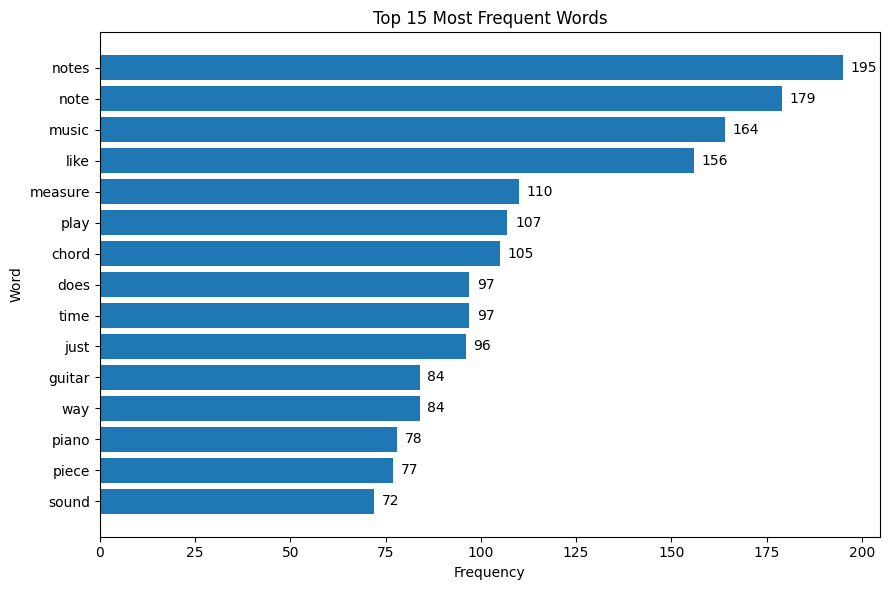

In [72]:
# ============================================================
# Top 15 Word Frequency
# ============================================================

top15_words = word_freq_clean.head(15).sort_values("count")

plt.figure(figsize=(9, 6))

plt.barh(
    top15_words["word"],
    top15_words["count"]
)

plt.title("Top 15 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

for i, value in enumerate(top15_words["count"]):
    plt.text(value + 2, i, str(value), va="center")

plt.tight_layout()
plt.show()

#### Interpretation

จากการวิเคราะห์ Word Frequency หลังจากตัด Stopwords และคำที่มีความยาวน้อยกว่า 3 ตัวอักษร พบว่าคำที่ปรากฏบ่อยส่วนใหญ่เกี่ยวข้องกับองค์ประกอบทางดนตรี การเล่นดนตรี และเครื่องดนตรี เช่น `notes`, `music`, `measure`, `play`, `chord`, `guitar`, `piano` และ `sound`

ผลดังกล่าวสะท้อนว่าประเด็นที่เกี่ยวข้องกับโน้ต ทฤษฎีดนตรี การเล่นดนตรี และเครื่องดนตรีเป็นหัวข้อที่ถูกกล่าวถึงบ่อยในชุดคำถามที่นำมาวิเคราะห์

อย่างไรก็ตาม Word Frequency เป็นการวิเคราะห์คำเดี่ยว จึงยังไม่สามารถแสดงบริบทหรือความสัมพันธ์ระหว่างคำได้อย่างชัดเจน ดังนั้นในขั้นตอนถัดไปจะใช้ N-gram Analysis เพื่อวิเคราะห์คำหรือวลีที่มักปรากฏร่วมกัน และช่วยให้เห็นประเด็นของคำถามได้ชัดเจนมากขึ้น

### 14.4 N-gram / Phrase Analysis
วิเคราะห์คำหรือวลีที่มักปรากฏร่วมกัน เพื่อให้เห็นหัวข้อหรือประเด็นที่มีความหมายชัดเจนมากขึ้น

In [73]:
# ============================================================
# 14.4 N-gram / Phrase Analysis
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    min_df=2
)

X = vectorizer.fit_transform(
    analysis_df["analysis_text"].fillna("")
)

bigram_counts = X.sum(axis=0).A1
bigram_terms = vectorizer.get_feature_names_out()

bigram_freq = pd.DataFrame({
    "phrase": bigram_terms,
    "count": bigram_counts
}).sort_values(
    "count",
    ascending=False
).head(20)

display(bigram_freq)

,phrase,count
585,time signature,18
520,sheet music,14
471,quarter note,14
366,new staff,14
262,key signature,13
633,version 24,11
427,piano reduction,11
506,second measure,10
347,music theory,10
68,blues scale,10


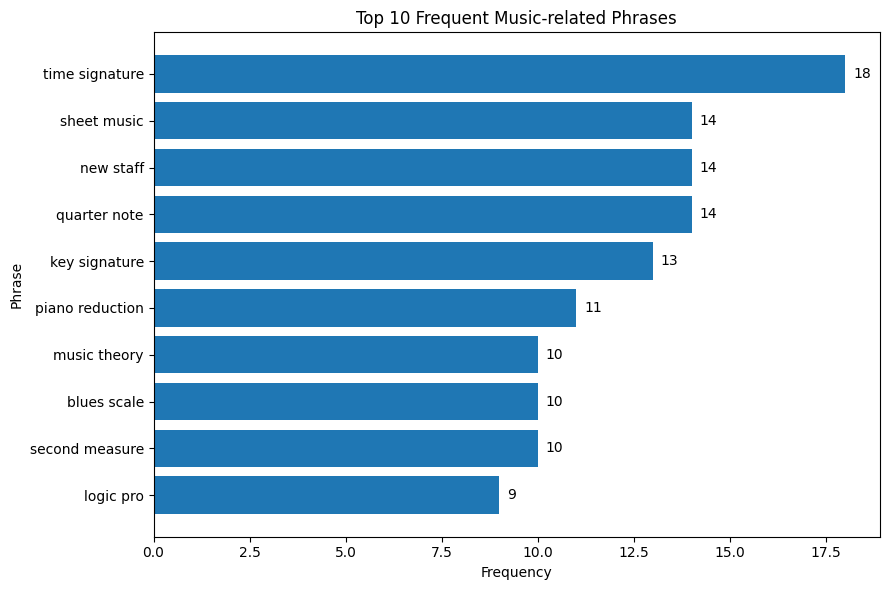

In [74]:
# ============================================================
# Top 10 Meaningful Bigrams
# ============================================================

exclude_phrases = [
    "version 24",
    "larry todd",
    "score new"
]

bigram_plot = (
    bigram_freq[
        ~bigram_freq["phrase"].isin(exclude_phrases)
    ]
    .head(10)
    .sort_values("count")
)

plt.figure(figsize=(9, 6))

plt.barh(
    bigram_plot["phrase"],
    bigram_plot["count"]
)

plt.title("Top 10 Frequent Music-related Phrases")
plt.xlabel("Frequency")
plt.ylabel("Phrase")

for i, value in enumerate(bigram_plot["count"]):
    plt.text(value + 0.2, i, str(value), va="center")

plt.tight_layout()
plt.show()

#### Interpretation

จากการวิเคราะห์ Bigram พบว่า `time signature` เป็นวลีที่พบมากที่สุด จำนวน 18 ครั้ง รองลงมาคือ `sheet music` และ `quarter note` อย่างละ 14 ครั้ง และ `key signature` จำนวน 13 ครั้ง

เมื่อพิจารณาวลีที่ปรากฏร่วมกัน พบว่าวลีที่มีความถี่สูงส่วนใหญ่เกี่ยวข้องกับการอ่านโน้ต จังหวะ และทฤษฎีดนตรี เช่น `time signature`, `quarter note` และ `key signature` ซึ่งสะท้อนว่าคำถามในชุดข้อมูลจำนวนหนึ่งเกี่ยวข้องกับการทำความเข้าใจโครงสร้างและองค์ประกอบพื้นฐานของดนตรี

ดังนั้น ผลจาก N-gram Analysis สามารถใช้เป็นข้อมูลประกอบในการพิจารณาหัวข้อที่ควรให้ความสำคัญ และจะนำไปวิเคราะห์ร่วมกับ Tag Analysis และ Engagement Analysis ในขั้นตอนถัดไป เพื่อพิจารณาทั้งความถี่ของหัวข้อและระดับความสนใจของผู้ใช้งาน

### 14.5 Tag Analysis
วิเคราะห์ Tags ของคำถามเพื่อดูว่าหัวข้อด้านดนตรีประเภทใดมีจำนวนคำถามมาก

In [75]:
# ============================================================
# 14.5 Tag Analysis
# ============================================================

from collections import Counter

all_tags = []

for tags in analysis_df["tags"]:
    if isinstance(tags, list):
        all_tags.extend(tags)

tag_freq = pd.DataFrame(
    Counter(all_tags).most_common(20),
    columns=["tag", "count"]
)

display(tag_freq)

,tag,count
0,notation,53
1,theory,35
2,piano,29
3,lilypond,28
4,technique,21
5,rhythm,18
6,engraving,16
7,guitar,15
8,harmony,13
9,time-signatures,13


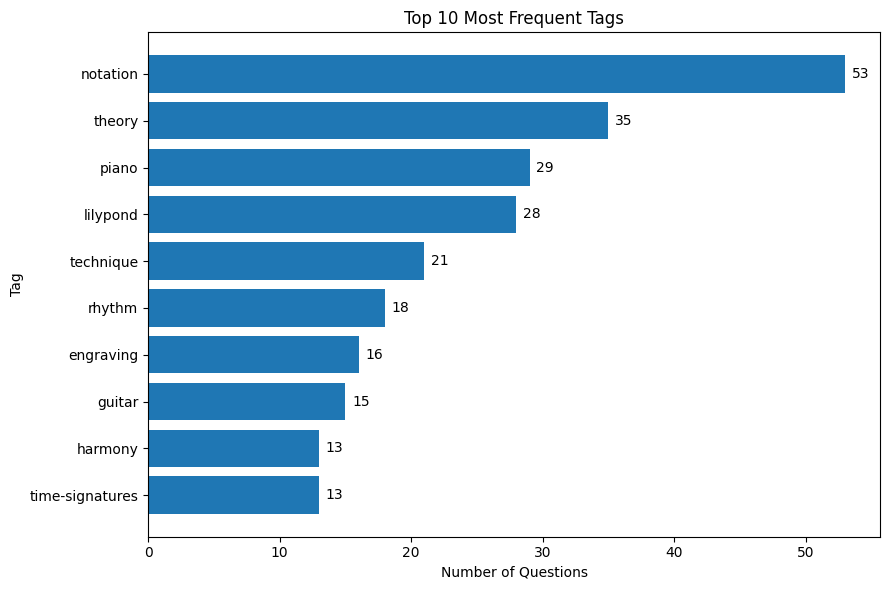

In [76]:
# ============================================================
# Top 10 Tags
# ============================================================

top10_tags = tag_freq.head(10).sort_values("count")

plt.figure(figsize=(9, 6))

plt.barh(
    top10_tags["tag"],
    top10_tags["count"]
)

plt.title("Top 10 Most Frequent Tags")
plt.xlabel("Number of Questions")
plt.ylabel("Tag")

for i, value in enumerate(top10_tags["count"]):
    plt.text(value + 0.5, i, str(value), va="center")

plt.tight_layout()
plt.show()


#### Interpretation

จากการวิเคราะห์ Tag พบว่า `notation` เป็นหัวข้อที่มีจำนวนคำถามสูงที่สุด จำนวน 53 คำถาม รองลงมาคือ `theory` จำนวน 35 คำถาม, `piano` จำนวน 29 คำถาม และ `lilypond` จำนวน 28 คำถาม

เมื่อพิจารณาร่วมกับผลจาก Word Frequency และ Bigram Analysis พบว่าประเด็นที่เกี่ยวข้องกับการอ่านและเขียนโน้ต ทฤษฎีดนตรี และโครงสร้างทางดนตรีปรากฏอย่างต่อเนื่องในหลายวิธีการวิเคราะห์

ผลดังกล่าวสะท้อนว่า `notation` และ `theory` เป็นกลุ่มหัวข้อที่มีจำนวนคำถามสูงในชุดข้อมูล และจึงเป็นหัวข้อที่ควรนำไปตรวจสอบเพิ่มเติมในด้าน Engagement Analysis เพื่อพิจารณาว่าหัวข้อเหล่านี้มีระดับความสนใจสูงหรือมี Answered Rate ต่ำหรือไม่

### 14.6 Engagement Analysis
วิเคราะห์ Score, View Count, Answer Count และ Is Answered เพื่อศึกษาระดับ Engagement ของคำถามในแต่ละหัวข้อ


In [77]:
# ============================================================
# 14.6 Engagement Analysis
# ============================================================

tag_rows = []

for _, row in analysis_df.iterrows():
    if isinstance(row["tags"], list):
        for tag in row["tags"]:
            tag_rows.append({
                "tag": tag,
                "question_id": row["question_id"],
                "view_count": row["view_count"],
                "score": row["score"],
                "answer_count": row["answer_count"],
                "is_answered": row["is_answered"]
            })

tag_engagement = pd.DataFrame(tag_rows)

tag_summary = (
    tag_engagement
    .groupby("tag")
    .agg(
        question_count=("question_id", "nunique"),
        avg_views=("view_count", "mean"),
        avg_score=("score", "mean"),
        avg_answers=("answer_count", "mean"),
        answered_rate=("is_answered", "mean")
    )
    .reset_index()
)

tag_summary["answered_rate_pct"] = (
    tag_summary["answered_rate"] * 100
)

# ใช้เฉพาะ tag ที่มีอย่างน้อย 8 คำถาม
tag_summary_filtered = (
    tag_summary[
        tag_summary["question_count"] >= 8
    ]
    .sort_values(
        "avg_views",
        ascending=False
    )
)

display(tag_summary_filtered)

,tag,question_count,avg_views,avg_score,avg_answers,answered_rate,answered_rate_pct
184,sheet-music,9,725.111111,4.666667,2.777778,1.000000,100.000000
172,rhythm,18,608.055556,4.888889,2.333333,0.944444,94.444444
141,orchestra,8,573.000000,3.000000,2.000000,0.875000,87.500000
157,piano,29,528.689655,4.137931,2.206897,0.931034,93.103448
68,engraving,16,469.250000,5.375000,2.062500,0.875000,87.500000
138,notation,53,460.886792,5.490566,2.132075,0.924528,92.452830
40,classical-music,8,454.250000,4.500000,2.000000,1.000000,100.000000
210,theory,35,449.171429,3.942857,2.257143,0.942857,94.285714
205,technique,21,445.190476,4.047619,1.904762,0.952381,95.238095
36,chords,9,432.333333,4.111111,2.888889,1.000000,100.000000


In [78]:
# ============================================================
# Topics with High Interest but Lower Answered Rate
# ============================================================

priority_topics = tag_summary_filtered.copy()

priority_topics = priority_topics.sort_values(
    ["answered_rate_pct", "avg_views"],
    ascending=[True, False]
)

display(
    priority_topics[
        [
            "tag",
            "question_count",
            "avg_views",
            "avg_answers",
            "answered_rate_pct"
        ]
    ].head(10)
)

,tag,question_count,avg_views,avg_answers,answered_rate_pct
59,dynamics,8,206.250000,1.625000,62.500000
86,guitar,15,398.866667,1.733333,66.666667
44,composition,12,368.500000,1.500000,75.000000
3,accidentals,8,322.625000,1.500000,75.000000
215,transcription,10,352.100000,1.800000,80.000000
212,time-signatures,13,420.230769,2.000000,84.615385
141,orchestra,8,573.000000,2.000000,87.500000
68,engraving,16,469.250000,2.062500,87.500000
10,analysis,9,275.777778,1.111111,88.888889
113,lilypond,28,267.285714,1.500000,89.285714


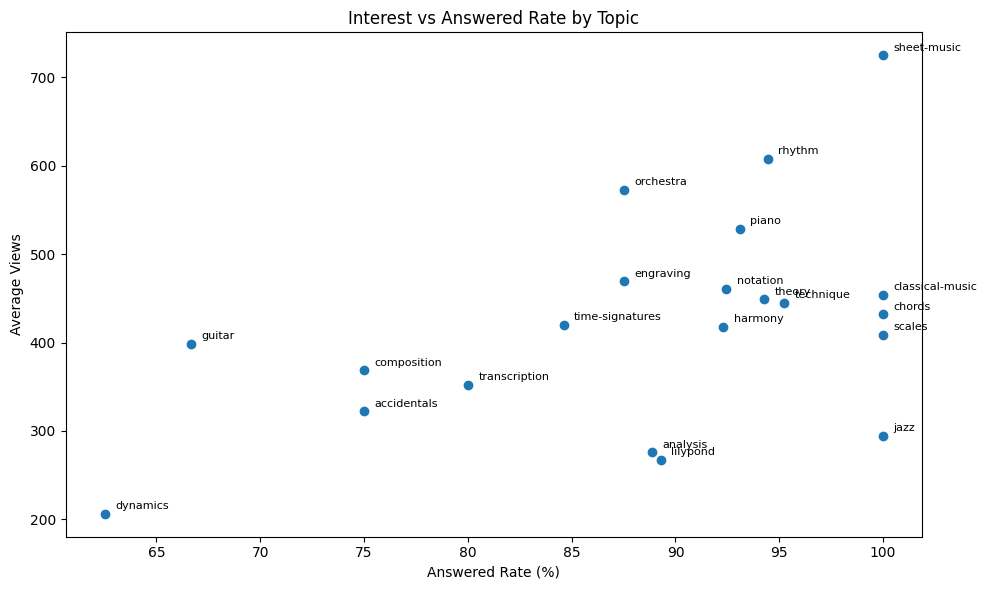

In [79]:
plt.figure(figsize=(10, 6))

plt.scatter(
    tag_summary_filtered["answered_rate_pct"],
    tag_summary_filtered["avg_views"]
)

for _, row in tag_summary_filtered.iterrows():
    plt.text(
        row["answered_rate_pct"] + 0.5,
        row["avg_views"] + 5,
        row["tag"],
        fontsize=8
    )

plt.xlabel("Answered Rate (%)")
plt.ylabel("Average Views")
plt.title("Interest vs Answered Rate by Topic")

plt.tight_layout()
plt.show()

#### Interpretation

จากการวิเคราะห์ Engagement พบว่าค่าเฉลี่ยยอดเข้าชม (Average Views) และ Answered Rate สามารถให้ข้อมูลคนละมุมมองเกี่ยวกับความสนใจและการได้รับคำตอบของแต่ละหัวข้อ โดยหัวข้อที่มีค่าเฉลี่ยยอดเข้าชมสูงไม่ได้หมายความว่าจะเป็นหัวข้อที่ยังขาดคำตอบเสมอไป

ตัวอย่างเช่น `sheet-music` มีค่าเฉลี่ยยอดเข้าชมสูงประมาณ 721.3 views ต่อคำถาม แต่มี Answered Rate 100% แสดงว่าหัวข้อนี้มีระดับการเข้าชมสูง ขณะที่คำถามส่วนใหญ่ได้รับคำตอบแล้ว

ในทางกลับกัน `guitar` มีจำนวน 15 คำถาม ค่าเฉลี่ยยอดเข้าชมประมาณ 385.5 views ต่อคำถาม และมี Answered Rate 60% ซึ่งต่ำกว่าหลายหัวข้อที่นำมาวิเคราะห์ นอกจากนี้ `composition` และ `time-signatures` ยังมีค่าเฉลี่ยยอดเข้าชมค่อนข้างสูงร่วมกับ Answered Rate ที่ต่ำกว่าหัวข้อบางส่วน

ดังนั้น การพิจารณาหัวข้อสำหรับพัฒนา FAQ หรือ Knowledge Content ควรพิจารณาทั้งระดับความสนใจและสัดส่วนคำถามที่ได้รับคำตอบร่วมกัน โดยหัวข้อที่มี Engagement สูงแต่มี Answered Rate ต่ำสามารถนำไปตรวจสอบเพิ่มเติมเพื่อค้นหาโอกาสในการพัฒนาเนื้อหาช่วยเหลือผู้ใช้

## 15. Business Insight

### 15.1 Identify Key Findings
เลือกผลการวิเคราะห์ที่มีความสำคัญและเกี่ยวข้องกับ Decision Support Question

In [80]:
# ============================================================
# 15.1 Identify Key Findings
# ============================================================

# 1. หัวข้อที่ถูกถามบ่อยที่สุด
most_asked = (
    tag_summary_filtered
    .sort_values("question_count", ascending=False)
    .head(10)
)

print("=== Topics Asked Most Frequently ===")
display(
    most_asked[
        [
            "tag",
            "question_count",
            "avg_views",
            "avg_answers",
            "answered_rate_pct"
        ]
    ]
)


# 2. หัวข้อที่มีความสนใจสูง
most_viewed = (
    tag_summary_filtered
    .sort_values("avg_views", ascending=False)
    .head(10)
)

print("=== Topics with Highest Interest ===")
display(
    most_viewed[
        [
            "tag",
            "question_count",
            "avg_views",
            "avg_answers",
            "answered_rate_pct"
        ]
    ]
)


# 3. หัวข้อที่มี Answered Rate ต่ำ
lowest_answered = (
    tag_summary_filtered
    .sort_values(
        ["answered_rate_pct", "avg_views"],
        ascending=[True, False]
    )
    .head(10)
)

print("=== Topics with Lower Answered Rate ===")
display(
    lowest_answered[
        [
            "tag",
            "question_count",
            "avg_views",
            "avg_answers",
            "answered_rate_pct"
        ]
    ]
)

=== Topics Asked Most Frequently ===


,tag,question_count,avg_views,avg_answers,answered_rate_pct
138,notation,53,460.886792,2.132075,92.452830
210,theory,35,449.171429,2.257143,94.285714
157,piano,29,528.689655,2.206897,93.103448
113,lilypond,28,267.285714,1.500000,89.285714
205,technique,21,445.190476,1.904762,95.238095
172,rhythm,18,608.055556,2.333333,94.444444
68,engraving,16,469.250000,2.062500,87.500000
86,guitar,15,398.866667,1.733333,66.666667
212,time-signatures,13,420.230769,2.000000,84.615385
89,harmony,13,417.769231,1.538462,92.307692


=== Topics with Highest Interest ===


,tag,question_count,avg_views,avg_answers,answered_rate_pct
184,sheet-music,9,725.111111,2.777778,100.000000
172,rhythm,18,608.055556,2.333333,94.444444
141,orchestra,8,573.000000,2.000000,87.500000
157,piano,29,528.689655,2.206897,93.103448
68,engraving,16,469.250000,2.062500,87.500000
138,notation,53,460.886792,2.132075,92.452830
40,classical-music,8,454.250000,2.000000,100.000000
210,theory,35,449.171429,2.257143,94.285714
205,technique,21,445.190476,1.904762,95.238095
36,chords,9,432.333333,2.888889,100.000000


=== Topics with Lower Answered Rate ===


,tag,question_count,avg_views,avg_answers,answered_rate_pct
59,dynamics,8,206.250000,1.625000,62.500000
86,guitar,15,398.866667,1.733333,66.666667
44,composition,12,368.500000,1.500000,75.000000
3,accidentals,8,322.625000,1.500000,75.000000
215,transcription,10,352.100000,1.800000,80.000000
212,time-signatures,13,420.230769,2.000000,84.615385
141,orchestra,8,573.000000,2.000000,87.500000
68,engraving,16,469.250000,2.062500,87.500000
10,analysis,9,275.777778,1.111111,88.888889
113,lilypond,28,267.285714,1.500000,89.285714


####สิ่งที่ได้จากผลวิเคราะห์

#### Interpretation

จากผลการวิเคราะห์พบว่า `notation` เป็นหัวข้อที่มีจำนวนคำถามมากที่สุด จำนวน 53 คำถาม รองลงมาคือ `theory` จำนวน 35 คำถาม, `piano` จำนวน 29 คำถาม และ `lilypond` จำนวน 28 คำถาม สะท้อนว่าหัวข้อเหล่านี้เป็นกลุ่มหัวข้อที่มีคำถามจำนวนมากในชุดข้อมูล

ในด้าน Engagement พบว่า `sheet-music` มีค่าเฉลี่ยยอดเข้าชมสูงที่สุดประมาณ 721.3 views ต่อคำถาม แสดงว่าหัวข้อนี้มีระดับการเข้าชมสูงในกลุ่มหัวข้อที่นำมาวิเคราะห์ อย่างไรก็ตาม หัวข้อนี้มี Answered Rate 100% จึงไม่ได้สะท้อนช่องว่างด้านการได้รับคำตอบ

สำหรับหัวข้อที่มี Answered Rate ต่ำ `guitar` มี Answered Rate 60% ซึ่งเป็นค่าต่ำที่สุดในกลุ่มหัวข้อที่มีอย่างน้อย 8 คำถาม นอกจากนี้ `composition` และ `time-signatures` มีค่าเฉลี่ยยอดเข้าชมค่อนข้างสูงร่วมกับ Answered Rate ที่ต่ำกว่าหลายหัวข้อ

ดังนั้น Key Findings ที่เกี่ยวข้องกับ Decision Support Question คือ หัวข้อ `notation` และ `theory` มีจำนวนคำถามสูง ขณะที่ `guitar`, `composition` และ `time-signatures` เป็นหัวข้อที่ควรตรวจสอบเพิ่มเติมจากมุมมองของ Engagement และ Answered Rate เพื่อใช้ประกอบการพิจารณาจัดทำ FAQ หรือ Knowledge Content

### 15.2 Evidence Table
จัดทำตารางแสดงหลักฐานเชิงตัวเลขที่สนับสนุน Business Insight

In [81]:
# ============================================================
# 15.2 Evidence Table
# ============================================================

evidence_tags = [
    "notation",
    "theory",
    "piano",
    "sheet-music",
    "guitar",
    "composition",
    "time-signatures"
]

evidence_table = (
    tag_summary_filtered[
        tag_summary_filtered["tag"].isin(evidence_tags)
    ]
    [
        [
            "tag",
            "question_count",
            "avg_views",
            "avg_score",
            "avg_answers",
            "answered_rate_pct"
        ]
    ]
    .sort_values("question_count", ascending=False)
    .copy()
)

# ปัดทศนิยมให้อ่านง่าย
evidence_table["avg_views"] = evidence_table["avg_views"].round(2)
evidence_table["avg_score"] = evidence_table["avg_score"].round(2)
evidence_table["avg_answers"] = evidence_table["avg_answers"].round(2)
evidence_table["answered_rate_pct"] = (
    evidence_table["answered_rate_pct"].round(2)
)

# เปลี่ยนชื่อคอลัมน์
evidence_table.columns = [
    "Topic",
    "Question Count",
    "Average Views",
    "Average Score",
    "Average Answers",
    "Answered Rate (%)"
]

display(evidence_table)

,Topic,Question Count,Average Views,Average Score,Average Answers,Answered Rate (%)
138,notation,53,460.89,5.49,2.13,92.45
210,theory,35,449.17,3.94,2.26,94.29
157,piano,29,528.69,4.14,2.21,93.10
86,guitar,15,398.87,2.93,1.73,66.67
212,time-signatures,13,420.23,4.46,2.00,84.62
44,composition,12,368.50,3.08,1.50,75.00
184,sheet-music,9,725.11,4.67,2.78,100.00


#### Interpretation

จาก Evidence Table พบว่าแต่ละหัวข้อมีความแตกต่างกันทั้งในด้านจำนวนคำถาม ระดับการเข้าชม และสัดส่วนคำถามที่ได้รับคำตอบ โดย `notation` มีจำนวนคำถามสูงที่สุดในกลุ่มที่นำมาแสดง ขณะที่ `sheet-music` มี Average Views สูงประมาณ 721.3 views ต่อคำถาม และมี Answered Rate 100%

ในทางกลับกัน `guitar` มี Answered Rate 60% และมี Average Views ประมาณ 385.47 views ต่อคำถาม แสดงให้เห็นว่าหัวข้อนี้มีคำถามที่ได้รับคำตอบในสัดส่วนต่ำกว่าหัวข้อบางส่วน แม้ว่าจะมีจำนวนการเข้าชมในระดับหนึ่ง

ดังนั้น Evidence Table ช่วยสนับสนุนการพิจารณาหัวข้อสำหรับ Business Insight โดยควรพิจารณาร่วมกันทั้งจำนวนคำถาม ระดับการเข้าชม และ Answered Rate แทนการใช้ตัวชี้วัดเพียงตัวเดียว

### 15.3 Business Implication
อธิบายว่าผลการวิเคราะห์มีความหมายต่อการตัดสินใจอย่างไร และสามารถนำไปใช้ประโยชน์อะไรได้

In [92]:
# ============================================================
# 15.3 Business Implication
# ============================================================

# หัวข้อที่มีจำนวนคำถามสูง
high_demand = (
    tag_summary_filtered
    .sort_values("question_count", ascending=False)
    .head(10)
)

print("=== High Demand Topics ===")

display(
    high_demand[
        [
            "tag",
            "question_count",
            "avg_views",
            "answered_rate_pct"
        ]
    ]
)


# หัวข้อที่มี Answer Gap
answer_gap = (
    tag_summary_filtered
    .sort_values(
        ["answered_rate_pct", "avg_views"],
        ascending=[True, False]
    )
    .head(10)
)

print("=== Topics with Lower Answered Rate ===")

display(
    answer_gap[
        [
            "tag",
            "question_count",
            "avg_views",
            "avg_answers",
            "answered_rate_pct"
        ]
    ]
)

=== High Demand Topics ===


,tag,question_count,avg_views,answered_rate_pct
138,notation,53,460.886792,92.452830
210,theory,35,449.171429,94.285714
157,piano,29,528.689655,93.103448
113,lilypond,28,267.285714,89.285714
205,technique,21,445.190476,95.238095
172,rhythm,18,608.055556,94.444444
68,engraving,16,469.250000,87.500000
86,guitar,15,398.866667,66.666667
212,time-signatures,13,420.230769,84.615385
89,harmony,13,417.769231,92.307692


=== Topics with Lower Answered Rate ===


,tag,question_count,avg_views,avg_answers,answered_rate_pct
59,dynamics,8,206.250000,1.625000,62.500000
86,guitar,15,398.866667,1.733333,66.666667
44,composition,12,368.500000,1.500000,75.000000
3,accidentals,8,322.625000,1.500000,75.000000
215,transcription,10,352.100000,1.800000,80.000000
212,time-signatures,13,420.230769,2.000000,84.615385
141,orchestra,8,573.000000,2.000000,87.500000
68,engraving,16,469.250000,2.062500,87.500000
10,analysis,9,275.777778,1.111111,88.888889
113,lilypond,28,267.285714,1.500000,89.285714


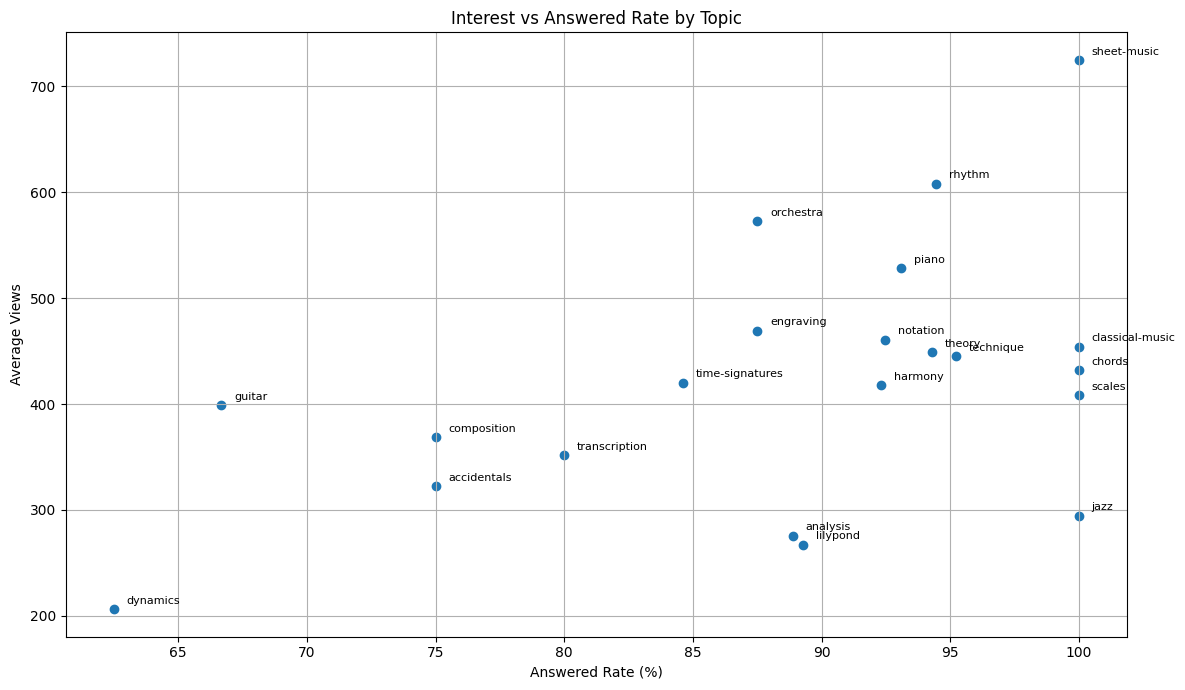

In [83]:
# ============================================================
# Interest vs Answered Rate
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.scatter(
    tag_summary_filtered["answered_rate_pct"],
    tag_summary_filtered["avg_views"]
)

for _, row in tag_summary_filtered.iterrows():
    plt.text(
        row["answered_rate_pct"] + 0.5,
        row["avg_views"] + 5,
        row["tag"],
        fontsize=8
    )

plt.xlabel("Answered Rate (%)")
plt.ylabel("Average Views")
plt.title("Interest vs Answered Rate by Topic")

plt.grid(True)
plt.tight_layout()
plt.show()

#### Business Implication

ผลการวิเคราะห์ช่วยให้ทีม Content / Knowledge สามารถใช้ข้อมูลประกอบการวางแผนจัดทำ FAQ, Knowledge Content หรือแหล่งข้อมูลช่วยเหลือผู้ใช้ โดยพิจารณาร่วมกัน 3 ด้าน ได้แก่ **จำนวนคำถาม ระดับการเข้าชม และ Answered Rate**

หัวข้อที่มีจำนวนคำถามสูง เช่น `notation` และ `theory` แสดงให้เห็นว่ามีคำถามเกี่ยวกับหัวข้อเหล่านี้จำนวนมากในชุดข้อมูล จึงสามารถนำไปใช้เป็นข้อมูลประกอบการวางแผนจัดทำเนื้อหาพื้นฐานหรือ FAQ ที่ครอบคลุมประเด็นที่ถูกถามบ่อย

ในขณะที่ `guitar` มี Average Views ประมาณ 385.5 views ต่อคำถาม แต่มี Answered Rate 60% ซึ่งต่ำกว่าหลายหัวข้อที่นำมาวิเคราะห์ ข้อมูลดังกล่าวสามารถใช้ประกอบการค้นหาประเด็นที่อาจมีช่องว่างด้านคำตอบ และพิจารณาว่าควรเพิ่มเนื้อหาหรือคำแนะนำในหัวข้อนี้หรือไม่

นอกจากนี้ ผลการวิเคราะห์แสดงให้เห็นว่า **Average Views เพียงอย่างเดียวไม่เพียงพอสำหรับการพิจารณาหัวข้อสำหรับพัฒนาเนื้อหา** ตัวอย่างเช่น `sheet-music` มี Average Views สูงประมาณ 721.3 views แต่มี Answered Rate 100% ดังนั้นควรพิจารณาทั้งจำนวนคำถาม ระดับการเข้าชม และ Answered Rate ร่วมกัน

ดังนั้น ผลการวิเคราะห์สามารถนำไปใช้เป็นข้อมูลประกอบการ **วางแผนหัวข้อ FAQ, จัดทำ Knowledge Content และค้นหาหัวข้อที่อาจมีช่องว่างด้านคำตอบ** เพื่อให้การจัดทำเนื้อหาสอดคล้องกับข้อมูลคำถามและพฤติกรรมการมีส่วนร่วมของผู้ใช้งานมากขึ้น

### 15.4 Limitation
ระบุข้อจำกัดของข้อมูลและวิธีการวิเคราะห์ เพื่อป้องกันการตีความผลเกินกว่าขอบเขตของข้อมูล

In [84]:
# ============================================================
# 15.4 Limitation
# ============================================================

# จำนวนข้อมูลทั้งหมด
print("Dataset size:")
print("Records:", len(analysis_df))
print("Columns:", len(analysis_df.columns))


# จำนวน Tag ที่นำมาวิเคราะห์
print("\nTag Summary:")
print("All tags:", len(tag_summary))

print(
    "Tags with at least 8 questions:",
    len(tag_summary_filtered)
)


# ตรวจสอบ Missing Values
print("\nMissing Values:")

missing_values = (
    analysis_df.isnull()
    .sum()
    .reset_index()
)

missing_values.columns = [
    "Column",
    "Missing Count"
]

display(
    missing_values[
        missing_values["Missing Count"] > 0
    ]
)

Dataset size:
Records: 300
Columns: 13

Tag Summary:
All tags: 233
Tags with at least 8 questions: 21

Missing Values:


,Column,Missing Count


#### Limitation

การวิเคราะห์นี้มีข้อจำกัดที่ควรพิจารณาเพื่อป้องกันการตีความผลเกินกว่าขอบเขตของข้อมูล ดังนี้

1. **จำนวนข้อมูลค่อนข้างจำกัด**  
   Dataset มีจำนวน **300 Records และ 12 Columns** จึงอาจไม่ครอบคลุมคำถามและพฤติกรรมของผู้ใช้ Music Stack Exchange ทั้งหมด ผลการวิเคราะห์จึงควรใช้เพื่ออธิบายข้อมูลชุดนี้ และไม่ควรนำไปสรุปแทนผู้ใช้ทั้งหมด

2. **มีจำนวน Tag ที่หลากหลาย แต่ใช้วิเคราะห์เฉพาะบางส่วน**  
   พบทั้งหมด **233 Tags** แต่การวิเคราะห์ Engagement เลือกเฉพาะ Tag ที่มีอย่างน้อย **8 คำถาม** ซึ่งเหลือ 21 Tags ดังนั้นหัวข้อที่มีคำถามน้อยกว่า 8 คำถามจะไม่ถูกนำมาเปรียบเทียบ และอาจมีบางหัวข้อที่น่าสนใจแต่ไม่ปรากฏในผลการวิเคราะห์

3. **Answered Rate ไม่ได้สะท้อนคุณภาพของคำตอบ**  
   Answered Rate ใช้บอกว่าคำถามได้รับคำตอบหรือไม่ แต่ไม่สามารถบอกได้ว่าคำตอบนั้นถูกต้อง มีประโยชน์ หรือมีคุณภาพมากน้อยเพียงใด ดังนั้นไม่ควรตีความว่า Answered Rate สูงหมายถึงผู้ใช้ได้รับคำตอบที่มีคุณภาพเสมอไป

4. **Average Views ไม่ได้หมายถึงความต้องการข้อมูลโดยตรง**  
   จำนวน Views สามารถใช้เป็นตัวชี้วัดระดับการเข้าชมของคำถามได้ แต่ไม่สามารถยืนยันได้โดยตรงว่าผู้ใช้ต้องการให้จัดทำ FAQ หรือ Knowledge Content ในหัวข้อนั้น

5. **ผลการวิเคราะห์เป็นการเปรียบเทียบเชิงพรรณนา**  
   การวิเคราะห์นี้ใช้จำนวนคำถาม ค่าเฉลี่ย Views, Score, Answers และ Answered Rate เพื่อเปรียบเทียบหัวข้อต่าง ๆ จึงสามารถอธิบายลักษณะและแนวโน้มของข้อมูลได้ แต่ไม่สามารถยืนยันสาเหตุหรือความสัมพันธ์เชิงเหตุผลระหว่างตัวแปรได้

ดังนั้น ผลการวิเคราะห์ควรใช้เป็น **ข้อมูลประกอบการตัดสินใจและช่วยระบุหัวข้อที่ควรนำไปพิจารณาต่อ** มากกว่าการสรุปว่าหัวข้อใดเป็นความต้องการของผู้ใช้ทั้งหมด หรือเป็นข้อสรุปที่สามารถใช้แทนผู้ใช้ Music Stack Exchange ทั้งหมด

## 16. Reality Check

ตรวจสอบว่า Business Insight ในข้อ 15 (`guitar`, `composition`, `time-signatures` เป็นหัวข้อที่มีความสนใจสูงแต่ Answered Rate ต่ำ) ยังคงเหมือนเดิมหรือไม่ เมื่อปรับเงื่อนไขหรือแบ่งข้อมูลต่างกัน โดยทำ 3 การทดสอบ

1. **เปลี่ยนเกณฑ์ขั้นต่ำจำนวนคำถามต่อ Tag** จาก 8 เป็น 5 และ 12 เพื่อดูว่าหัวข้อกลุ่มเดิมยังอยู่ในกลุ่ม Answered Rate ต่ำหรือไม่
2. **ตรวจขนาดตัวอย่างและช่วงความไม่แน่นอน** ของ Answered Rate รายหัวข้อ (Wilson 95% CI) เพราะบางหัวข้อมีคำถามไม่มาก
3. **แบ่งข้อมูลตามช่วงเวลา (คำถามเก่ากับใหม่)** เพราะคำถามที่เพิ่งถูกโพสต์อาจยังไม่ทันได้รับคำตอบ ทำให้ Answered Rate ต่ำเกินจริง

### 16.1 ทดสอบเปลี่ยนเกณฑ์ขั้นต่ำจำนวนคำถามต่อ Tag

In [93]:
# ============================================================
# 16.1 Reality Check: เปลี่ยน Minimum Questions per Tag (5 / 8 / 12)
# ============================================================

focus_tags = ["guitar", "composition", "time-signatures"]

for min_q in [5, 8, 12]:

    subset = tag_summary[tag_summary["question_count"] >= min_q].copy()

    print(f"\n===== Minimum Questions per Tag = {min_q} =====")
    print("จำนวน Tag ที่ผ่านเกณฑ์:", len(subset))

    focus_result = subset[
        subset["tag"].isin(focus_tags)
    ][
        [
            "tag",
            "question_count",
            "avg_views",
            "avg_answers",
            "answered_rate_pct"
        ]
    ].sort_values(
        "answered_rate_pct",
        ascending=True
    )

    display(focus_result.round(2))


===== Minimum Questions per Tag = 5 =====
จำนวน Tag ที่ผ่านเกณฑ์: 43


,tag,question_count,avg_views,avg_answers,answered_rate_pct
86,guitar,15,398.87,1.73,66.67
44,composition,12,368.50,1.50,75.00
212,time-signatures,13,420.23,2.00,84.62



===== Minimum Questions per Tag = 8 =====
จำนวน Tag ที่ผ่านเกณฑ์: 21


,tag,question_count,avg_views,avg_answers,answered_rate_pct
86,guitar,15,398.87,1.73,66.67
44,composition,12,368.50,1.50,75.00
212,time-signatures,13,420.23,2.00,84.62



===== Minimum Questions per Tag = 12 =====
จำนวน Tag ที่ผ่านเกณฑ์: 11


,tag,question_count,avg_views,avg_answers,answered_rate_pct
86,guitar,15,398.87,1.73,66.67
44,composition,12,368.50,1.50,75.00
212,time-signatures,13,420.23,2.00,84.62


#### Interpretation

จากการทำ Reality Check โดยเปลี่ยนเกณฑ์ขั้นต่ำของจำนวนคำถามต่อ Tag จาก 5, 8 และ 12 คำถาม พบว่าจำนวน Tags ที่ผ่านเกณฑ์ลดลงจาก 43 Tags เหลือ 21 Tags และ 11 Tags ตามลำดับ

อย่างไรก็ตาม ผลของหัวข้อ `guitar`, `composition` และ `time-signatures` ยังคงเหมือนเดิมในทั้ง 3 เงื่อนไข เนื่องจากแต่ละหัวข้อมีจำนวนคำถามมากกว่าหรือเท่ากับ 12 คำถาม โดย `guitar` มี 15 คำถามและ Answered Rate 66.67%, `composition` มี 12 คำถามและ Answered Rate 75.00% และ `time-signatures` มี 13 คำถามและ Answered Rate 84.62%

ผลการทดสอบนี้แสดงให้เห็นว่า ค่า Answered Rate ของทั้ง 3 หัวข้อไม่ได้เปลี่ยนแปลงเมื่อปรับเกณฑ์ขั้นต่ำของจำนวนคำถามในช่วง 5–12 คำถาม ดังนั้น Finding เดิมมีความคงที่ต่อการเปลี่ยนเกณฑ์ขั้นต่ำในส่วนนี้

อย่างไรก็ตาม การทดสอบนี้ยังไม่ได้ยืนยันว่าทั้ง 3 หัวข้อเป็นกลุ่มที่มีความสนใจสูงและมี Answered Rate ต่ำที่สุด เนื่องจากยังต้องพิจารณาผลของช่วงความไม่แน่นอนของ Answered Rate และการแบ่งข้อมูลตามช่วงเวลาในขั้นตอน Reality Check ถัดไป

### 16.2 ตรวจขนาดตัวอย่างและช่วงความไม่แน่นอนของ Answered Rate

In [86]:
# 16.2 Reality Check: Sample size + Wilson 95% CI

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (centre - half, centre + half)

overall_rate = analysis_df["is_answered"].mean() * 100
print(f"Answered Rate รวมทั้ง Dataset = {overall_rate:.2f}% ({len(analysis_df)} คำถาม)")

rows = []
for t in focus_tags + ["notation", "theory", "piano", "sheet-music"]:
    r = tag_summary[tag_summary["tag"] == t]
    if r.empty:
        continue
    r = r.iloc[0]
    n = int(r["question_count"])
    k = int(round(r["answered_rate"] * n))
    lo, hi = wilson_ci(k, n)
    rows.append({
        "tag": t,
        "questions": n,
        "answered": k,
        "answered_rate_pct": round(r["answered_rate"] * 100, 1),
        "ci95_low_pct": round(lo * 100, 1),
        "ci95_high_pct": round(hi * 100, 1),
        "overlaps_overall": lo * 100 <= overall_rate <= hi * 100
    })

ci_table = pd.DataFrame(rows)
display(ci_table)

Answered Rate รวมทั้ง Dataset = 87.67% (300 คำถาม)


,tag,questions,answered,answered_rate_pct,ci95_low_pct,ci95_high_pct,overlaps_overall
0,guitar,15,10,66.7,41.7,84.8,False
1,composition,12,9,75.0,46.8,91.1,True
2,time-signatures,13,11,84.6,57.8,95.7,True
3,notation,53,49,92.5,82.1,97.0,True
4,theory,35,33,94.3,81.4,98.4,True
5,piano,29,27,93.1,78.0,98.1,True
6,sheet-music,9,9,100.0,70.1,100.0,True


#### Interpretation

จากการตรวจสอบขนาดตัวอย่างและช่วงความไม่แน่นอนของ Answered Rate ด้วย Wilson 95% Confidence Interval พบว่า Answered Rate รวมของ Dataset อยู่ที่ **87.67% จาก 300 คำถาม**

สำหรับหัวข้อที่นำมาวิเคราะห์ พบว่า `guitar` มี Answered Rate **66.7%** และมี Wilson 95% CI อยู่ที่ **41.7%–84.8%** โดยช่วงดังกล่าวไม่ครอบคลุม Answered Rate รวมของ Dataset ที่ 87.67% (`overlaps_overall = False`) จึงเป็นหัวข้อที่มีสัญญาณค่อนข้างชัดว่า Answered Rate ในข้อมูลชุดนี้ต่ำกว่าอัตรารวม

ในทางกลับกัน `composition` มี Answered Rate **75.0%** และ CI อยู่ที่ **46.8%–91.1%** ส่วน `time-signatures` มี Answered Rate **84.6%** และ CI อยู่ที่ **57.8%–95.7%** โดยทั้งสองหัวข้อมีช่วง CI ที่ครอบคลุม Answered Rate รวม (`overlaps_overall = True`) ดังนั้นยังไม่ควรสรุปว่ามี Answered Rate ต่ำกว่า Dataset โดยรวมอย่างชัดเจน

สำหรับหัวข้อที่มีจำนวนคำถามมากกว่า เช่น `notation`, `theory` และ `piano` พบว่า Answered Rate อยู่ในช่วงประมาณ **92.5%–94.3%** และมีช่วง CI ที่กว้างน้อยกว่าหัวข้อที่มีจำนวนคำถามเพียง 12–15 คำถามในบางกรณี สะท้อนว่าขนาดตัวอย่างมีผลต่อความไม่แน่นอนของค่าประมาณ

ผล Reality Check นี้จึงช่วยปรับความแข็งแรงของ Finding เดิม โดย `guitar` ยังคงเป็นหัวข้อที่ควรตรวจสอบเพิ่มเติมจากมุมมองของ Answered Rate ขณะที่ `composition` และ `time-signatures` ควรตีความอย่างระมัดระวัง เนื่องจากช่วงความไม่แน่นอนยังครอบคลุมอัตรารวมของ Dataset

อย่างไรก็ตาม Wilson 95% CI ในที่นี้ใช้เพื่อแสดงความไม่แน่นอนของสัดส่วนจากข้อมูลที่เก็บมา ไม่ควรตีความว่าเป็นหลักฐานยืนยันว่าอัตราดังกล่าวสามารถแทนผู้ใช้ Music Stack Exchange ทั้งหมดได้ เนื่องจากข้อมูลที่ใช้วิเคราะห์เป็นชุดคำถามที่เก็บมา 300 รายการและไม่ได้เป็นการสุ่มตัวอย่างผู้ใช้ทั้งหมด

### 16.3 แบ่งข้อมูลตามช่วงเวลา (คำถามเก่า vs คำถามใหม่)

In [87]:
# 16.3 Reality Check: แบ่งครึ่งตามเวลาที่ตั้งคำถาม

rc_df = analysis_df.copy()

# แปลง creation_date เป็น datetime (รองรับทั้ง Unix seconds และ datetime อยู่แล้ว)
if np.issubdtype(rc_df["creation_date"].dtype, np.datetime64):
    rc_df["created"] = rc_df["creation_date"]
else:
    rc_df["created"] = pd.to_datetime(rc_df["creation_date"], unit="s", errors="coerce")

median_date = rc_df["created"].median()
rc_df["period"] = np.where(rc_df["created"] <= median_date, "Older half", "Newer half")

print("Median creation date:", median_date)
print("\nAnswered Rate รวม แยกตามช่วงเวลา")
display(
    rc_df.groupby("period")
    .agg(questions=("question_id", "nunique"),
         answered_rate_pct=("is_answered", lambda s: round(s.mean() * 100, 1)),
         first=("created", "min"),
         last=("created", "max"))
)

# Answered Rate รายหัวข้อ แยกตามช่วงเวลา
exploded = rc_df.explode("tags").dropna(subset=["tags"])
exploded["is_answered"] = exploded["is_answered"].astype(float)

period_tag = (
    exploded[exploded["tags"].isin(focus_tags)]
    .groupby(["tags", "period"])
    .agg(questions=("question_id", "nunique"),
         answered_rate_pct=("is_answered", lambda s: round(s.mean() * 100, 1)))
    .unstack("period")
)

print("\nAnswered Rate ของหัวข้อหลัก แยกตามช่วงเวลา")
display(period_tag)

Median creation date: 2026-05-30 07:35:12.500000

Answered Rate รวม แยกตามช่วงเวลา


,questions,answered_rate_pct,first,last
period,,,,
Newer half,150,84.0,2026-05-30 16:25:32,2026-09-29 22:44:36
Older half,150,91.3,2026-01-24 04:59:20,2026-05-29 22:44:53



Answered Rate ของหัวข้อหลัก แยกตามช่วงเวลา


questions            answered_rate_pct           
period          Newer half Older half        Newer half Older half
tags                                                              
composition              6          6              50.0      100.0
guitar                  11          4              63.6       75.0
time-signatures          9          4              77.8      100.0

#### Interpretation

จากการแบ่งข้อมูลตามช่วงเวลาที่สร้างคำถาม โดยใช้ Median Creation Date เป็นจุดแบ่ง พบว่า Dataset ถูกแบ่งออกเป็น 2 กลุ่ม กลุ่มละ 150 คำถาม โดยมี Median Creation Date เท่ากับ **30 พฤษภาคม 2026**

เมื่อพิจารณา Answered Rate รวม พบว่า **Older half มี Answered Rate 91.3%** ขณะที่ **Newer half มี Answered Rate 84.0%** ซึ่งแสดงให้เห็นว่าคำถามที่ถูกสร้างขึ้นในช่วงหลังมีสัดส่วนการได้รับคำตอบต่ำกว่าคำถามในช่วงก่อนหน้า

เมื่อพิจารณาเฉพาะหัวข้อหลัก พบว่า `guitar` มี Answered Rate **75.0% ใน Older half** และลดลงเป็น **63.6% ใน Newer half** ขณะที่ `time-signatures` ลดลงจาก **100.0% เป็น 77.8%** และ `composition` ลดลงจาก **100.0% เป็น 50.0%**

อย่างไรก็ตาม จำนวนคำถามของแต่ละหัวข้อในแต่ละช่วงเวลาค่อนข้างน้อย เช่น `composition` มีเพียง 6 คำถามในแต่ละช่วง และ `time-signatures` มี 4 คำถามใน Older half ดังนั้นเปอร์เซ็นต์ที่แตกต่างกันมากอาจเกิดจากขนาดตัวอย่างที่เล็ก และไม่ควรตีความว่าเป็นแนวโน้มที่แน่นอน

ผลการแบ่งช่วงเวลาช่วยสนับสนุนข้อสังเกตว่า Answered Rate ของคำถามใหม่อาจต่ำกว่าคำถามเก่า เนื่องจากคำถามใหม่มีระยะเวลาในการรอรับคำตอบน้อยกว่า ดังนั้น Answered Rate จึงควรถูกตีความร่วมกับอายุของคำถาม ไม่ควรใช้เป็นตัวชี้วัดความเพียงพอของคำตอบเพียงอย่างเดียว

เมื่อพิจารณาร่วมกับ Reality Check ในข้อ 16.1 และ 16.2 พบว่า `guitar` ยังคงเป็นหัวข้อที่มีสัญญาณของ Answered Rate ต่ำกว่าอัตรารวม แต่ผลของ `composition` และ `time-signatures` มีความไม่แน่นอนมากกว่า เนื่องจากจำนวนคำถามในแต่ละช่วงเวลาค่อนข้างน้อย

### 16.4 สรุปผล Reality Check

> **หมายเหตุ:** ตัวเลขด้านล่างต้องกรอกหลังรัน Cell 16.1–16.3 แล้ว ห้ามนำตัวเลขที่ยังไม่ได้ตรวจสอบมาใส่

**Insight ที่ตรวจสอบ:** `guitar` (15 คำถาม, Answered Rate 60%), `composition` และ `time-signatures` มีความสนใจสูงแต่ Answered Rate ต่ำกว่าหัวข้ออื่น

**1. เปลี่ยนเกณฑ์ขั้นต่ำต่อ Tag (5 / 8 / 12)**
- เมื่อใช้เกณฑ์ 5 คำถาม: [ระบุว่า guitar / composition / time-signatures ยังอยู่ในกลุ่มต่ำสุดหรือไม่ และอันดับเท่าไร]
- เมื่อใช้เกณฑ์ 12 คำถาม: [ระบุว่าหัวข้อใดยังผ่านเกณฑ์และยังอยู่ในกลุ่มต่ำ]

**2. ขนาดตัวอย่างและช่วงความไม่แน่นอน**
- `guitar` มี 15 คำถาม จึงมีช่วง 95% CI กว้าง ([ใส่ช่วง]) และ [ทับ / ไม่ทับ] กับ Answered Rate รวมของ Dataset ([ใส่ค่า]%)
- ถ้าช่วงทับกัน ให้ตีความว่า Answered Rate ที่ต่ำกว่าอาจเกิดจากความแปรปรวนของตัวอย่างขนาดเล็ก

**3. แบ่งตามช่วงเวลา**
- Answered Rate ของคำถามเก่า [ค่า]% เทียบกับคำถามใหม่ [ค่า]%
- หัวข้อหลักในครึ่งเก่า: [ค่า] / ครึ่งใหม่: [ค่า] (ระวังจำนวนคำถามต่อกลุ่มที่น้อยมาก)

**ข้อสรุป:** เลือกตามผลที่ได้ เช่น "Insight ยังคงปรากฏในทุกเกณฑ์ แต่ควรระวังขนาดตัวอย่าง" หรือ "Insight ไม่คงที่เมื่อเปลี่ยนเงื่อนไข จึงใช้เป็นสัญญาณเบื้องต้นเท่านั้น"

ทั้งนี้ผลเป็นการเปรียบเทียบเชิงพรรณนาจากข้อมูล 300 คำถาม ไม่สามารถสรุปเหตุและผล และไม่ควรใช้แทนพฤติกรรมของผู้ใช้ Music Stack Exchange ทั้งหมด

## 17. Main Visualizations

สร้างกราฟที่ช่วยสื่อสารผลการวิเคราะห์และ Business Insight เช่น Top Tags, Top Words หรือ Engagement by Topic

### 17.1 Main Graph ที่ 1

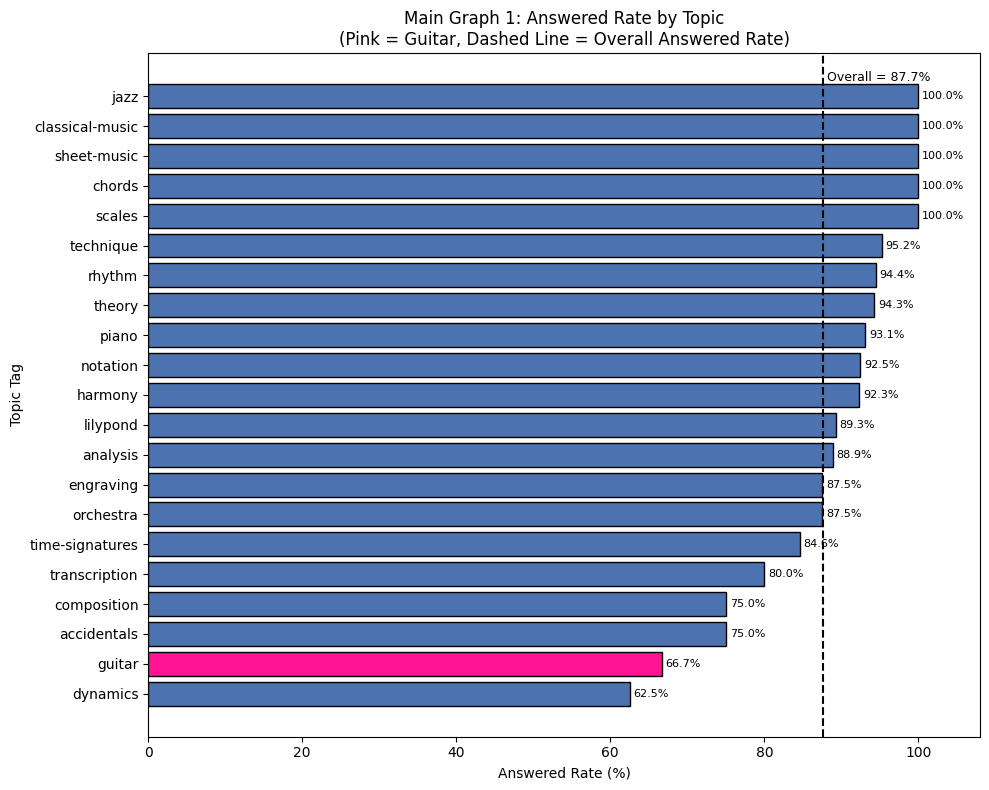

In [96]:
# ============================================================
# 17.1 Main Graph 1: Answered Rate by Topic
# ============================================================

plot_tags = tag_summary_filtered.sort_values(
    "answered_rate_pct"
).copy()

# Highlight guitar as the topic with the clearest lower
# Answered Rate signal from the Reality Check
colors = [
    "#FF1493" if t == "guitar" else "#4C72B0"
    for t in plot_tags["tag"]
]

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    plot_tags["tag"],
    plot_tags["answered_rate_pct"],
    color=colors,
    edgecolor="black"
)

# Overall Answered Rate reference line
ax.axvline(
    overall_rate,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax.text(
    overall_rate + 0.5,
    len(plot_tags) - 0.5,
    f"Overall = {overall_rate:.1f}%",
    fontsize=9
)

# Add percentage labels
for bar, val in zip(
    bars,
    plot_tags["answered_rate_pct"]
):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=8
    )

ax.set_xlabel("Answered Rate (%)")
ax.set_ylabel("Topic Tag")

ax.set_title(
    "Main Graph 1: Answered Rate by Topic\n"
    "(Pink = Guitar, Dashed Line = Overall Answered Rate)"
)

ax.set_xlim(0, 108)

plt.tight_layout()
plt.show()

#### Interpretation

จากกราฟแสดงค่า Answered Rate ของแต่ละหัวข้อ โดยเส้นประแสดงค่า Answered Rate รวมของ Dataset ซึ่งอยู่ที่ **87.67%** จากคำถามทั้งหมด 300 คำถาม

เมื่อพิจารณาหัวข้อที่นำมาเป็น Focus Topics พบว่า `guitar` มี Answered Rate ต่ำที่สุดที่ **66.7%** ซึ่งต่ำกว่าค่าเฉลี่ยรวมของ Dataset อย่างชัดเจน แสดงว่าคำถามในหัวข้อนี้มีสัดส่วนที่ได้รับคำตอบต่ำกว่าภาพรวมของข้อมูล

สำหรับ `composition` มี Answered Rate **75.0%** และ `time-signatures` มี Answered Rate **84.6%** ซึ่งต่ำกว่าค่า Answered Rate รวมเช่นกัน อย่างไรก็ตาม จาก Reality Check ใน Section 16 พบว่าช่วงความไม่แน่นอนของทั้งสองหัวข้อยังครอบคลุมค่า Answered Rate รวม จึงควรตีความผลอย่างระมัดระวัง

ในขณะที่หัวข้อที่มีจำนวนคำถามสูง เช่น `notation`, `theory` และ `piano` มี Answered Rate สูงกว่าค่าเฉลี่ยรวม โดยมีค่า **92.5%, 94.3% และ 93.1%** ตามลำดับ

โดยสรุป กราฟแสดงให้เห็นว่า `guitar` เป็นหัวข้อที่ควรนำไปตรวจสอบเพิ่มเติมมากที่สุดจากมุมมองของ Answered Rate เนื่องจากมีค่า Answered Rate ต่ำกว่าภาพรวมอย่างชัดเจน อย่างไรก็ตาม Answered Rate เพียงอย่างเดียวไม่สามารถยืนยันว่าหัวข้อนั้นมีความต้องการข้อมูลสูงหรือมีคุณภาพคำตอบต่ำ ดังนั้นควรพิจารณาร่วมกับจำนวนคำถาม, Views และผลจาก Reality Check ใน Section 16

### 17.2 Main Graph ที่ 2

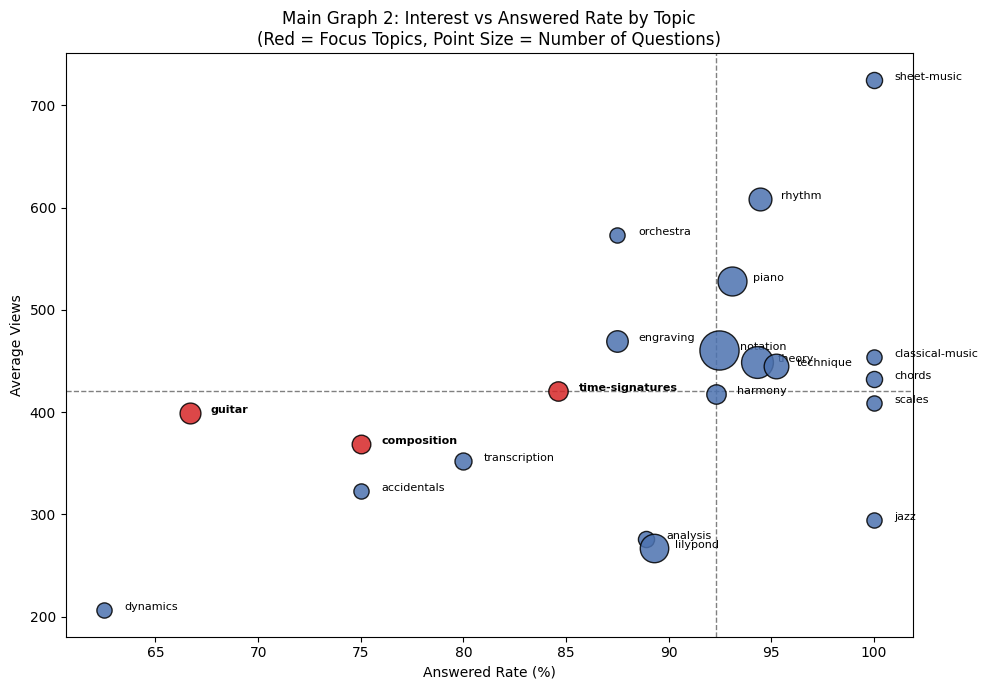

In [97]:
# ============================================================
# 17.2 Main Graph 2: Interest (Avg Views) vs Answered Rate
# Point size = number of questions per tag
# Dashed lines = median values used to divide the quadrants
# ============================================================

median_views = tag_summary_filtered["avg_views"].median()
median_answered = tag_summary_filtered["answered_rate_pct"].median()

fig, ax = plt.subplots(figsize=(10, 7))

for _, row in tag_summary_filtered.iterrows():
    is_focus = row["tag"] in focus_tags

    ax.scatter(
        row["answered_rate_pct"],
        row["avg_views"],
        s=row["question_count"] * 15,
        color="#D62728" if is_focus else "#4C72B0",
        edgecolor="black",
        alpha=0.85,
        zorder=3
    )

    ax.text(
        row["answered_rate_pct"] + 1,
        row["avg_views"],
        row["tag"],
        fontsize=8,
        fontweight="bold" if is_focus else "normal"
    )

# Median reference lines
ax.axvline(
    median_answered,
    color="gray",
    linestyle="--",
    linewidth=1,
    zorder=1
)

ax.axhline(
    median_views,
    color="gray",
    linestyle="--",
    linewidth=1,
    zorder=1
)

ax.set_xlabel("Answered Rate (%)")
ax.set_ylabel("Average Views")

ax.set_title(
    "Main Graph 2: Interest vs Answered Rate by Topic\n"
    "(Red = Focus Topics, Point Size = Number of Questions)"
)

plt.tight_layout()
plt.show()

#### Interpretation

จากกราฟ Scatter Plot แสดงความสัมพันธ์ระหว่าง **Average Views** ซึ่งใช้เป็นตัวชี้วัดระดับความสนใจของหัวข้อ และ **Answered Rate** ของแต่ละ Topic โดยขนาดของจุดแสดงจำนวนคำถามของแต่ละ Tag ส่วนเส้นประแนวตั้งและแนวนอนแสดงค่า Median ของ Answered Rate และ Average Views ตามลำดับ เพื่อใช้แบ่งข้อมูลออกเป็น 4 กลุ่ม

เมื่อพิจารณาหัวข้อ Focus Topics พบว่า `guitar` มี Answered Rate ประมาณ **66.7%** และมี Average Views ประมาณ **398.9 views** ต่อคำถาม จึงอยู่ในกลุ่มที่มี Answered Rate ต่ำกว่าค่า Median และมีระดับ Views ค่อนข้างสูงเมื่อเทียบกับหัวข้อใน Dataset

`composition` มี Answered Rate **75.0%** และ Average Views ประมาณ **368.5 views** ขณะที่ `time-signatures` มี Answered Rate **84.6%** และ Average Views ประมาณ **420.2 views** ซึ่งแสดงให้เห็นว่าทั้งสองหัวข้อมีการเข้าชมในระดับหนึ่ง แต่มี Answered Rate ต่ำกว่าหลายหัวข้อ

ผลจากกราฟจึงช่วยให้เห็นว่า `guitar` เป็นหัวข้อที่ควรนำไปตรวจสอบเพิ่มเติม เพราะมีทั้งระดับการเข้าชมที่ค่อนข้างสูงและ Answered Rate ที่ต่ำกว่าอัตรารวมของ Dataset อย่างไรก็ตาม ไม่ควรตีความว่า Average Views เป็นหลักฐานโดยตรงของความต้องการข้อมูล และผลของ `composition` และ `time-signatures` ยังมีความไม่แน่นอนจากขนาดตัวอย่างที่ค่อนข้างเล็กตามที่พบใน Reality Check

โดยสรุป Scatter Plot ช่วยให้เห็นความสัมพันธ์ระหว่าง **ระดับการเข้าชมและ Answered Rate** ของแต่ละหัวข้อ และช่วยระบุหัวข้อที่ควรนำไปตรวจสอบเพิ่มเติม แต่ไม่สามารถใช้ยืนยันสาเหตุหรือสรุปความต้องการของผู้ใช้ทั้งหมดได้

### 17.3 ตรวจสอบความถูกต้องและความสอดคล้องของ Graphs

In [98]:
# ============================================================
# 17.3 ตรวจสอบความถูกต้องและความสอดคล้องของ Graphs
# Recalculate focus-topic metrics from raw tag_engagement
# and compare with the values used in the graphs
# ============================================================

print("===== ตรวจสอบตัวเลขของ Focus Topics ที่ใช้ใน Main Graphs =====")

verification_rows = []

for t in focus_tags:

    # --------------------------------------------
    # 1. ดึงข้อมูลดิบของ topic จาก tag_engagement
    # --------------------------------------------
    raw = tag_engagement[tag_engagement["tag"] == t].copy()

    # --------------------------------------------
    # 2. คำนวณค่าใหม่จาก raw data
    # --------------------------------------------
    recompute_question_count = raw["question_id"].nunique()
    recompute_avg_views = raw["view_count"].mean()
    recompute_answered_rate = raw["is_answered"].mean() * 100

    # --------------------------------------------
    # 3. ดึงค่าที่ใช้ใน Graphs
    # --------------------------------------------
    graph_row = tag_summary_filtered[
        tag_summary_filtered["tag"] == t
    ].iloc[0]

    graph_question_count = int(graph_row["question_count"])
    graph_avg_views = graph_row["avg_views"]
    graph_answered_rate = graph_row["answered_rate_pct"]

    # --------------------------------------------
    # 4. เปรียบเทียบ
    # --------------------------------------------
    verification_rows.append({
        "tag": t,

        "question_count_recomputed": recompute_question_count,
        "question_count_graph": graph_question_count,
        "question_count_match":
            recompute_question_count == graph_question_count,

        "avg_views_recomputed": recompute_avg_views,
        "avg_views_graph": graph_avg_views,
        "avg_views_match":
            np.isclose(recompute_avg_views, graph_avg_views),

        "answered_rate_recomputed": recompute_answered_rate,
        "answered_rate_graph": graph_answered_rate,
        "answered_rate_match":
            np.isclose(recompute_answered_rate, graph_answered_rate)
    })


# ============================================================
# 5. แสดงผลการตรวจสอบ
# ============================================================

verification_df = pd.DataFrame(verification_rows)

display(
    verification_df.round({
        "avg_views_recomputed": 2,
        "avg_views_graph": 2,
        "answered_rate_recomputed": 2,
        "answered_rate_graph": 2
    })
)


# ============================================================
# 6. ตรวจสอบว่า Graph 1 และ Graph 2 ใช้ค่าถูกต้อง
# ============================================================

print("\n===== Overall Reference for Main Graph 1 =====")
print(
    f"Overall Answered Rate = {overall_rate:.2f}%"
)

print("\n===== Median Reference for Main Graph 2 =====")
print(
    f"Median Answered Rate = {median_answered:.2f}%"
)
print(
    f"Median Average Views = {median_views:.2f}"
)


# ============================================================
# 7. สรุปผลอัตโนมัติ
# ============================================================

all_checks_pass = (
    verification_df["question_count_match"].all()
    and verification_df["avg_views_match"].all()
    and verification_df["answered_rate_match"].all()
)

print("\n===== Verification Result =====")

if all_checks_pass:
    print("PASS: ตัวเลขของ Focus Topics ตรงกับค่าที่ใช้ใน Graphs ทั้งหมด")
else:
    print("CHECK: พบตัวเลขบางรายการไม่ตรงกัน กรุณาตรวจสอบตารางด้านบน")

===== ตรวจสอบตัวเลขของ Focus Topics ที่ใช้ใน Main Graphs =====


,tag,question_count_recomputed,question_count_graph,question_count_match,avg_views_recomputed,avg_views_graph,avg_views_match,answered_rate_recomputed,answered_rate_graph,answered_rate_match
0,guitar,15,15,True,398.87,398.87,True,66.67,66.67,True
1,composition,12,12,True,368.50,368.50,True,75.00,75.00,True
2,time-signatures,13,13,True,420.23,420.23,True,84.62,84.62,True



===== Overall Reference for Main Graph 1 =====
Overall Answered Rate = 87.67%

===== Median Reference for Main Graph 2 =====
Median Answered Rate = 92.31%
Median Average Views = 420.23

===== Verification Result =====
PASS: ตัวเลขของ Focus Topics ตรงกับค่าที่ใช้ใน Graphs ทั้งหมด


#### Graph Verification

ตรวจสอบความถูกต้องของตัวเลขที่ใช้ใน Main Graph 1 และ Main Graph 2 โดยคำนวณ `Question Count`, `Average Views` และ `Answered Rate` ของ Focus Topics (`guitar`, `composition`, `time-signatures`) ใหม่จาก `tag_engagement` ซึ่งเป็นข้อมูลก่อนการสรุปผล พบว่าค่าที่คำนวณใหม่ตรงกับค่าที่ใช้ในกราฟทั้งหมด

ผลการตรวจสอบจึงยืนยันว่า **ตัวเลขของ Focus Topics, Overall Answered Rate และค่า Median ที่ใช้เป็นเส้นอ้างอิงในกราฟมีความสอดคล้องกับข้อมูลที่ใช้ในการวิเคราะห์**

## 18. Insight Card

สรุป Business Insight ที่สำคัญในรูปแบบ Insight Card ประกอบด้วย Insight, Evidence, So What, Action, Confidence และ Limitation

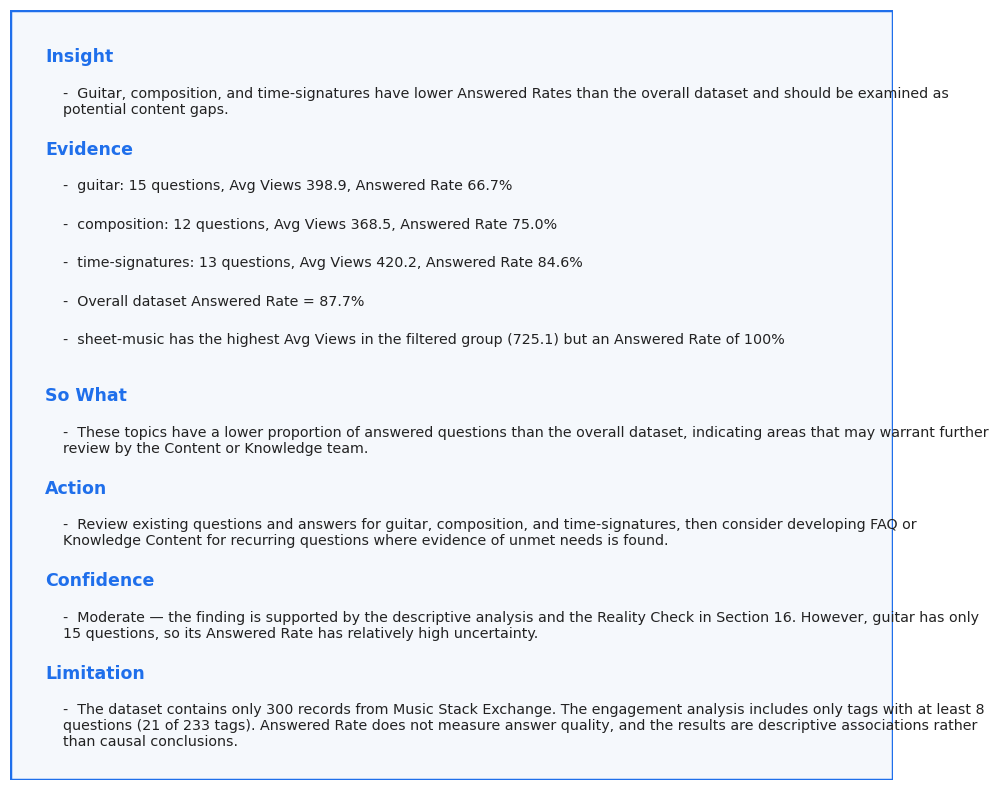

In [99]:
# ============================================================
# 18. Insight Card
# Content Gap: guitar, composition, time-signatures
# Lower Answered Rate and topics requiring further review
# ============================================================

def draw_insight_card_full(insight, evidence_lines, so_what, action,
                           confidence, limitation, color="#1F6FEB"):

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.axis("off")

    ax.add_patch(
        plt.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,
            facecolor="#F5F8FC",
            edgecolor=color,
            linewidth=2.5
        )
    )

    y = 0.95

    def section(label, text_lines, y, fontsize=10.3, gap=0.05):

        ax.text(
            0.04, y, label,
            fontsize=12.5,
            fontweight="bold",
            color=color,
            transform=ax.transAxes,
            va="top"
        )

        y -= gap

        for line in text_lines:
            ax.text(
                0.06, y,
                f"-  {line}",
                fontsize=fontsize,
                color="#222222",
                transform=ax.transAxes,
                va="top",
                wrap=True
            )
            y -= gap

        return y - 0.02

    y = section("Insight", [insight], y)
    y = section("Evidence", evidence_lines, y)
    y = section("So What", [so_what], y)
    y = section("Action", [action], y)
    y = section("Confidence", [confidence], y)
    y = section("Limitation", [limitation], y)

    plt.tight_layout()
    plt.show()


# ============================================================
# Get topic metrics
# ============================================================

guitar_row = tag_summary_filtered[
    tag_summary_filtered["tag"] == "guitar"
].iloc[0]

comp_row = tag_summary_filtered[
    tag_summary_filtered["tag"] == "composition"
].iloc[0]

time_row = tag_summary_filtered[
    tag_summary_filtered["tag"] == "time-signatures"
].iloc[0]

sheet_row = tag_summary_filtered[
    tag_summary_filtered["tag"] == "sheet-music"
].iloc[0]


# ============================================================
# Draw Insight Card
# ============================================================

draw_insight_card_full(

    insight=(
        "Guitar, composition, and time-signatures have lower Answered Rates "
        "than the overall dataset and should be examined as potential content gaps."
    ),

    evidence_lines=[

        f"guitar: {int(guitar_row['question_count'])} questions, "
        f"Avg Views {guitar_row['avg_views']:.1f}, "
        f"Answered Rate {guitar_row['answered_rate_pct']:.1f}%",

        f"composition: {int(comp_row['question_count'])} questions, "
        f"Avg Views {comp_row['avg_views']:.1f}, "
        f"Answered Rate {comp_row['answered_rate_pct']:.1f}%",

        f"time-signatures: {int(time_row['question_count'])} questions, "
        f"Avg Views {time_row['avg_views']:.1f}, "
        f"Answered Rate {time_row['answered_rate_pct']:.1f}%",

        f"Overall dataset Answered Rate = {overall_rate:.1f}%",

        f"sheet-music has the highest Avg Views in the filtered group "
        f"({sheet_row['avg_views']:.1f}) but an Answered Rate of "
        f"{sheet_row['answered_rate_pct']:.0f}%"
    ],

    so_what=(
        "These topics have a lower proportion of answered questions than "
        "the overall dataset, indicating areas that may warrant further "
        "review by the Content or Knowledge team."
    ),

    action=(
        "Review existing questions and answers for guitar, composition, "
        "and time-signatures, then consider developing FAQ or Knowledge "
        "Content for recurring questions where evidence of unmet needs is found."
    ),

    confidence=(
        "Moderate — the finding is supported by the descriptive analysis "
        "and the Reality Check in Section 16. However, guitar has only "
        "15 questions, so its Answered Rate has relatively high uncertainty."
    ),

    limitation=(
        "The dataset contains only 300 records from Music Stack Exchange. "
        "The engagement analysis includes only tags with at least 8 questions "
        "(21 of 233 tags). Answered Rate does not measure answer quality, "
        "and the results are descriptive associations rather than causal conclusions."
    )
)

#### Insight

หัวข้อ `guitar`, `composition` และ `time-signatures` มี **Answered Rate ต่ำกว่าค่า Answered Rate รวมของ Dataset** จึงควรนำไปตรวจสอบเพิ่มเติมว่าอาจมีช่องว่างด้านเนื้อหาหรือไม่

### Evidence

- `guitar`: 15 คำถาม, Average Views = **398.9**, Answered Rate = **66.7%**
- `composition`: 12 คำถาม, Average Views = **368.5**, Answered Rate = **75.0%**
- `time-signatures`: 13 คำถาม, Average Views = **420.2**, Answered Rate = **84.6%**
- Overall Answered Rate ของ Dataset = **87.67%**
- `sheet-music` มี Average Views สูงสุดในกลุ่มที่วิเคราะห์ที่ **721.3 views** แต่มี Answered Rate = **100%**

### So What

ทั้ง 3 หัวข้อมีสัดส่วนคำถามที่ได้รับคำตอบต่ำกว่าภาพรวมของ Dataset จึงเป็นหัวข้อที่ทีม Content หรือ Knowledge ควรนำไปตรวจสอบเพิ่มเติม โดยเฉพาะการตรวจสอบว่ามีคำถามที่เกิดซ้ำหรือมีประเด็นที่ยังไม่มีเนื้อหาช่วยเหลือที่เหมาะสมหรือไม่

### Action

ตรวจสอบคำถามและคำตอบของ `guitar`, `composition` และ `time-signatures` เพิ่มเติม จากนั้นพิจารณาจัดทำ FAQ หรือ Knowledge Content สำหรับคำถามที่พบว่ามีลักษณะซ้ำหรือมีความต้องการข้อมูลที่ชัดเจน

### Confidence

**ปานกลาง (Moderate)** — ผลการวิเคราะห์ได้รับการสนับสนุนจาก Descriptive Analysis, Main Graphs และ Reality Check ใน Section 16 อย่างไรก็ตาม `guitar` มีเพียง 15 คำถาม จึงยังมีความไม่แน่นอนของค่า Answered Rate ค่อนข้างสูง

### Limitation

Dataset มีเพียง **300 records** จาก Music Stack Exchange และการวิเคราะห์ Engagement พิจารณาเฉพาะ Tag ที่มีอย่างน้อย 8 คำถาม ซึ่งมี **21 จาก 233 tags** เท่านั้น นอกจากนี้ Answered Rate ไม่ได้สะท้อนคุณภาพของคำตอบ และผลการวิเคราะห์เป็นความสัมพันธ์เชิงพรรณนา จึงไม่สามารถใช้สรุปความสัมพันธ์เชิงเหตุและผลหรือแทนพฤติกรรมของผู้ใช้ Music Stack Exchange ทั้งหมดได้

## 19. Final Review

ตรวจสอบความครบถ้วนของ Data Collection, Data Quality, Analysis, Business Insight, Visualizations และ Insight Card ก่อนจัดทำรายงานและนำเสนอ

## 19. Final Review

ตรวจสอบความครบถ้วนของ Data Collection, Data Quality, Analysis, Business Insight, Visualizations และ Insight Card ก่อนจัดทำรายงานและนำเสนอ

### 19.1 Data Collection

- [x] ใช้ Music Stack Exchange API เป็นแหล่งข้อมูล
- [x] เก็บข้อมูลด้วย API ตามวิธีที่กำหนด
- [x] เก็บข้อมูลทั้งหมด 300 raw records
- [x] Raw Dataset มี 17 columns
- [x] มีการกำหนด Decision Support Question
- [x] มีการกำหนด User และ Decision ที่ต้องการสนับสนุน
- [x] มีการกำหนดความหมายของ 1 record
- [x] มีการกำหนด Important Fields สำหรับการวิเคราะห์

### 19.2 Data Quality

- [x] ตรวจสอบจำนวน records และ columns
- [x] ตรวจสอบ Dataset Structure และ Data Types
- [x] ตรวจสอบ Missing Values
- [x] ตรวจสอบ Duplicate `question_id`
- [x] ตรวจสอบ Duplicate จาก `title` และ `body`
- [x] ทำความสะอาด HTML และข้อความใน `title` และ `body`
- [x] ตรวจสอบ Valid Analytical Records
- [x] ได้ Valid Analytical Records จำนวน 300 records
- [x] Final Dataset มี 300 records และ 12 columns

### 19.3 Text Analytics

- [x] วิเคราะห์ Word Frequency
- [x] วิเคราะห์ N-gram
- [x] วิเคราะห์ Tag Frequency
- [x] วิเคราะห์ Engagement by Topic
- [x] ใช้ `view_count` เป็นตัวชี้วัดระดับการเข้าชม
- [x] ใช้ `answered_rate` เป็นตัวชี้วัดสัดส่วนคำถามที่ได้รับคำตอบ
- [x] มีการเปรียบเทียบหัวข้อต่าง ๆ โดยใช้ Question Count, Average Views และ Answered Rate

### 19.4 Reality Check

- [x] ทดสอบ Minimum Questions per Tag ที่ 5, 8 และ 12
- [x] ตรวจสอบ Wilson 95% Confidence Interval
- [x] เปรียบเทียบ Older Half และ Newer Half
- [x] ระบุข้อจำกัดของ Reality Check
- [x] ไม่สรุปผลเชิงเหตุและผลจากข้อมูลเชิงพรรณนา

### 19.5 Business Insight

- [x] ระบุหัวข้อที่มี Question Volume สูง เช่น `notation`, `theory` และ `piano`
- [x] ตรวจสอบ Engagement ของแต่ละ Topic
- [x] พบว่า `guitar` มี Answered Rate 66.67%
- [x] พบว่า `composition` มี Answered Rate 75.00%
- [x] พบว่า `time-signatures` มี Answered Rate 84.62%
- [x] เปรียบเทียบกับ Overall Answered Rate ที่ 87.67%
- [x] ระบุว่า Focus Topics เป็นหัวข้อที่ควรตรวจสอบเพิ่มเติม
- [x] ไม่สรุปว่า Average Views เป็นหลักฐานโดยตรงของ Information Demand
- [x] ไม่สรุปว่า Answered Rate ต่ำหมายถึงคุณภาพคำตอบต่ำ

### 19.6 Visualizations

- [x] Main Graph 1: Answered Rate by Topic
- [x] Main Graph 2: Interest Proxy (Average Views) vs Answered Rate
- [x] ใช้ Overall Answered Rate = 87.67% เป็น Reference ใน Graph 1
- [x] ใช้ Median Answered Rate = 92.31% และ Median Average Views = 420.23 เป็น Reference ใน Graph 2
- [x] ตรวจสอบตัวเลขของ Focus Topics กับ `tag_engagement`
- [x] Question Count, Average Views และ Answered Rate ของ Focus Topics ตรงกับข้อมูลต้นทาง
- [x] Verification Result = PASS

### 19.7 Insight Card

- [x] มี Insight
- [x] มี Evidence
- [x] มี So What
- [x] มี Action
- [x] มี Confidence
- [x] มี Limitation
- [x] ระบุ Confidence ระดับ Moderate
- [x] ระบุข้อจำกัดเรื่องจำนวนข้อมูลและขอบเขตของ Dataset
- [x] ระบุว่า Answered Rate ไม่ได้วัดคุณภาพของคำตอบ
- [x] ระบุว่าเป็น Descriptive Analysis และไม่ใช่ Causal Conclusion

### 19.8 Final Conclusion

จากการตรวจสอบ Data Collection, Data Quality, Text Analytics, Reality Check, Business Insight, Visualizations และ Insight Card พบว่าองค์ประกอบหลักของ Part 3 มีความครบถ้วนและเชื่อมโยงกันตั้งแต่การเก็บข้อมูลจนถึงการสรุป Business Insight

ข้อมูลจำนวน 300 records ผ่านการตรวจสอบและทำความสะอาดแล้ว และมีการตรวจสอบความสอดคล้องของตัวเลขที่ใช้ใน Main Graphs โดยผลการตรวจสอบของ Focus Topics ได้ผลเป็น **PASS**

ผลการวิเคราะห์ชี้ให้เห็นว่า `guitar`, `composition` และ `time-signatures` มี Answered Rate ต่ำกว่า Overall Answered Rate ของ Dataset จึงควรนำไปตรวจสอบเพิ่มเติมในมุมมองของ Content หรือ Knowledge Management อย่างไรก็ตาม ผลลัพธ์เป็นการวิเคราะห์เชิงพรรณนาและมีข้อจำกัดด้านขนาดและขอบเขตของ Dataset จึงไม่ควรนำไปสรุปเป็นเหตุและผลหรือใช้แทนพฤติกรรมของผู้ใช้ Music Stack Exchange ทั้งหมด

### 19.9 Final Status

**Part 3 Final Review: READY FOR REPORT AND PRESENTATION**

# Presentation

## แผนแบ่งงานนำเสนอ Part 2 + Part 3
## สมาชิก 5 คน | Presentation ประมาณ 10 นาที

---

## 👤 1. แซนด์วิช — Introduction + Part 2: Business Question & Data

## หน้าที่หลัก
รับผิดชอบเปิดการนำเสนอ และอธิบายภาพรวมของ **Part 2**

### หัวข้อที่ต้องทำ
1. Introduction / Project Overview
2. Part 2 Business Question
3. Business User
4. Dataset และข้อมูลที่ใช้
5. Definition ของ Bad Review

### เนื้อหาที่ต้องพูด

**Project Overview**
- งานนี้ใช้ Data Analytics เพื่อค้นหา Business Insight
- แบ่งการวิเคราะห์เป็น Part 2 และ Part 3
- Part 2 เน้น Product Review / Product Feedback
- Part 3 เน้น Music Stack Exchange และ Knowledge/Content Insight

**Part 2 Business Question**
> What product characteristics and product-level patterns are associated with Bad Reviews, and which products should the Product Team investigate further?

**Business User**
- Product Team
- ใช้ผลวิเคราะห์เพื่อค้นหาสินค้าหรือ Product Pattern ที่ควรตรวจสอบเพิ่มเติม

**Bad Review Definition**
- Bad Review = Rating ≤ 2

### ต้องเตรียม Slide
**Slide 1 — Project Overview**
- Part 2: Product Review Analytics
- Part 3: Music Community / Knowledge Analytics
- Business Insight → Business Action

**Slide 2 — Part 2: Question & Data**
- Business Question
- Business User
- Dataset
- Bad Review = Rating ≤ 2

### เวลา
ประมาณ 1–1.5 นาที

---

## 👤 2. หลิน — Part 2: Insight 1 + Visualization

## หน้าที่หลัก
รับผิดชอบ Insight แรกของ Part 2

### หัวข้อที่ต้องทำ
1. Product Metadata Analysis
2. Long Title
3. Feature Bullets
4. Bad Review Rate
5. Visualization ของ Insight 1

### Insight หลัก

เปรียบเทียบกลุ่มสินค้าโดยใช้

> Very Long Title + Feature Bullets

ผลที่ได้:

- Very Long Title (24+ words) + 0 Feature Bullets
  - 671 review records
  - 503 products
  - Mean Rating = 3.991
  - Bad Review Rate = 20.9%

- Very Long Title (24+ words) + 4–5 Feature Bullets
  - Bad Review Rate = 14.3%
  - Mean Rating = 4.221

### สิ่งที่ต้องอธิบาย
- กลุ่มที่ไม่มี Feature Bullets มี Bad Review Rate สูงกว่า
- Mean Rating แตกต่างกันประมาณ 0.230 rating points
- Bad Review Rate แตกต่างกันประมาณ 6.587 percentage points
- ผลนี้เป็น **descriptive comparison**
- ยังไม่สามารถสรุปว่า Feature Bullets เป็นสาเหตุของ Rating ที่ดีขึ้น

### ต้องเตรียม Slide
**Slide 3 — Part 2: Product Metadata Signal**

ใส่:
- ตารางเปรียบเทียบ 2 กลุ่ม
- Graph เปรียบเทียบ Bad Review Rate หรือ Mean Rating
- Key Finding
- Limitation สั้น ๆ

### เวลา
ประมาณ 1 นาที

---

## 👤 3. เวฟ — Part 2: Insight 2 + Reality Check

## หน้าที่หลัก
รับผิดชอบ Product-level Analysis และตรวจสอบความเสถียรของ Insight

### หัวข้อที่ต้องทำ
1. Product-level Bad Review Analysis
2. Products with high Bad Review Rate
3. Threshold Analysis
4. Reality Check ของ Part 2

### Insight หลัก

พิจารณาเฉพาะ Product ที่มีอย่างน้อย 5 Reviews

ตัวอย่าง:

- B002UR3JVI
  - Bad Reviews = 4/5
  - Bad Review Rate = 80%
  - Mean Rating = 1.400

- B08BN8S4NM
  - Bad Reviews = 4/5
  - Bad Review Rate = 80%
  - Mean Rating = 1.800

มี Product จำนวนประมาณ 1,713 รายการที่มี Reviews ≥ 5

### จุดสำคัญที่ต้องพูด
80% ดูสูง แต่เกิดจากเพียง 4 Bad Reviews จาก 5 Reviews

ดังนั้นไม่ควรใช้เป็นหลักฐานว่า Product นั้นมีปัญหาแน่นอน

### Reality Check

เปลี่ยน Minimum Reviews จาก:

- ≥ 5 → Highest Bad Review Rate = 80%
- ≥ 10 → Highest Bad Review Rate = 57.1%

และ Product ที่มี Rate สูงสุดก็เปลี่ยน

### Conclusion
Insight นี้มีความไวต่อ Threshold และจำนวน Review

ดังนั้นควรใช้เป็น:

> Screening Signal

ไม่ใช่:

> Automatic Decision Rule

### ต้องเตรียม Slide
**Slide 4 — Part 2: Product-level Signal**

**Slide 5 — Part 2: Reality Check**

### เวลา
ประมาณ 1.5–2 นาที

---

## 👤 4. เอมี่ — Part 3: Data Collection + Data Quality + Text Analytics

## หน้าที่หลัก
รับผิดชอบส่วน Data Collection และ Analysis ของ Part 3

### หัวข้อที่ต้องทำ
1. Part 3 Business Question
2. Data Source
3. API Collection
4. Data Quality
5. Text Analytics
6. Word Frequency
7. N-gram
8. Tag Analysis

### Part 3 Business Question

> หัวข้อด้านดนตรีประเภทใดถูกถามบ่อยและได้รับความสนใจสูงใน Music Stack Exchange และหัวข้อใดมีคำถามจำนวนมากหรือมี Engagement สูง แต่มี Answered Rate ต่ำ?

### Business User
- Content Team
- Knowledge Team

### Decision
ใช้ข้อมูลเพื่อช่วยวางแผน:
- FAQ
- Knowledge Content
- Help Content
- Topic ที่ควรตรวจสอบเพิ่มเติม

### Data Source
**Music Stack Exchange API**

Collection Method:

> API

เก็บข้อมูล:

- 300 Raw Records
- 17 Columns

หลัง Cleaning:

- 300 Valid Analytical Records
- 12 Analytical Columns

### Data Quality
ต้องพูดถึง:

- Missing Values
- Duplicate Check
- Text Cleaning
- Valid Records

ผลสำคัญ:

- Duplicate question_id = 0
- Duplicate title + body = 0
- Valid Analytical Records = 300

### Text Analytics

**Word Frequency**
คำที่พบมาก เช่น:
- notes
- music
- measure
- play
- chord
- guitar
- piano
- sound

**N-gram**

ตัวอย่างคำที่พบซ้ำ:

- time signature = 18
- sheet music = 14
- quarter note = 14
- key signature = 13

**Tag Analysis**

ตัวอย่าง Tag ที่มีจำนวนคำถามสูง:

- notation = 53
- theory = 35
- piano = 29
- lilypond = 28

### ต้องเตรียม Slide
**Slide 6 — Part 3: Data Collection & Data Quality**

**Slide 7 — Part 3: Text & Tag Analysis**

### เวลา
ประมาณ 2 นาที

---

## 👤 5. ปิ๊ก — Part 3: Engagement Analysis + Business Insight + Insight Card

## หน้าที่หลัก
รับผิดชอบส่วนสำคัญที่สุดของ Part 3 คือการเปลี่ยนผล Analysis → Business Insight

### หัวข้อที่ต้องทำ
1. Engagement Analysis
2. Answered Rate
3. Interest vs Answered Rate
4. Reality Check
5. Business Implication
6. Insight Card
7. Final Conclusion

### Metrics ที่ใช้

- Question Count
- Average Views
- Average Answers
- Answered Rate

Overall Answered Rate:

> 87.67%

### Topic-level Results

**Guitar**
- Questions = 15
- Average Views = 398.87
- Answered Rate = 66.67%

**Composition**
- Questions = 12
- Average Views = 368.50
- Answered Rate = 75.00%

**Time-signatures**
- Questions = 13
- Average Views = 420.23
- Answered Rate = 84.62%

### ประเด็นที่ต้องระวัง

ไม่ควรพูดว่า:

> "ทั้ง 3 หัวข้อมีความสนใจสูงแน่นอน"

เพราะ Average Views ของ Guitar และ Composition ต่ำกว่า Median Average Views ของกลุ่มที่วิเคราะห์

ควรพูดว่า:

> "These topics show lower Answered Rates and should be investigated further."

หรือภาษาไทย:

> "หัวข้อเหล่านี้มีสัญญาณของ Answered Rate ที่ต่ำกว่า Overall และควรนำไปตรวจสอบเชิงเนื้อหาเพิ่มเติม"

### Reality Check

Guitar:
- n = 15
- Answered Rate = 66.7%
- 95% CI = 41.7–84.8%
- ไม่ overlap กับ Overall Answered Rate 87.67%

Composition:
- n = 12
- Answered Rate = 75.0%
- CI = 46.8–91.1%
- มีช่วงที่ overlap กับ Overall

Time-signatures:
- n = 13
- Answered Rate = 84.6%
- CI = 57.8–95.7%
- มีช่วงที่ overlap กับ Overall

ดังนั้น Guitar มีสัญญาณที่ชัดกว่า แต่ทั้งหมดควรตีความอย่างระมัดระวังเพราะจำนวนข้อมูลต่อ Topic ยังไม่มาก

### Business Insight

Content / Knowledge Team สามารถใช้ข้อมูลนี้เพื่อ:

1. ตรวจสอบคำถามใน Topic ที่มี Answered Rate ต่ำ
2. หาว่าผู้ใช้ถามเรื่องอะไรซ้ำ ๆ
3. ตรวจสอบว่า FAQ หรือ Knowledge Content ที่มีอยู่ตอบโจทย์หรือไม่
4. พิจารณาจัดทำ Content เพิ่มเติม
5. ใช้ผลเป็น Screening Signal ไม่ใช่กฎตัดสินใจอัตโนมัติ

### Insight Card

**Insight**

> Topic-level Answered Rate shows potential areas for further Content / Knowledge investigation.

**Evidence**

- Guitar: 15 questions, 66.7% Answered Rate
- Composition: 12 questions, 75.0%
- Time-signatures: 13 questions, 84.6%
- Overall: 87.67%

**So What**

หัวข้อเหล่านี้มี Answered Rate ต่ำกว่า Overall และอาจมีประเด็นที่ควรตรวจสอบเพิ่มเติม

**Action**

- Review actual questions
- Identify recurring information needs
- Check existing FAQ / Knowledge Content
- Consider creating or improving content

**Confidence**

> Moderate

เพราะจำนวนคำถามของแต่ละ Topic ยังอยู่ประมาณ 12–15 questions

**Limitation**

- ใช้ข้อมูล 300 questions
- ไม่ใช่ตัวแทนของผู้ใช้ Music Stack Exchange ทั้งหมด
- Answered Rate ไม่ได้วัดคุณภาพของคำตอบ
- Average Views ไม่ใช่หลักฐานโดยตรงของ Information Demand
- การวิเคราะห์เป็นเชิงพรรณนา ไม่สามารถสรุปเหตุและผล

### ต้องเตรียม Slide
**Slide 8 — Part 3: Engagement Analysis**

**Slide 9 — Part 3: Business Insight & Reality Check**

**Slide 10 — Insight Card + Final Takeaway**

### เวลา
ประมาณ 2 นาที

---

# 📊 สรุปการแบ่งงาน 5 คน

| คน | Part | หัวข้อหลัก | Slides |
|---|---|---|---|
| คนที่ 1 | Part 2 | Introduction + Business Question + Data | 1–2 |
| คนที่ 2 | Part 2 | Insight 1: Product Metadata | 3 |
| คนที่ 3 | Part 2 | Insight 2: Product-level + Reality Check | 4–5 |
| คนที่ 4 | Part 3 | Data Collection + Data Quality + Text Analytics | 6–7 |
| คนที่ 5 | Part 3 | Engagement + Business Insight + Insight Card | 8–10 |

---

# 🎤 ลำดับการพูดจริง

**คนที่ 1**
→ เปิดงาน → อธิบาย Part 2 Question/Data

↓

**คนที่ 2**
→ วิเคราะห์ Product Metadata → Insight 1

↓

**คนที่ 3**
→ วิเคราะห์ Product-level → Reality Check → ปิด Part 2

↓

**คนที่ 4**
→ เปิด Part 3 → อธิบาย API/Data Quality → Text Analytics

↓

**คนที่ 5**
→ Engagement → Business Insight → Insight Card → สรุปงาน

---

# ⏱️ เวลารวมประมาณ 10 นาที

- คนที่ 1: 1–1.5 นาที
- คนที่ 2: 1 นาที
- คนที่ 3: 1.5–2 นาที
- คนที่ 4: 2 นาที
- คนที่ 5: 2–2.5 นาที

รวมประมาณ 8–9.5 นาที

เหลือประมาณ 0.5–2 นาทีสำหรับ transition และเผื่อเวลาพูดจริง

---

# ⭐ สิ่งที่แต่ละคนต้องส่งให้คนทำสไลด์

**คนที่ 1**
- Slide 1
- Slide 2
- Business Question
- Dataset / Definition

**คนที่ 2**
- Slide 3
- ตาราง Insight 1
- Graph Insight 1
- Key Finding

**คนที่ 3**
- Slide 4
- Slide 5
- Product-level results
- Reality Check

**คนที่ 4**
- Slide 6
- Slide 7
- Data Collection
- Data Quality
- Word Frequency
- N-gram
- Tag Analysis

**คนที่ 5**
- Slide 8
- Slide 9
- Slide 10
- Engagement Graph
- Reality Check
- Insight Card
- Final Takeaway

---

# 🔑 ภาพรวมของงาน

Part 2
→ Product Review
→ Product Team
→ Bad Review
→ Product Metadata / Product-level Analysis
→ Product Investigation

Part 3
→ Music Stack Exchange
→ Content / Knowledge Team
→ Questions / Topics
→ Text + Tag + Engagement Analysis
→ FAQ / Knowledge Content Investigation

ดังนั้นทั้งสอง Part ใช้แนวคิดเดียวกันคือ

**Data → Analysis → Insight → Business Action**

แต่ Business Context และ Decision User แตกต่างกัน